# Employee Retention and Employee Experience Case Study

This analysis investigates employee retention from a People Analytics and Employee Experience perspective.

Two independent public datasets are analysed: the IBM HR Analytics dataset, which records employee attrition, and the 2024 APS Employee Census, which measures employees' intention to leave.

Logistic Regression and Random Forest are applied separately to both datasets to examine predictive performance and determine whether the resulting employee-retention insights are complementary or contradictory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

print("Libraries are loaded successfully")

Libraries are loaded successfully


In [2]:
df_ibm = pd.read_csv("../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset is loaded successfully")

Dataset is loaded successfully


In [3]:
# checking the shape
df_ibm.shape

(1470, 35)

In [4]:
# checking the head
df_ibm.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Displaying all column names in the IBM HR dataset
for i, column in enumerate(df_ibm.columns, start=1):
    print(f"{i:2}. {column}")

 1. Age
 2. Attrition
 3. BusinessTravel
 4. DailyRate
 5. Department
 6. DistanceFromHome
 7. Education
 8. EducationField
 9. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


## Dataset 1: IBM HR Analytics Employee Attrition

The IBM HR Analytics dataset contains 1,470 employee records and 35 attributes. The target variable is `Attrition`, which indicates whether an employee left the organisation (`Yes`) or remained (`No`).

Before preprocessing and modelling, the dataset structure and target-class distribution are inspected.

In [6]:
# Inspecting the target variable: Attrition
attrition_counts = df_ibm["Attrition"].value_counts(dropna=False)

# Calculating the percentage distribution of each class
attrition_percentages = (
    df_ibm["Attrition"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

# Combining the counts and percentages into one readable table
attrition_summary = pd.DataFrame({
    "Count": attrition_counts,
    "Percentage": attrition_percentages
})

# Display the summary
attrition_summary

,Count,Percentage
Attrition,,
No,1233,83.88
Yes,237,16.12


### Target Distribution

The target variable is imbalanced: 83.88% of employees stayed with the organisation, while 16.12% left.  
Because of this class imbalance, accuracy alone is not a reliable performance metric. We will therefore choose evaluation metrics and modelling strategies that account for the imbalance (e.g., precision, recall, F1, ROC‑AUC, and appropriate class weighting)

In [7]:
# Checking for missing values

# Counting the number of missing values in each column
missing_values = df_ibm.isnull().sum()

# Creating a summary table containing only columns that have at least one missing value
missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (
        missing_values / len(df_ibm) * 100
    ).round(2)
})

# Keeping columns containing missing values
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

if missing_summary.empty:
    print("No missing values were found in Dataset 1")
else:
    display(missing_summary)

No missing values were found in Dataset 1


In [8]:
# Inspect the number of unique values in each column

# Counting unique values helps identify constant columns, identifier-like columns and categorical variables

unique_summary = pd.DataFrame({
    "Data_Type": df_ibm.dtypes.astype(str),
    "Unique_Values": df_ibm.nunique(dropna=False)
})

# Sorting from the smallest number of unique values to the largest.
unique_summary = unique_summary.sort_values(
    by="Unique_Values"
)

unique_summary

,Data_Type,Unique_Values
Over18,object,1
StandardHours,int64,1
EmployeeCount,int64,1
Gender,object,2
Attrition,object,2
PerformanceRating,int64,2
OverTime,object,2
MaritalStatus,object,3
Department,object,3
BusinessTravel,object,3


### Initial Data Quality Checks

No missing values were found in the IBM HR dataset.

The initial inspection revealed three constant variables (`EmployeeCount`, `Over18`, and `StandardHours`) and one identifier-like variable (`EmployeeNumber`).  
These will be examined before preprocessing, since:
- Constant variables carry no discriminatory information for modelling.
- Identifier variables (like employee IDs) should generally not be used as predictive features.

Duplicate employee records were also checked prior to further analysis.

In [9]:
# Verify suspected constant variables

constant_candidates = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

for column in constant_candidates:
    print(f"{column}: {df_ibm[column].unique()}")

EmployeeCount: [1]
Over18: ['Y']
StandardHours: [80]


In [10]:
# Inspect EmployeeNumber as a potential identifier

# Comparing total number of employee records and number of unique EmployeeNumber values

total_records = len(df_ibm)
unique_employee_numbers = df_ibm["EmployeeNumber"].nunique()

print(f"Total employee records: {total_records}")
print(f"Unique EmployeeNumber values: {unique_employee_numbers}")

if total_records == unique_employee_numbers:
    print("EmployeeNumber is unique for every record and behaves as an identifier")
else:
    print("EmployeeNumber is not unique for every record and requires further investigation")

Total employee records: 1470
Unique EmployeeNumber values: 1470
EmployeeNumber is unique for every record and behaves as an identifier


In [11]:
# Checking for duplicate employee records
duplicate_count = df_ibm.duplicated().sum()

print(f"Number of completely duplicated rows: {duplicate_count}")

Number of completely duplicated rows: 0


### Initial Feature Removal

Four variables are excluded prior to modelling:

- `EmployeeCount`, `Over18`, and `StandardHours` are constant across all records and therefore provide no discriminatory information.
- `EmployeeNumber` uniquely identifies each employee and does not represent a meaningful workforce characteristic.

The original dataframe is kept unchanged, and a separate modelling dataframe is created for all subsequent analysis.

In [12]:
# Creating a separate modelling dataframe

# All preprocessing will be performed on a copy so that the raw data remain available for reference and checking.

df_ibm_model = df_ibm.copy()

# Removing non-informative / identifier variables

columns_to_remove = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

df_ibm_model = df_ibm_model.drop(
    columns=columns_to_remove
)
# Confirming the resulting dataset dimensions
print(f"Original dataset shape: {df_ibm.shape}")
print(f"Modelling dataset shape: {df_ibm_model.shape}")

Original dataset shape: (1470, 35)
Modelling dataset shape: (1470, 31)


### Variable Type Inspection

Before encoding or scaling, the remaining variables are inspected by data type and number of unique values.

This step helps distinguish:
- Categorical variables  
- Numerical measurements  
- Ordinal rating scales  
- The target variable  

Understanding these distinctions allows preprocessing choices (e.g., encoding, scaling, ordering) to be justified rather than applied automatically.

In [13]:
# Inspecting data types and unique-value counts

# This helps identify categorical variables, numerical variables, and integer-coded ordinal rating scales.

variable_summary = pd.DataFrame({
    "Data_Type": df_ibm_model.dtypes.astype(str),
    "Unique_Values": df_ibm_model.nunique(dropna=False)
})

variable_summary

,Data_Type,Unique_Values
Age,int64,43
Attrition,object,2
BusinessTravel,object,3
DailyRate,int64,886
Department,object,3
DistanceFromHome,int64,29
Education,int64,5
EducationField,object,6
EnvironmentSatisfaction,int64,4
Gender,object,2


In [14]:
# Identify variables stored as text/object

# Object columns generally represent categorical variables 

categorical_columns = df_ibm_model.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical / object variables:")
for column in categorical_columns:
    print(f"-> {column}")

Categorical / object variables:
-> Attrition
-> BusinessTravel
-> Department
-> EducationField
-> Gender
-> JobRole
-> MaritalStatus
-> OverTime


In [15]:
# Inspect categories within each object variable and displaying the unique categories for each text-based variable
for column in categorical_columns:
    print(f"\n{column}:")
    print(df_ibm_model[column].value_counts(dropna=False))


Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married  

### Inspection of Ordinal and Rating Variables

Several variables are stored as integers but represent ordered categories or rating scales rather than continuous measurements.

Their observed values are inspected before deciding how best to represent them during modelling (e.g., as ordinal features, treated as categorical, or kept as numeric).

In [16]:
# Inspecting potential ordinal / rating variables

ordinal_candidates = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

for column in ordinal_candidates:
    unique_values = sorted(df_ibm_model[column].unique())
    print(f"{column}: {unique_values}")

Education: [1, 2, 3, 4, 5]
EnvironmentSatisfaction: [1, 2, 3, 4]
JobInvolvement: [1, 2, 3, 4]
JobLevel: [1, 2, 3, 4, 5]
JobSatisfaction: [1, 2, 3, 4]
PerformanceRating: [3, 4]
RelationshipSatisfaction: [1, 2, 3, 4]
StockOptionLevel: [0, 1, 2, 3]
WorkLifeBalance: [1, 2, 3, 4]


In [17]:
# Identifying remaining numerical variables
numeric_columns = df_ibm_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Removing the variables that we are currently treating as potential ordinal/rating variables
continuous_or_count_columns = [
    column
    for column in numeric_columns
    if column not in ordinal_candidates
]

print("Remaining numerical / count variables:")

for column in continuous_or_count_columns:
    print(f"-> {column}")

Remaining numerical / count variables:
-> Age
-> DailyRate
-> DistanceFromHome
-> HourlyRate
-> MonthlyIncome
-> MonthlyRate
-> NumCompaniesWorked
-> PercentSalaryHike
-> TotalWorkingYears
-> TrainingTimesLastYear
-> YearsAtCompany
-> YearsInCurrentRole
-> YearsSinceLastPromotion
-> YearsWithCurrManager


### Variable Classification

The remaining predictors were grouped by measurement type.

**Ordinal variables** (for example: `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`) use ordered integer scales where larger values indicate higher levels of the underlying construct. These are retained as ordered numeric features.

**Nominal categorical variables** (for example: `Department`, `JobRole`, `BusinessTravel`) have no meaningful ranking and will require categorical encoding before modelling.

**Continuous and count variables** (for example: `Age`, `MonthlyIncome`, `YearsAtCompany`) are retained as numerical features.

## Exploratory Analysis: Employee Experience and Attrition

This section examines whether employee‑experience factors such as job satisfaction, environment satisfaction, work–life balance, job involvement, and overtime are associated with attrition.

Attrition rates are compared across the levels of these variables before any machine‑learning models are developed.

In [18]:
# Creating a separate dataframe for exploratory analysis
df_ibm_eda = df_ibm_model.copy()

# Creating a numeric version of the Attrition target
df_ibm_eda["Attrition_Flag"] = (
    df_ibm_eda["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)
# Verifying that the mapping worked correctly
df_ibm_eda[
    ["Attrition", "Attrition_Flag"]
].drop_duplicates()

,Attrition,Attrition_Flag
0,Yes,1
1,No,0


In [19]:
# Function to calculate attrition statistics by category

def attrition_summary_by_group(data, column):
    """
    Summarise employee attrition for each category/level
    of a selected variable.

    Parameters
    data : pandas.DataFrame
        Dataset containing the selected variable and Attrition_Flag.

    column : str
        Variable used to group employees.

    Returns
    pandas.DataFrame
        Number of employees, number of attrition cases,
        and attrition rate for each group.
    """

    summary = (
        data
        .groupby(column, observed=False)
        .agg(
            Employees=("Attrition_Flag", "size"),
            Attrition_Cases=("Attrition_Flag", "sum"),
            Attrition_Rate=("Attrition_Flag", "mean")
        )
        .reset_index()
    )

    # Converting attrition rate from proportion to percentage
    summary["Attrition_Rate_Percent"] = (
        summary["Attrition_Rate"] * 100
    ).round(2)

    # Removing the intermediate proportion column
    summary = summary.drop(columns="Attrition_Rate")

    return summary

In [20]:
# Attrition by Job Satisfaction
job_satisfaction_summary = attrition_summary_by_group(
    df_ibm_eda,
    "JobSatisfaction"
)

job_satisfaction_summary

,JobSatisfaction,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,289,66,22.84
1,2,280,46,16.43
2,3,442,73,16.52
3,4,459,52,11.33


**Initial observation:** Employees with low job satisfaction had the highest attrition rate (22.84%), compared with 11.33% among those reporting very high satisfaction. However, the pattern was not perfectly monotonic: the medium and high satisfaction groups showed similar attrition rates. These results indicate an association between job satisfaction and attrition, not a causal relationship.

In [21]:
# Compare attrition across key employee-experience factors
experience_variables = [
    "WorkLifeBalance",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "OverTime"
]

# Store each result in a dictionary so that the summaries remain available for later analysis and reporting
experience_summaries = {}

for variable in experience_variables:

    experience_summaries[variable] = attrition_summary_by_group(
        df_ibm_eda,
        variable
    )

    print(f"\t\t\t\t\t\nAttrition by {variable}")

    display(experience_summaries[variable])

					
Attrition by WorkLifeBalance


,WorkLifeBalance,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,80,25,31.25
1,2,344,58,16.86
2,3,893,127,14.22
3,4,153,27,17.65


					
Attrition by EnvironmentSatisfaction


,EnvironmentSatisfaction,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,284,72,25.35
1,2,287,43,14.98
2,3,453,62,13.69
3,4,446,60,13.45


					
Attrition by JobInvolvement


,JobInvolvement,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,83,28,33.73
1,2,375,71,18.93
2,3,868,125,14.40
3,4,144,13,9.03


					
Attrition by OverTime


,OverTime,Employees,Attrition_Cases,Attrition_Rate_Percent
0,No,1054,110,10.44
1,Yes,416,127,30.53


### Employee-Experience Findings

Several employee‑experience factors show meaningful differences in attrition:

- Employees working overtime had substantially higher attrition (30.53%) than those not working overtime (10.44%).
- Attrition decreased from 33.73% among employees with the lowest job involvement to 9.03% among those with the highest involvement.
- Employees reporting the lowest environment satisfaction had an attrition rate of 25.35%, compared with approximately 13–15% across the higher satisfaction levels.
- Work–life balance showed a less consistent pattern: the lowest category had the highest attrition rate (31.25%), but attrition did not decrease monotonically across all higher levels.

These descriptive patterns indicate associations with attrition but do not establish causal relationships.

### Numerical Characteristics and Attrition

Key numerical workforce characteristics are compared between employees who remained and those who experienced attrition. This helps identify whether age, income, experience, tenure, and commuting distance reveal additional patterns beyond employee‑experience ratings.

In [22]:
# Comparing important numerical variables by attrition status

key_numeric_variables = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

# Calculating the mean and median of each variable separately for employees who stayed (No) and employees who left (Yes)

numeric_attrition_summary = (
    df_ibm_eda
    .groupby("Attrition")[key_numeric_variables]
    .agg(["mean", "median"])
    .round(2)
)

numeric_attrition_summary

Age        MonthlyIncome         DistanceFromHome         \
            mean median          mean  median             mean median   
Attrition                                                               
No         37.56   36.0       6832.74  5204.0             8.92    7.0   
Yes        33.61   32.0       4787.09  3202.0            10.63    9.0   

          TotalWorkingYears        YearsAtCompany        YearsInCurrentRole  \
                       mean median           mean median               mean   
Attrition                                                                     
No                    11.86   10.0           7.37    6.0               4.48   
Yes                    8.24    7.0           5.13    3.0               2.90   

                 YearsWithCurrManager         
          median                 mean median  
Attrition                                     
No           3.0                 4.37    3.0  
Yes          2.0                 2.85    2.0

### Numerical Workforce Findings

Employees who experienced attrition were generally younger and had lower income, less total work experience, and shorter organisational tenure than employees who remained.

For example, employees who left had an average age of 33.61 years, compared with 37.56 years for those who stayed. Their average monthly income was also lower (4,787.09 vs 6,832.74), and they had fewer total working years and fewer years at the organisation.

Employees who left also lived somewhat farther from work on average (10.63 vs 8.92). These results describe associations within the dataset and should not be interpreted as causal effects.

### Visualising a Key Attrition Pattern

Overtime showed one of the largest differences in attrition during the exploratory analysis. The following figure compares attrition rates between employees who worked overtime and those who did not.

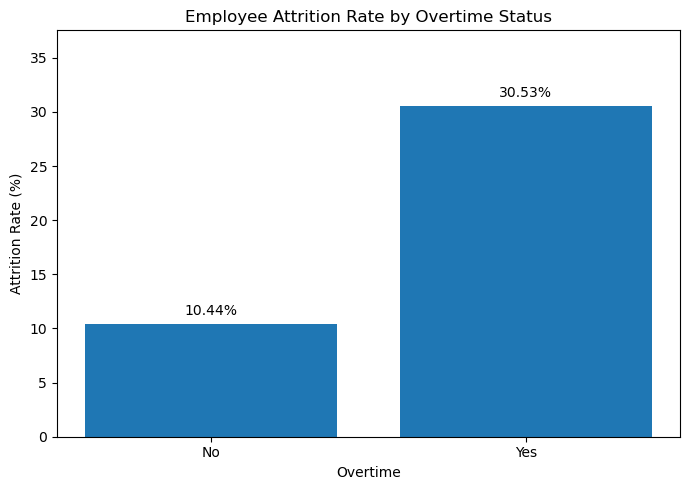

Figure saved to: ../Outputs/ibm_attrition_by_overtime.png


In [23]:
# Visualising and save attrition rate by overtime status

# Creating the summary data used in the chart
overtime_plot_data = attrition_summary_by_group(
    df_ibm_eda,
    "OverTime"
)

# Creating the figure
plt.figure(figsize=(7, 5))

bars = plt.bar(
    overtime_plot_data["OverTime"],
    overtime_plot_data["Attrition_Rate_Percent"]
)

# Adding the exact attrition percentage above each bar
for bar, value in zip(
    bars,
    overtime_plot_data["Attrition_Rate_Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center"
    )

# Adding clear labels suitable for an executive audience.
plt.title("Employee Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

# Starting the y-axis at zero so that the visual difference between groups is not exaggerated
plt.ylim(
    0,
    overtime_plot_data["Attrition_Rate_Percent"].max() + 7
)

plt.tight_layout()

# Saving the figure
output_path = "../Outputs/ibm_attrition_by_overtime.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

# Displaying the figure in the notebook.
plt.show()

print(f"Figure saved to: {output_path}")

## Dataset 2: Employee HR and Engagement Survey

Dataset 2 contains multiple related HR files. For the employee-experience and attrition case study, the initial inspection focuses on:

- `employee_data.csv`
- `employee_engagement_survey_data.csv`

The files are first inspected separately before determining whether they can be reliably linked using an employee identifier.

In [24]:
# Loading Dataset 2: Employee records and engagement survey

# Employee-level HR information
df_employee = pd.read_csv(
    "../Data/Employee_HR_Dataset/employee_data.csv"
)

# Employee engagement survey responses
df_engagement = pd.read_csv(
    "../Data/Employee_HR_Dataset/employee_engagement_survey_data.csv"
)

print("Employee data shape:", df_employee.shape)
print("Engagement survey shape:", df_engagement.shape)

Employee data shape: (3000, 26)
Engagement survey shape: (3000, 5)


In [25]:
# Preview employee-level HR data

df_employee.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Finance & Accounting,07-10-1969,MA,Accounting,Female,34904,White,Widowed,Fully Meets,4
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Aerial,30-08-1965,MA,Labor,Male,6593,Hispanic,Widowed,Fully Meets,3
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,General - Sga,06-10-1991,MA,Assistant,Male,2330,Hispanic,Widowed,Fully Meets,4
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Finance & Accounting,04-04-1998,ND,Clerk,Male,58782,Other,Single,Fully Meets,2
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,General - Con,29-08-1969,FL,Laborer,Female,33174,Other,Married,Fully Meets,3


In [26]:
# Preview employee engagement survey data

df_engagement.head()

,Employee ID,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,1001,10-10-2022,2,5,5
1,1002,03-08-2023,4,5,3
2,1003,03-01-2023,2,5,2
3,1004,30-07-2023,3,5,3
4,1005,19-06-2023,2,4,5


In [27]:
# Display column names for both Dataset 2 files

print("EMPLOYEE DATA COLUMNS")

for i, column in enumerate(df_employee.columns, start=1):
    print(f"{i:2}. {column}")


print("\nENGAGEMENT SURVEY COLUMNS")

for i, column in enumerate(df_engagement.columns, start=1):
    print(f"{i:2}. {column}")

EMPLOYEE DATA COLUMNS
 1. EmpID
 2. FirstName
 3. LastName
 4. StartDate
 5. ExitDate
 6. Title
 7. Supervisor
 8. ADEmail
 9. BusinessUnit
10. EmployeeStatus
11. EmployeeType
12. PayZone
13. EmployeeClassificationType
14. TerminationType
15. TerminationDescription
16. DepartmentType
17. Division
18. DOB
19. State
20. JobFunctionDescription
21. GenderCode
22. LocationCode
23. RaceDesc
24. MaritalDesc
25. Performance Score
26. Current Employee Rating

ENGAGEMENT SURVEY COLUMNS
 1. Employee ID
 2. Survey Date
 3. Engagement Score
 4. Satisfaction Score
 5. Work-Life Balance Score


### Validation of Employee Identifiers

Both HR files contain 3,000 records, but equal row counts do not guarantee that the records refer to the same employees.

Before joining the employee and engagement-survey files, the employee identifiers are checked for uniqueness, range, missing values, and overlap. A merge will only be performed if the identifiers provide a valid relationship between the two files.

In [28]:
# Validating employee identifiers across Dataset 2 files

# Storing the names of the ID columns used in each files
employee_id_col = "EmpID"
engagement_id_col = "Employee ID"


# Checking missing values in the ID columns
print("Missing employee IDs")

print(
    f"employee_data.csv: "
    f"{df_employee[employee_id_col].isna().sum()}"
)

print(
    f"engagement survey: "
    f"{df_engagement[engagement_id_col].isna().sum()}"
)

# Check whether IDs are unique within each file
print("\nUnique employee IDs")

print(
    f"employee_data.csv: "
    f"{df_employee[employee_id_col].nunique()} "
    f"unique IDs out of {len(df_employee)} rows"
)

print(
    f"engagement survey: "
    f"{df_engagement[engagement_id_col].nunique()} "
    f"unique IDs out of {len(df_engagement)} rows"
)

# Inspecting ID ranges

print("\nEmployee ID ranges")

print(
    f"employee_data.csv: "
    f"{df_employee[employee_id_col].min()} "
    f"to {df_employee[employee_id_col].max()}"
)

print(
    f"engagement survey: "
    f"{df_engagement[engagement_id_col].min()} "
    f"to {df_engagement[engagement_id_col].max()}"
)

# Calculating overlap between the two ID sets

employee_ids = set(
    df_employee[employee_id_col].dropna()
)

engagement_ids = set(
    df_engagement[engagement_id_col].dropna()
)

matching_ids = employee_ids.intersection(
    engagement_ids
)

print("\nID overlap")

print(
    f"Number of IDs appearing in both files: "
    f"{len(matching_ids)}"
)

print(
    f"Percentage of employee records with a matching "
    f"engagement record: "
    f"{len(matching_ids) / len(employee_ids) * 100:.2f}%"
)


# Displaying a small sample of matching IDs, if any

if matching_ids:
    print("\nExample matching IDs:")
    print(sorted(list(matching_ids))[:10])
else:
    print(
        "\nNo matching employee IDs were found between "
        "the two files."
    )

Missing employee IDs
employee_data.csv: 0
engagement survey: 0

Unique employee IDs
employee_data.csv: 3000 unique IDs out of 3000 rows
engagement survey: 3000 unique IDs out of 3000 rows

Employee ID ranges
employee_data.csv: 1001 to 4000
engagement survey: 1001 to 4000

ID overlap
Number of IDs appearing in both files: 3000
Percentage of employee records with a matching engagement record: 100.00%

Example matching IDs:
[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]


### Linking Employee Records with Engagement Survey Data

The employee and engagement-survey files each contain 3,000 unique employee identifiers ranging from 1001 to 4000, with 100% identifier overlap.

The files can therefore be linked using employee ID. A one-to-one merge is used to ensure that each employee record is matched with exactly one engagement
survey record.

In [29]:
# Merge employee records with engagement survey responses

# Rename the engagement file's ID column so that both datasets use the same variable name
df_engagement_merge = df_engagement.rename(
    columns={"Employee ID": "EmpID"}
)


# Perform an inner one-to-one merge
df_hr_merged = pd.merge(
    df_employee,
    df_engagement_merge,
    on="EmpID",
    how="inner",
    validate="one_to_one"
)

# Confirm that the merge worked as expected
print("Employee data shape:", df_employee.shape)
print("Engagement data shape:", df_engagement.shape)
print("Merged dataset shape:", df_hr_merged.shape)

print(
    "Unique employees after merge:",
    df_hr_merged["EmpID"].nunique()
)

Employee data shape: (3000, 26)
Engagement data shape: (3000, 5)
Merged dataset shape: (3000, 30)
Unique employees after merge: 3000


In [30]:
# Inspect fields relevant to employee retention/attrition

# These variables will help us determine whether Dataset 2 can support a valid employee-exit prediction problem.

retention_columns = [
    "EmpID",
    "StartDate",
    "ExitDate",
    "EmployeeStatus",
    "TerminationType",
    "Survey Date",
    "Engagement Score",
    "Satisfaction Score",
    "Work-Life Balance Score"
]

df_hr_merged[retention_columns].head(10)

,EmpID,StartDate,ExitDate,EmployeeStatus,TerminationType,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,3427,20-Sep-19,NaN,Active,Unk,14-01-2023,1,2,3
1,3428,11-Feb-23,NaN,Active,Unk,09-09-2022,2,1,5
2,3429,10-Dec-18,NaN,Active,Unk,27-05-2023,1,2,1
3,3430,21-Jun-21,NaN,Active,Unk,16-06-2023,5,5,4
4,3431,29-Jun-19,NaN,Active,Unk,25-11-2022,2,5,3
5,3432,17-Jan-20,NaN,Active,Unk,12-12-2022,2,3,5
6,3433,06-Apr-22,03-Jul-23,Active,Involuntary,25-03-2023,1,5,2
7,3434,06-Nov-20,29-Jan-23,Active,Involuntary,21-04-2023,1,4,2
8,3435,18-Aug-18,NaN,Active,Unk,09-12-2022,4,3,3
9,3436,21-Jan-22,29-Jun-23,Active,Resignation,30-07-2023,5,5,2


### Temporal Data Quality Validation

Before defining an employee attrition outcome, employment and survey dates are
validated.

For a survey to be used as information preceding an employee outcome:

- the survey should occur on or after the employee's start date;
- if an employee has exited, the survey should occur before the exit date;
- the exit date should not precede the start date.

Records violating these temporal conditions may introduce invalid observations
or data leakage and therefore require investigation before modelling.

In [31]:
# Converting date variables to pandas datetime format

# Creating a separate validation copy so that the merged dataset remains unchanged.
df_hr_validation = df_hr_merged.copy()


# Converting each date column using its known source format

# StartDate and ExitDate use formats such as: 20-Sep-19 and 03-Jul-23
df_hr_validation["StartDate"] = pd.to_datetime(
    df_hr_validation["StartDate"],
    format="%d-%b-%y",
    errors="coerce"
)

df_hr_validation["ExitDate"] = pd.to_datetime(
    df_hr_validation["ExitDate"],
    format="%d-%b-%y",
    errors="coerce"
)


# Survey Date uses formats such as: 14-01-2023
df_hr_validation["Survey Date"] = pd.to_datetime(
    df_hr_validation["Survey Date"],
    format="%d-%m-%Y",
    errors="coerce"
)


# Confirming the converted data types

df_hr_validation[
    ["StartDate", "ExitDate", "Survey Date"]
].dtypes

StartDate      datetime64[ns]
ExitDate       datetime64[ns]
Survey Date    datetime64[ns]
dtype: object

In [32]:
# Date columns used in HR dataset validation
date_columns = [
    "StartDate",
    "ExitDate",
    "Survey Date"
]

In [33]:
# Checking missing dates after conversion
date_missing_summary = pd.DataFrame({
    "Missing_Count": (
        df_hr_validation[date_columns]
        .isna()
        .sum()
    ),
    "Missing_Percentage": (
        df_hr_validation[date_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

date_missing_summary

,Missing_Count,Missing_Percentage
StartDate,0,0.0
ExitDate,1467,48.9
Survey Date,0,0.0


In [34]:
# Identifying temporal inconsistencies

# Survey occurred before the employee started
df_hr_validation["Survey_Before_Start"] = (
    df_hr_validation["Survey Date"]
    < df_hr_validation["StartDate"]
)

# Survey occurred after the recorded employee exit hence evaluating this where an ExitDate exists.
df_hr_validation["Survey_After_Exit"] = (
    df_hr_validation["ExitDate"].notna()
    & (
        df_hr_validation["Survey Date"]
        > df_hr_validation["ExitDate"]
    )
)

# Exit occurred before the recorded start date.
df_hr_validation["Exit_Before_Start"] = (
    df_hr_validation["ExitDate"].notna()
    & (
        df_hr_validation["ExitDate"]
        < df_hr_validation["StartDate"]
    )
)

# Summarise the number of problematic records
temporal_issue_summary = pd.DataFrame({
    "Issue": [
        "Survey before employment start",
        "Survey after recorded exit",
        "Exit before employment start"
    ],
    "Count": [
        df_hr_validation["Survey_Before_Start"].sum(),
        df_hr_validation["Survey_After_Exit"].sum(),
        df_hr_validation["Exit_Before_Start"].sum()
    ]
})

temporal_issue_summary["Percentage"] = (
    temporal_issue_summary["Count"]
    / len(df_hr_validation)
    * 100
).round(2)

temporal_issue_summary

,Issue,Count,Percentage
0,Survey before employment start,287,9.57
1,Survey after recorded exit,1051,35.03
2,Exit before employment start,0,0.00


In [35]:
# Check EmployeeStatus against ExitDate

active_with_exit = (
    (df_hr_validation["EmployeeStatus"] == "Active")
    & df_hr_validation["ExitDate"].notna()
)

print(
    "Employees marked Active but with an ExitDate:",
    active_with_exit.sum()
)

print(
    "Percentage of all employees:",
    round(active_with_exit.mean() * 100, 2),
    "%"
)

Employees marked Active but with an ExitDate: 991
Percentage of all employees: 33.03 %


### Valid Employee: Survey Timeline

Not all survey dates line up logically with employment records. To be useful for attrition analysis, a survey must fall after the employee’s start date and, if they’ve since left, before their exit date.

Instead of tossing out the entire dataset right away, we first count how many employees actually have a clean, valid timeline between their employment and survey dates.

In [36]:
# Identifying records with a valid employment-survey timeline
df_hr_validation["Valid_Survey_Timeline"] = (
    (df_hr_validation["Survey Date"] >= df_hr_validation["StartDate"])
    &
    (
        df_hr_validation["ExitDate"].isna()
        |
        (df_hr_validation["Survey Date"] <= df_hr_validation["ExitDate"])
    )
)

# Counting valid and invalid records.
timeline_summary = (
    df_hr_validation["Valid_Survey_Timeline"]
    .value_counts()
    .rename(index={True: "Valid", False: "Invalid"})
    .to_frame(name="Count")
)

timeline_summary["Percentage"] = (
    timeline_summary["Count"]
    / len(df_hr_validation)
    * 100
).round(2)

timeline_summary

,Count,Percentage
Valid_Survey_Timeline,,
Valid,1662,55.4
Invalid,1338,44.6


In [37]:
# Creating a temporally valid Dataset 2 subset

df_hr_valid = df_hr_validation[
    df_hr_validation["Valid_Survey_Timeline"]
].copy()

print(
    f"Original merged records: {len(df_hr_validation)}"
)

print(
    f"Temporally valid records: {len(df_hr_valid)}"
)

print(
    f"Records excluded for invalid timelines: "
    f"{len(df_hr_validation) - len(df_hr_valid)}"
)

Original merged records: 3000
Temporally valid records: 1662
Records excluded for invalid timelines: 1338


In [38]:
# Exploring a possible post-survey employee-exit outcome
df_hr_valid["Post_Survey_Exit"] = (
    df_hr_valid["ExitDate"].notna()
    &
    (df_hr_valid["ExitDate"] >= df_hr_valid["Survey Date"])
).astype(int)

exit_summary = (
    df_hr_valid["Post_Survey_Exit"]
    .value_counts()
    .sort_index()
    .to_frame(name="Count")
)

exit_summary["Percentage"] = (
    exit_summary["Count"]
    / len(df_hr_valid)
    * 100
).round(2)

exit_summary.index = [
    "No recorded post-survey exit",
    "Recorded post-survey exit"
]

exit_summary

,Count,Percentage
No recorded post-survey exit,1322,79.54
Recorded post-survey exit,340,20.46


### Observation Window and Follow-Up

Before treating the absence of a recorded exit as employee retention, the available observation period is inspected.

Employees surveyed near the end of the dataset may have had less opportunity to experience a subsequently recorded exit. This potential right-censoring issue is considered before finalising the prediction target.

In [39]:
# Examining the earliest and latest employment, survey, and recorded exit dates in the temporally valid subset.

print("DATE RANGE SUMMARY")

print(
    "Earliest StartDate:",
    df_hr_valid["StartDate"].min()
)

print(
    "Latest StartDate:",
    df_hr_valid["StartDate"].max()
)

print()

print(
    "Earliest Survey Date:",
    df_hr_valid["Survey Date"].min()
)

print(
    "Latest Survey Date:",
    df_hr_valid["Survey Date"].max()
)

print()

print(
    "Earliest recorded ExitDate:",
    df_hr_valid["ExitDate"].min()
)

print(
    "Latest recorded ExitDate:",
    df_hr_valid["ExitDate"].max()
)

DATE RANGE SUMMARY
Earliest StartDate: 2018-08-07 00:00:00
Latest StartDate: 2023-07-25 00:00:00

Earliest Survey Date: 2022-08-05 00:00:00
Latest Survey Date: 2023-08-05 00:00:00

Earliest recorded ExitDate: 2022-09-02 00:00:00
Latest recorded ExitDate: 2023-08-06 00:00:00


In [40]:
# Calculating time from survey to recorded exit

# Only employees with a valid recorded post-survey exit are included in this calculation.

employees_with_exit = df_hr_valid[
    df_hr_valid["Post_Survey_Exit"] == 1
].copy()

employees_with_exit["Days_Survey_to_Exit"] = (
    employees_with_exit["ExitDate"]
    - employees_with_exit["Survey Date"]
).dt.days


# Summarise the follow-up duration before exit.
employees_with_exit["Days_Survey_to_Exit"].describe()

count    340.000000
mean     110.314706
std       83.791519
min        0.000000
25%       37.750000
50%       94.000000
75%      169.500000
max      340.000000
Name: Days_Survey_to_Exit, dtype: float64

### Nature of Recorded Employee Exits

A recorded exit does not necessarily represent voluntary employee attrition. The dataset contains different termination types, including resignations and involuntary terminations.

Before defining the prediction target, termination categories among employees with a valid post-survey exit are examined to determine which outcome is most appropriate for an employee-experience and retention case study.

In [41]:
# Inspect termination types among valid post-survey exits

# Select only employees who have a recorded exit occurring on or after their engagement survey.
post_survey_exits = df_hr_valid[
    df_hr_valid["Post_Survey_Exit"] == 1
].copy()


# Count the different termination categories.
termination_summary = (
    post_survey_exits["TerminationType"]
    .value_counts(dropna=False)
    .to_frame(name="Count")
)

# Calculate the percentage represented by each category.
termination_summary["Percentage"] = (
    termination_summary["Count"]
    / len(post_survey_exits)
    * 100
).round(2)

termination_summary

,Count,Percentage
TerminationType,,
Involuntary,94,27.65
Voluntary,89,26.18
Retirement,79,23.24
Resignation,78,22.94


In [42]:

# Check employees surveyed on the same day they exited

same_day_exit = (
    post_survey_exits["ExitDate"]
    == post_survey_exits["Survey Date"]
)

print(
    "Same-day survey and exit records:",
    same_day_exit.sum()
)

print(
    "Percentage of post-survey exits:",
    round(same_day_exit.mean() * 100, 2),
    "%"
)

Same-day survey and exit records: 1
Percentage of post-survey exits: 0.29 %


### Investigation of Termination Categories

Recorded employee exits include several termination types. Because involuntary termination, retirement, resignation, and other voluntary exits represent different workforce outcomes, the associated termination descriptions are examined before defining the final prediction target.

This avoids grouping conceptually different exits into a single attrition outcome without justification.

In [43]:
# Inspect termination descriptions by termination type

termination_detail = (
    post_survey_exits
    .groupby(
        ["TerminationType", "TerminationDescription"],
        dropna=False
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        by=["TerminationType", "Count"],
        ascending=[True, False]
    )
)

termination_detail

,TerminationType,TerminationDescription,Count
0,Involuntary,A especially friend.,1
1,Involuntary,Administration field require.,1
2,Involuntary,All guy thus card fill walk.,1
3,Involuntary,Amount establish away part.,1
4,Involuntary,Article machine reflect land lose simply medical.,1
...,...,...,...
335,Voluntary,Very research level send picture pressure our.,1
336,Voluntary,Walk call activity onto seven about.,1
337,Voluntary,Wall body wonder successful.,1
338,Voluntary,War model build important determine.,1


In [44]:
# Count unique termination descriptions within each type

termination_description_count = (
    post_survey_exits
    .groupby("TerminationType")["TerminationDescription"]
    .nunique(dropna=False)
    .to_frame(name="Unique_Descriptions")
)

termination_description_count

,Unique_Descriptions
TerminationType,
Involuntary,94
Resignation,78
Retirement,79
Voluntary,89


### Dataset 2 Suitability Decision

The Employee/HR Dataset was initially considered because its engagement survey measures aligned closely with the employee-experience domain of the selected Culture Amp data science role.

However, detailed validation identified substantial temporal inconsistencies. Of the 3,000 merged employee records, 1,338 (44.6%) contained invalid survey timelines. This included surveys recorded before employment commenced and surveys recorded after an employee's exit. In addition, 991 employees were labelled as active despite having a recorded exit date.

Although filtering could produce a smaller analytically usable subset, doing so would require substantial assumptions about employment status, observation windows, and the definition of voluntary attrition. These issues could reduce the reliability and interpretability of the resulting analysis.

Therefore, this dataset was not selected for the final machine-learning analysis. A replacement dataset with clearer employee-experience variables and a more reliable outcome will be sought. This decision preserves methodological validity while maintaining the People Analytics and employee-retention case
study.

## Replacement Dataset Candidate: Employee Attrition Prediction

A new employee attrition dataset is being evaluated as a potential replacement for the previously rejected HR engagement dataset.

The download contains two CSV files. Both files are first inspected separately to determine their dimensions, structure, and whether one is a subset or alternative version of the other.

In [45]:
# Load both CSV files from Dataset 3



df_attrition_10000 = pd.read_csv(
    "../Data/Dataset_3/employee_attrition_dataset_10000.csv"
)

df_attrition_other = pd.read_csv(
    "../Data/Dataset_3/employee_attrition_dataset.csv"
)


# Compare dataset dimensions

print(
    "employee_attrition_dataset_10000.csv shape:",
    df_attrition_10000.shape
)

print(
    "employee_attrition_dataset.csv shape:",
    df_attrition_other.shape
)

employee_attrition_dataset_10000.csv shape: (10000, 26)
employee_attrition_dataset.csv shape: (1000, 26)


In [46]:
# Compare column names
print("10000 FILE COLUMNS")

for i, column in enumerate(
    df_attrition_10000.columns,
    start=1
):
    print(f"{i:2}. {column}")


print("\nOTHER FILE COLUMNS")

for i, column in enumerate(
    df_attrition_other.columns,
    start=1
):
    print(f"{i:2}. {column}")

10000 FILE COLUMNS
 1. Employee_ID
 2. Age
 3. Gender
 4. Marital_Status
 5. Department
 6. Job_Role
 7. Job_Level
 8. Monthly_Income
 9. Hourly_Rate
10. Years_at_Company
11. Years_in_Current_Role
12. Years_Since_Last_Promotion
13. Work_Life_Balance
14. Job_Satisfaction
15. Performance_Rating
16. Training_Hours_Last_Year
17. Overtime
18. Project_Count
19. Average_Hours_Worked_Per_Week
20. Absenteeism
21. Work_Environment_Satisfaction
22. Relationship_with_Manager
23. Job_Involvement
24. Distance_From_Home
25. Number_of_Companies_Worked
26. Attrition

OTHER FILE COLUMNS
 1. Employee_ID
 2. Age
 3. Gender
 4. Marital_Status
 5. Department
 6. Job_Role
 7. Job_Level
 8. Monthly_Income
 9. Hourly_Rate
10. Years_at_Company
11. Years_in_Current_Role
12. Years_Since_Last_Promotion
13. Work_Life_Balance
14. Job_Satisfaction
15. Performance_Rating
16. Training_Hours_Last_Year
17. Overtime
18. Project_Count
19. Average_Hours_Worked_Per_Week
20. Absenteeism
21. Work_Environment_Satisfaction
22. R

### Comparison of the Two Downloaded Files

The replacement dataset contains two CSV files with identical variables but different numbers of observations. Before selecting the larger file for analysis, the employee identifiers and row contents are compared to determine whether the smaller file is a subset or separate version of the 10,000-record dataset.

In [47]:
# Comparing Employee_ID values across the two files

# Check whether Employee_ID is unique within each file
print(
    "Unique Employee_ID values in 10,000-row file:",
    df_attrition_10000["Employee_ID"].nunique()
)

print(
    "Unique Employee_ID values in 1,000-row file:",
    df_attrition_other["Employee_ID"].nunique()
)

# Checking overlap between Employee_ID values

ids_10000 = set(
    df_attrition_10000["Employee_ID"]
)

ids_1000 = set(
    df_attrition_other["Employee_ID"]
)

matching_ids = ids_10000.intersection(ids_1000)

print(
    "\nMatching Employee_ID values:",
    len(matching_ids)
)

print(
    "Percentage of 1,000-row IDs found in 10,000-row file:",
    round(
        len(matching_ids) / len(ids_1000) * 100,
        2
    ),
    "%"
)

Unique Employee_ID values in 10,000-row file: 10000
Unique Employee_ID values in 1,000-row file: 1000

Matching Employee_ID values: 1000
Percentage of 1,000-row IDs found in 10,000-row file: 100.0 %


In [48]:
# Checking whether matching employee records are identical
comparison = pd.merge(
    df_attrition_other,
    df_attrition_10000,
    on="Employee_ID",
    how="inner",
    suffixes=("_1000", "_10000")
)


# Comparing every non-ID column between the two versions.
columns_to_compare = [
    column
    for column in df_attrition_other.columns
    if column != "Employee_ID"
]

matching_rows = pd.Series(True, index=comparison.index)

for column in columns_to_compare:
    matching_rows &= (
        comparison[f"{column}_1000"]
        == comparison[f"{column}_10000"]
    )

print(
    "Matching IDs compared:",
    len(comparison)
)

print(
    "Completely identical employee records:",
    matching_rows.sum()
)

print(
    "Percentage of matching records that are identical:",
    round(matching_rows.mean() * 100, 2),
    "%"
)

Matching IDs compared: 1000
Completely identical employee records: 0
Percentage of matching records that are identical: 0.0 %


### Selection of Dataset Version

The Kaggle download contained two files with identical variables but different sample sizes (10,000 and 1,000 records).

Although all 1,000 employee identifiers in the smaller file also appeared in the 10,000-record file, the corresponding employee records were not identical. Therefore, the smaller file is not treated as a subset of the larger dataset and the files are not combined.

The 10,000-record version is selected for further validation and analysis because it provides the larger sample while retaining the same 26-variable schema.

In [49]:
# Initial data-quality validation of the 10,000-row dataset

df_dataset2 = df_attrition_10000.copy()


# Checking missing values

missing_count = df_dataset2.isna().sum()

print("MISSING VALUES")

if missing_count.sum() == 0:
    print("No missing values were found.")
else:
    print(
        missing_count[
            missing_count > 0
        ].sort_values(ascending=False)
    )


# Checking completely duplicated rows

duplicate_rows = df_dataset2.duplicated().sum()

print("\nDUPLICATE ROWS")
print(f"Completely duplicated rows: {duplicate_rows}")


# Checking Employee_ID uniqueness

unique_ids = df_dataset2["Employee_ID"].nunique()

print("\nEMPLOYEE ID")
print(f"Total records: {len(df_dataset2)}")
print(f"Unique Employee_ID values: {unique_ids}")


# Inspecting the target-variable distribution
attrition_distribution = pd.DataFrame({
    "Count": df_dataset2["Attrition"].value_counts(dropna=False),
    "Percentage": (
        df_dataset2["Attrition"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
})

print("\nATTRITION DISTRIBUTION")

display(attrition_distribution)

MISSING VALUES
No missing values were found.

DUPLICATE ROWS
Completely duplicated rows: 0

EMPLOYEE ID
Total records: 10000
Unique Employee_ID values: 10000

ATTRITION DISTRIBUTION


,Count,Percentage
Attrition,,
No,8003,80.03
Yes,1997,19.97


### Validation of Variable Values

Although the replacement dataset contains no missing or duplicated records, its variable values are inspected before modelling.

Categorical values and numerical ranges are reviewed to identify unexpected categories, implausible values, or other issues that could affect the validity and interpretation of the analysis.

In [50]:
# Inspect data types and number of unique values

# This summary helps distinguish categorical, ordinal, continuous, count, and identifier variables.

dataset2_variable_summary = pd.DataFrame({
    "Data_Type": df_dataset2.dtypes.astype(str),
    "Unique_Values": df_dataset2.nunique(dropna=False)
})

dataset2_variable_summary

,Data_Type,Unique_Values
Employee_ID,int64,10000
Age,int64,40
Gender,object,2
Marital_Status,object,3
Department,object,5
Job_Role,object,4
Job_Level,int64,5
Monthly_Income,int64,7586
Hourly_Rate,int64,85
Years_at_Company,int64,29


In [51]:
# Inspecting categorical variables and their observed values

# Identifying columns stored as text/object
dataset2_categorical_columns = (
    df_dataset2
    .select_dtypes(include="object")
    .columns
    .tolist()
)

print("CATEGORICAL VARIABLES")

for column in dataset2_categorical_columns:
    print(f"\n{column}:")
    print(df_dataset2[column].value_counts(dropna=False))

CATEGORICAL VARIABLES

Gender:
Gender
Female    5042
Male      4958
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married     3375
Divorced    3330
Single      3295
Name: count, dtype: int64

Department:
Department
Marketing    2133
Sales        2008
Finance      1990
HR           1953
IT           1916
Name: count, dtype: int64

Job_Role:
Job_Role
Analyst      2572
Assistant    2538
Executive    2476
Manager      2414
Name: count, dtype: int64

Overtime:
Overtime
No     5103
Yes    4897
Name: count, dtype: int64

Attrition:
Attrition
No     8003
Yes    1997
Name: count, dtype: int64


In [52]:
# Inspecting numerical variable ranges

dataset2_numeric_columns = (
    df_dataset2
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

dataset2_numeric_columns = [
    column
    for column in dataset2_numeric_columns
    if column != "Employee_ID"
]

# Report minimum, maximum, mean, and median values.
numeric_range_summary = pd.DataFrame({
    "Minimum": df_dataset2[dataset2_numeric_columns].min(),
    "Maximum": df_dataset2[dataset2_numeric_columns].max(),
    "Mean": df_dataset2[dataset2_numeric_columns].mean().round(2),
    "Median": df_dataset2[dataset2_numeric_columns].median().round(2)
})

numeric_range_summary

,Minimum,Maximum,Mean,Median
Age,20,59,39.56,40.0
Job_Level,1,5,2.99,3.0
Monthly_Income,3000,19999,11436.72,11401.5
Hourly_Rate,15,99,57.03,57.0
Years_at_Company,1,29,14.94,15.0
Years_in_Current_Role,1,14,7.45,7.0
Years_Since_Last_Promotion,0,9,4.47,4.0
Work_Life_Balance,1,4,2.50,2.0
Job_Satisfaction,1,5,3.04,3.0
Performance_Rating,1,4,2.51,3.0


### Preliminary Attrition Patterns in the Replacement Dataset

Before selecting the replacement dataset for final modelling, key employee-experience variables are compared with attrition.

The same concepts examined in the IBM dataset are prioritised where possible, allowing later comparison of whether attrition patterns are complementary or contradictory across the two independent datasets.

In [53]:
# Create an exploratory-analysis copy of Dataset 2

# Keep the validated candidate dataset unchanged
df_dataset2_eda = df_dataset2.copy()

# Convert Attrition to a numeric flag for grouped summaries
df_dataset2_eda["Attrition_Flag"] = (
    df_dataset2_eda["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

# Verify the mapping
df_dataset2_eda[
    ["Attrition", "Attrition_Flag"]
].drop_duplicates()

,Attrition,Attrition_Flag
0,No,0
2,Yes,1


In [54]:
# Compare attrition across key employee-experience variables

dataset2_experience_variables = [
    "Overtime",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Work_Environment_Satisfaction",
    "Job_Involvement"
]

dataset2_experience_summaries = {}

for variable in dataset2_experience_variables:

    dataset2_experience_summaries[variable] = (
        attrition_summary_by_group(
            df_dataset2_eda,
            variable
        )
    )

    print(f"\t\tAttrition by {variable}")

    display(dataset2_experience_summaries[variable])

		Attrition by Overtime


,Overtime,Employees,Attrition_Cases,Attrition_Rate_Percent
0,No,5103,1014,19.87
1,Yes,4897,983,20.07


		Attrition by Job_Satisfaction


,Job_Satisfaction,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,1930,370,19.17
1,2,1950,400,20.51
2,3,2014,389,19.31
3,4,2022,448,22.16
4,5,2084,390,18.71


		Attrition by Work_Life_Balance


,Work_Life_Balance,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,2450,470,19.18
1,2,2562,521,20.34
2,3,2502,471,18.82
3,4,2486,535,21.52


		Attrition by Work_Environment_Satisfaction


,Work_Environment_Satisfaction,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,2524,516,20.44
1,2,2529,502,19.85
2,3,2439,507,20.79
3,4,2508,472,18.82


		Attrition by Job_Involvement


,Job_Involvement,Employees,Attrition_Cases,Attrition_Rate_Percent
0,1,2483,472,19.01
1,2,2474,485,19.60
2,3,2549,532,20.87
3,4,2494,508,20.37


### Dataset 3 Suitability Decision

The 10,000-record employee attrition dataset initially appeared suitable because it contained a direct attrition target, no missing values, no duplicated records, and employee-experience features closely aligned with the case study.

However, exploratory analysis showed very limited differentiation in attrition across key employee-experience variables. For example, attrition was 19.87% for employees not working overtime and 20.07% for those working overtime. Similarly, attrition rates remained close to the overall 20% rate across job satisfaction, work-life balance, work-environment satisfaction, and job involvement levels.

These weak and inconsistent relationships suggested that the dataset might provide limited employee-experience insight or predictive value for the case study. Therefore, it was not selected for the final machine-learning analysis.
A replacement dataset with clearer and more interpretable relationships between employee experience and attrition will be sought.

## Dataset 2 Candidate: 2024 APS Employee Census

The 2024 APS Employee Census is being evaluated as the second dataset for the People Analytics case study.

Because the public-release file is large, its structure is inspected before loading the full dataset. This includes checking the file size, number of
columns, column names, and a small sample of records.

In [55]:
# Inspect the APS Employee Census file before full loading

from pathlib import Path

# Path to the downloaded APS Employee Census CSV.
aps_file = Path(
    "../Data/2024-aps-employee-census-public-release.csv"
)

# Confirm that Python can locate the file.
print("File exists:", aps_file.exists())

# Display the approximate file size in megabytes.
file_size_mb = aps_file.stat().st_size / (1024 ** 2)

print(
    f"File size: {file_size_mb:.2f} MB"
)

File exists: True
File size: 252.08 MB


In [56]:
# Read only the CSV header

# nrows=0 reads the column names without loading any
# employee-response records into memory.
aps_header = pd.read_csv(
    aps_file,
    nrows=0
)

print(
    f"Number of columns: {len(aps_header.columns)}"
)

print("\nAPS DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(
    aps_header.columns,
    start=1
):
    print(f"{i:3}. {column}")

Number of columns: 214

APS DATASET COLUMNS
------------------------------------------------------------
  1. AS
  2. q1
  3. q2@
  4. q4@
  5. q17a
  6. q17b
  7. q17c
  8. q17d
  9. q17e
 10. q17f
 11. q17g
 12. q17h
 13. q17i
 14. q17j
 15. q17k
 16. q17l
 17. q18a
 18. q18b
 19. q18c
 20. q18d
 21. q18e
 22. q18f
 23. q18g
 24. q19_1
 25. q19_2
 26. q19_3
 27. q19_4
 28. q19_5
 29. q19_6
 30. q19_7
 31. q19_8
 32. q20a
 33. q20b
 34. q20c
 35. q20d
 36. q20e
 37. q20f
 38. q20g
 39. q20h
 40. q20i
 41. q20j
 42. q22a
 43. q22b
 44. q22c
 45. q22d
 46. q22e
 47. q22f
 48. q22g
 49. q22h
 50. q23a
 51. q23b
 52. q24a
 53. q24b
 54. q24c
 55. q24d
 56. q24e
 57. q24f
 58. q24g
 59. q24h
 60. q24i
 61. q24j
 62. q24k
 63. q24l
 64. q24m
 65. q24n
 66. q25_1
 67. q25_2
 68. q25_3
 69. q25_4
 70. q25_5
 71. q25_6
 72. q25_7
 73. q25_8
 74. q25_9
 75. q25_10
 76. q25_11
 77. q25_12
 78. q25_13
 79. q25_14
 80. q25_15
 81. q25_16
 82. q25_17
 83. q26
 84. q27
 85. q28a
 86. q28b
 87. q28c


### Candidate Target: Intention to Leave

Question 40 (`q40`) of the 2024 APS Employee Census asks respondents about their intention to remain in or leave their current position.

The response categories distinguish employees who want to leave soon from those intending to remain for one or more years. The distribution of this variable is inspected before defining a machine-learning target.

In [57]:
# Inspect Question 40: intention to remain or leave


aps_q40 = pd.read_csv(
    aps_file,
    usecols=["q40"]
)

# Basic structure

print("Number of records:", len(aps_q40))
print("Missing q40 responses:", aps_q40["q40"].isna().sum())

print(
    "Missing percentage:",
    round(aps_q40["q40"].isna().mean() * 100, 2),
    "%"
)
# Inspect response categories

q40_summary = pd.DataFrame({
    "Count": aps_q40["q40"].value_counts(dropna=False),
    "Percentage": (
        aps_q40["q40"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
})

q40_summary

Number of records: 140396
Missing q40 responses: 0
Missing percentage: 0.0 %


,Count,Percentage
q40,,
I want to stay working in my position for the next one to two years,50998,36.32
I want to stay working in my position for at least the next three years,41073,29.26
I want to leave my position within the next 12 months,30570,21.77
I want to leave my position as soon as possible,12259,8.73
,5496,3.91


### Target Suitability

Question 40 provides a clear employee-retention outcome. Respondents who wanted to leave their position as soon as possible or within the next 12 months were grouped as having an intention to leave. Respondents intending to remain for one to two years or at least three years were grouped as intending to stay.

Responses without a valid answer to `q40` were excluded rather than assigned to either outcome category.

Among respondents with a valid answer, approximately 31.75% indicated an intention to leave and 68.25% indicated an intention to stay. This provides a suitable binary classification outcome while retaining a substantial number of cases in both classes.

#### Target Leakage Prevention

Questions following q40 that are conditional on a respondent's intention to leave were not used as predictors. In particular, follow-up questions about reasons for leaving would reveal information directly connected to the target and could artificially inflate predictive performance. Predictor selection was therefore restricted to employee-experience measures available independently of the constructed intention-to-leave outcome.

In [58]:
# Create binary intention-to-leave target from APS q40

# Work on a copy so that the original q40 responses remain available for reference.
aps_target = aps_q40.copy()

# Define response groups

leave_responses = [
    "I want to leave my position as soon as possible",
    "I want to leave my position within the next 12 months"
]

stay_responses = [
    "I want to stay working in my position for the next one to two years",
    "I want to stay working in my position for at least the next three years"
]

# Map q40 to a binary target

aps_target["Intention_to_Leave"] = np.select(
    [
        aps_target["q40"].isin(leave_responses),
        aps_target["q40"].isin(stay_responses)
    ],
    [
        1,
        0
    ],
    default=np.nan
)
# Inspect target distribution before removing missing cases
target_summary = pd.DataFrame({
    "Count": aps_target["Intention_to_Leave"].value_counts(
        dropna=False
    ),
    "Percentage": aps_target["Intention_to_Leave"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
})

target_summary

,Count,Percentage
Intention_to_Leave,,
0.0,92071,65.58
1.0,42829,30.51
NaN,5496,3.91


In [59]:
# Remove records without a valid q40 response
aps_target_valid = (
    aps_target
    .dropna(subset=["Intention_to_Leave"])
    .copy()
)

# Convert the valid binary target to integer type.
aps_target_valid["Intention_to_Leave"] = (
    aps_target_valid["Intention_to_Leave"]
    .astype(int)
)

print(
    "Valid target records:",
    len(aps_target_valid)
)

print(
    "Excluded records with no valid q40 response:",
    len(aps_target) - len(aps_target_valid)
)

display(
    aps_target_valid["Intention_to_Leave"]
    .value_counts()
    .sort_index()
)

Valid target records: 134900
Excluded records with no valid q40 response: 5496


Intention_to_Leave
0    92071
1    42829
Name: count, dtype: int64

In [60]:
# Load selected APS employee-experience variables

aps_selected_columns = [
    # Employee experience / job satisfaction
    "q17b",   # Recognition for doing a good job
    "q17h",   # Overall job satisfaction

    # Immediate supervisor
    "q20e",   # Supervisor invested in my development
    "q20f",   # Supervisor provides helpful feedback

    # Agency experience
    "q24e",   # Recommend agency as a good place to work

    # Workload
    "q27",    # Current workload

    # Work pressure
    "q34a",   # Unrealistic time pressures
    "q34h",   # Too many tasks in too little time

    # Wellbeing
    "q35d",   # Agency cares about my health and wellbeing
    "q35e",   # Supervisor cares about my health and wellbeing

    # Stress and burnout
    "q38",    # Work stress
    "q39",    # Burnout

    # Target
    "q40"
]

# Read only the selected variables instead of all 214 columns
df_aps_selected = pd.read_csv(
    aps_file,
    usecols=aps_selected_columns
)

print("Selected APS dataset shape:", df_aps_selected.shape)

display(df_aps_selected.head())

Selected APS dataset shape: (140396, 13)


,q17b,q17h,q20e,q20f,q24e,q27,q34a,q34h,q35d,q35e,q38,q39,q40
0,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Slightly above capacity - lots of work to do,Never,Rarely,Strongly agree,Strongly agree,Rarely,Strongly disagree,I want to stay working in my position for the ...
1,Agree,Agree,Agree,Agree,Neither agree nor disagree,Well above capacity - too much work,Often,Sometimes,Agree,Agree,Sometimes,Neither agree nor disagree,I want to stay working in my position for the ...
2,Agree,Agree,Agree,Agree,Agree,Slightly above capacity - lots of work to do,Often,Often,Neither agree nor disagree,Agree,Sometimes,Agree,I want to stay working in my position for at l...
3,Strongly agree,Agree,Agree,Agree,Strongly agree,Slightly above capacity - lots of work to do,Sometimes,Sometimes,Strongly agree,Strongly agree,Sometimes,Disagree,I want to stay working in my position for at l...
4,Strongly disagree,Disagree,Neither agree nor disagree,Strongly disagree,Strongly disagree,Slightly above capacity - lots of work to do,Always,Sometimes,Strongly disagree,Strongly disagree,Often,Strongly agree,I want to stay working in my position for the ...


In [61]:
# Check missing values for selected APS variables
aps_missing_summary = pd.DataFrame({
    "Missing_Count": df_aps_selected.isna().sum(),
    "Missing_Percent": (
        df_aps_selected.isna().mean() * 100
    ).round(2),
    "Unique_Values": df_aps_selected.nunique(dropna=True)
})

aps_missing_summary

,Missing_Count,Missing_Percent,Unique_Values
q17b,0,0.0,6
q17h,0,0.0,6
q20e,0,0.0,6
q20f,0,0.0,6
q24e,0,0.0,6
q27,0,0.0,6
q34a,0,0.0,6
q34h,0,0.0,6
q35d,0,0.0,6
q35e,0,0.0,6


In [62]:
# Inspect all unique raw values in selected APS variables

for column in df_aps_selected.columns:
    print(f"Variable: {column}")

    # Count each raw response value.
    counts = df_aps_selected[column].value_counts(
        dropna=False
    )

    for value, count in counts.items():
        print(
            f"{repr(value):80}  Count: {count}"
        )

Variable: q17b
'Agree'                                                                           Count: 69987
'Strongly agree'                                                                  Count: 25412
'Neither agree nor disagree'                                                      Count: 24601
'Disagree'                                                                        Count: 14007
'Strongly disagree'                                                               Count: 5125
' '                                                                               Count: 1264
Variable: q17h
'Agree'                                                                           Count: 78905
'Strongly agree'                                                                  Count: 25744
'Neither agree nor disagree'                                                      Count: 19631
'Disagree'                                                                        Count: 11229
'Strongly disagree'   

In [63]:
# Count whitespace-only responses

print("WHITESPACE / BLANK RESPONSE COUNTS")

for column in df_aps_selected.columns:

    # Convert temporarily to string and check whether the
    # value contains only whitespace.
    blank_count = (
        df_aps_selected[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{column:6}: {blank_count}")

WHITESPACE / BLANK RESPONSE COUNTS
q17b  : 1264
q17h  : 1269
q20e  : 2409
q20f  : 2389
q24e  : 3461
q27   : 3943
q34a  : 4735
q34h  : 4687
q35d  : 4697
q35e  : 4633
q38   : 4690
q39   : 4862
q40   : 5496


In [64]:
# Clean hidden blank responses in selected APS variables

# Create a copy so that the original imported data remains unchanged for reproducibility and comparison.
df_aps_clean = df_aps_selected.copy()

df_aps_clean = df_aps_clean.replace(
    r"^\s*$",
    np.nan,
    regex=True
)

print("Cleaned APS dataset shape:", df_aps_clean.shape)

print(
    "Total missing values after cleaning:",
    df_aps_clean.isna().sum().sum()
)

Cleaned APS dataset shape: (140396, 13)
Total missing values after cleaning: 48535


In [65]:
# Recalculate true missingness after blank conversion
aps_missing_clean = pd.DataFrame({
    "Missing_Count": df_aps_clean.isna().sum(),

    "Missing_Percent": (
        df_aps_clean.isna().mean() * 100
    ).round(2),

    "Valid_Responses": df_aps_clean.notna().sum(),

    "Unique_Valid_Values": df_aps_clean.nunique(
        dropna=True
    )
})

aps_missing_clean

,Missing_Count,Missing_Percent,Valid_Responses,Unique_Valid_Values
q17b,1264,0.90,139132,5
q17h,1269,0.90,139127,5
q20e,2409,1.72,137987,5
q20f,2389,1.70,138007,5
q24e,3461,2.47,136935,5
q27,3943,2.81,136453,5
q34a,4735,3.37,135661,5
q34h,4687,3.34,135709,5
q35d,4697,3.35,135699,5
q35e,4633,3.30,135763,5


In [66]:
# Create binary intention-to-leave target
leave_responses = [
    "I want to leave my position as soon as possible",
    "I want to leave my position within the next 12 months"
]

stay_responses = [
    "I want to stay working in my position for the next one to two years",
    "I want to stay working in my position for at least the next three years"
]

# Create binary target:
df_aps_clean["Intention_to_Leave"] = np.select(
    [
        df_aps_clean["q40"].isin(leave_responses),
        df_aps_clean["q40"].isin(stay_responses)
    ],
    [
        1,
        0
    ],
    default=np.nan
)

In [67]:
# Keep respondents with a valid retention outcome
df_aps_model = (
    df_aps_clean
    .dropna(subset=["Intention_to_Leave"])
    .copy()
)

df_aps_model["Intention_to_Leave"] = (
    df_aps_model["Intention_to_Leave"]
    .astype(int)
)

print(
    "Rows with valid target:",
    len(df_aps_model)
)

print("\nTarget distribution:")

display(
    df_aps_model["Intention_to_Leave"]
    .value_counts()
    .sort_index()
)

Rows with valid target: 134900

Target distribution:


Intention_to_Leave
0    92071
1    42829
Name: count, dtype: int64

In [68]:
# Predictor missingness among valid-target respondents
aps_predictor_columns = [
    "q17b",
    "q17h",
    "q20e",
    "q20f",
    "q24e",
    "q27",
    "q34a",
    "q34h",
    "q35d",
    "q35e",
    "q38",
    "q39"
]

aps_model_missing = pd.DataFrame({
    "Missing_Count": (
        df_aps_model[aps_predictor_columns]
        .isna()
        .sum()
    ),

    "Missing_Percent": (
        df_aps_model[aps_predictor_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

aps_model_missing

,Missing_Count,Missing_Percent
q17b,206,0.15
q17h,210,0.16
q20e,322,0.24
q20f,309,0.23
q24e,339,0.25
q27,594,0.44
q34a,461,0.34
q34h,423,0.31
q35d,342,0.25
q35e,291,0.22


In [69]:
# Assess impact of complete-case filtering

# Identify respondents who have at least one missing value across the 12 selected predictor variables.
rows_with_missing_predictors = (
    df_aps_model[aps_predictor_columns]
    .isna()
    .any(axis=1)
)

n_total = len(df_aps_model)
n_missing_any = rows_with_missing_predictors.sum()
n_complete = n_total - n_missing_any

print("Valid-target respondents:", n_total)
print("Rows with at least one missing predictor:", n_missing_any)
print("Complete cases:", n_complete)

print(
    "Percentage retained:",
    round(n_complete / n_total * 100, 2),
    "%"
)

print(
    "Percentage removed:",
    round(n_missing_any / n_total * 100, 2),
    "%"
)

Valid-target respondents: 134900
Rows with at least one missing predictor: 2415
Complete cases: 132485
Percentage retained: 98.21 %
Percentage removed: 1.79 %


In [70]:
# Compare target distribution before and after filtering

# Dataset containing only complete predictor records
df_aps_complete = (
    df_aps_model
    .dropna(subset=aps_predictor_columns)
    .copy()
)

before_distribution = (
    df_aps_model["Intention_to_Leave"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

after_distribution = (
    df_aps_complete["Intention_to_Leave"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_comparison = pd.DataFrame({
    "Before_Filtering_Percent": before_distribution,
    "After_Filtering_Percent": after_distribution
})

target_comparison

,Before_Filtering_Percent,After_Filtering_Percent
Intention_to_Leave,,
0,68.25,68.2
1,31.75,31.8


### Missing Data Treatment

After restricting the APS Employee Census to respondents with a valid retention outcome, missingness across the selected predictors was low, with each variable having less than 0.5% missing responses.

Complete-case filtering removed 2,415 respondents, representing only 1.79% of the valid-target sample, while retaining 132,485 respondents (98.21%).

The class distribution was effectively unchanged: intention to leave was 31.75% before filtering and 31.80% after filtering. Therefore, complete-case analysis was selected instead of imputing subjective survey responses.

In [71]:
# Create final APS complete-case dataset for EDA

df_aps_eda = df_aps_complete.copy()

print("APS EDA dataset shape:", df_aps_eda.shape)

print("\nTarget counts:")
display(
    df_aps_eda["Intention_to_Leave"]
    .value_counts()
    .sort_index()
)

APS EDA dataset shape: (132485, 14)

Target counts:


Intention_to_Leave
0    90360
1    42125
Name: count, dtype: int64

In [72]:
# Helper: intention-to-leave summary by survey response

def leave_intention_summary(data, column):
    """
    Summarise intention-to-leave rates for each response
    category of an APS survey variable.

    Parameters
    data : pandas DataFrame
        APS analysis dataset.

    column : str
        Survey variable to group by.

    Returns
    pandas DataFrame
        Number of respondents, number intending to leave,
        and leave-intention percentage for each category.
    """

    summary = (
        data.groupby(column)
        .agg(
            Respondents=("Intention_to_Leave", "size"),
            Leave_Cases=("Intention_to_Leave", "sum"),
            Leave_Rate=("Intention_to_Leave", "mean")
        )
        .reset_index()
    )

    summary["Leave_Rate_Percent"] = (
        summary["Leave_Rate"] * 100
    ).round(2)

    return summary.drop(columns="Leave_Rate")

In [73]:
# Intention to leave by overall job satisfaction
# q17h = "Overall, I am satisfied with my job"
q17h_summary = leave_intention_summary(
    df_aps_eda,
    "q17h"
)
print("\t\t\t Leave intention Summary")

display(q17h_summary)

			 Leave intention Summary


,q17h,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,75287,18103,24.05
1,Disagree,10625,8439,79.43
2,Neither agree nor disagree,18249,9886,54.17
3,Strongly agree,24906,2639,10.60
4,Strongly disagree,3418,3058,89.47


### Job Satisfaction and Intention to Leave

Overall job satisfaction showed a strong relationship with intention to leave. Only 10.60% of respondents who strongly agreed that they were satisfied with their job intended to leave, compared with 89.47% of those who strongly disagreed.

The leave-intention rate increased consistently as job satisfaction declined, suggesting that job satisfaction is an important employee-experience factor associated with retention intentions. This relationship is descriptive and does not establish causation.

#### Figure: Job Satisfaction and Intention to Leave

The relationship between overall job satisfaction and intention to leave was examined descriptively before modelling. The percentage intending to leave increased substantially as reported job satisfaction decreased.

In [74]:
# APS job satisfaction vs intention-to-leave figure

# Define logical response order
job_satisfaction_order = [
    "Strongly agree",
    "Agree",
    "Neither agree nor disagree",
    "Disagree",
    "Strongly disagree"
]

# Calculate intention-to-leave rate by q17h response
aps_job_satisfaction_plot = (
    df_aps_eda
    .groupby("q17h", observed=False)
    .agg(
        Respondents=("Intention_to_Leave", "size"),
        Leave_Cases=("Intention_to_Leave", "sum"),
        Leave_Rate=("Intention_to_Leave", "mean")
    )
    .reset_index()
)

# Convert proportion to percentage
aps_job_satisfaction_plot["Leave_Rate_Percent"] = (
    aps_job_satisfaction_plot["Leave_Rate"] * 100
)

# Apply meaningful response order
aps_job_satisfaction_plot["q17h"] = pd.Categorical(
    aps_job_satisfaction_plot["q17h"],
    categories=job_satisfaction_order,
    ordered=True
)
aps_job_satisfaction_plot = (
    aps_job_satisfaction_plot
    .sort_values("q17h")
)


display(aps_job_satisfaction_plot)

,q17h,Respondents,Leave_Cases,Leave_Rate,Leave_Rate_Percent
3,Strongly agree,24906,2639,0.105958,10.595840
0,Agree,75287,18103,0.240453,24.045320
2,Neither agree nor disagree,18249,9886,0.541728,54.172831
1,Disagree,10625,8439,0.794259,79.425882
4,Strongly disagree,3418,3058,0.894675,89.467525


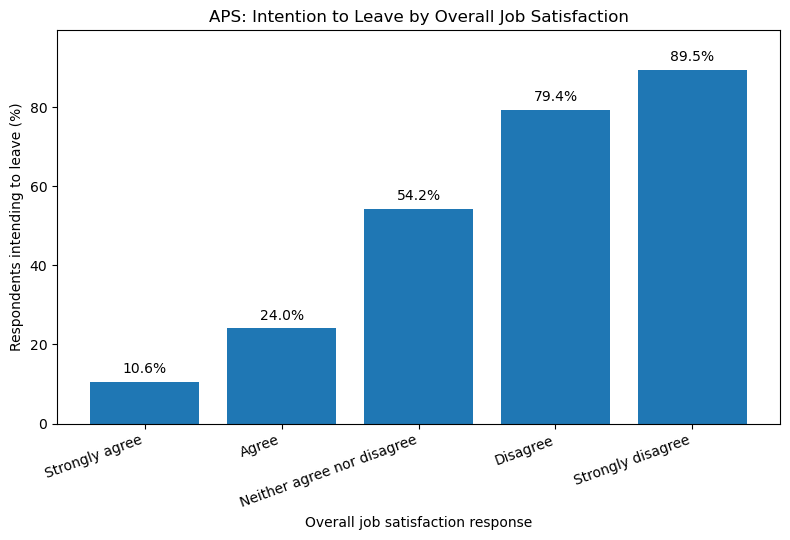

In [75]:
# Plot job satisfaction vs intention to leave
fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    aps_job_satisfaction_plot["q17h"],
    aps_job_satisfaction_plot["Leave_Rate_Percent"]
)
# Add percentage labels
for bar, value in zip(
    bars,
    aps_job_satisfaction_plot["Leave_Rate_Percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Overall job satisfaction response")

ax.set_ylabel(
    "Respondents intending to leave (%)"
)

ax.set_title(
    "APS: Intention to Leave by Overall Job Satisfaction"
)

ax.set_ylim(
    0,
    aps_job_satisfaction_plot["Leave_Rate_Percent"].max() + 10
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

# Save high-resolution figure

plt.savefig(
    "../Outputs/aps_job_satisfaction_leave_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Intention to leave by overall job satisfaction in the 2024 APS
Employee Census**

The proportion of respondents intending to leave increased sharply as job satisfaction declined, from 10.6% among respondents who strongly agreed they were satisfied with their job to 89.5% among those who strongly disagreed.
This descriptive association is consistent with the machine-learning results,
which identified job satisfaction as the strongest APS predictor.

In [76]:
# Intention to leave by burnout
# q39 = "I feel burned out by my work"

q39_summary = leave_intention_summary(
    df_aps_eda,
    "q39"
)
print("\t\t\t Burnout Summary")

display(q39_summary)

			 Burnout Summary


,q39,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,30414,13378,43.99
1,Disagree,39506,8450,21.39
2,Neither agree nor disagree,42115,11136,26.44
3,Strongly agree,10623,7218,67.95
4,Strongly disagree,9827,1943,19.77


### Burnout and Intention to Leave

Burnout was strongly associated with intention to leave. The proportion of respondents intending to leave increased from 19.77% among those who strongly disagreed that they felt burned out to 67.95% among those who strongly agreed.

The consistent increase across response categories suggests that burnout is an important workplace-experience factor associated with retention intentions. However, the relationship is observational and should not be interpreted as causal.

#### Figure: Burnout and Intention to Leave

The relationship between burnout and intention to leave was examined descriptively. The proportion intending to leave generally increased as reported burnout increased.

In [77]:
# APS burnout vs intention-to-leave figure

# Logical response order
burnout_order = [
    "Strongly disagree",
    "Disagree",
    "Neither agree nor disagree",
    "Agree",
    "Strongly agree"
]

# Calculate intention-to-leave rate by burnout response
aps_burnout_plot = (
    df_aps_eda
    .groupby("q39", observed=False)
    .agg(
        Respondents=("Intention_to_Leave", "size"),
        Leave_Cases=("Intention_to_Leave", "sum"),
        Leave_Rate=("Intention_to_Leave", "mean")
    )
    .reset_index()
)


# Convert proportion to percentage
aps_burnout_plot["Leave_Rate_Percent"] = (
    aps_burnout_plot["Leave_Rate"] * 100
)


# Apply meaningful response order
aps_burnout_plot["q39"] = pd.Categorical(
    aps_burnout_plot["q39"],
    categories=burnout_order,
    ordered=True
)

aps_burnout_plot = (
    aps_burnout_plot
    .sort_values("q39")
)


display(aps_burnout_plot)

,q39,Respondents,Leave_Cases,Leave_Rate,Leave_Rate_Percent
4,Strongly disagree,9827,1943,0.197721,19.772057
1,Disagree,39506,8450,0.213892,21.389156
2,Neither agree nor disagree,42115,11136,0.264419,26.441885
0,Agree,30414,13378,0.439863,43.986322
3,Strongly agree,10623,7218,0.679469,67.946908


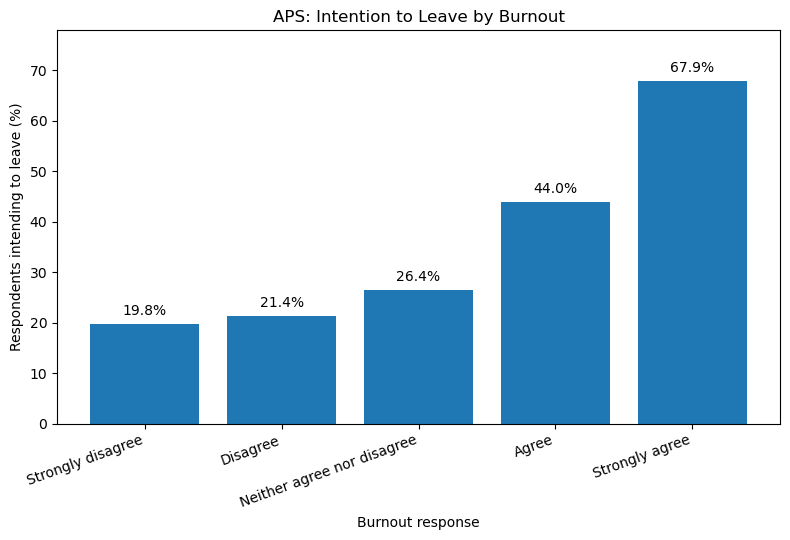

In [78]:
# Plot burnout vs intention to leave
fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    aps_burnout_plot["q39"],
    aps_burnout_plot["Leave_Rate_Percent"]
)


# Add percentage labels above bars
for bar, value in zip(
    bars,
    aps_burnout_plot["Leave_Rate_Percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


ax.set_xlabel("Burnout response")

ax.set_ylabel(
    "Respondents intending to leave (%)"
)

ax.set_title(
    "APS: Intention to Leave by Burnout"
)

ax.set_ylim(
    0,
    aps_burnout_plot["Leave_Rate_Percent"].max() + 10
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

# Save figure
plt.savefig(
    "../Outputs/aps_burnout_leave_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Intention to leave by burnout in the 2024 APS Employee Census**

The proportion of respondents intending to leave increased as reported burnout increased, from approximately 19.8% among respondents who strongly disagreed with the burnout statement to 68.0% among those who strongly agreed. This descriptive pattern is consistent with the machine-learning results, where burnout was the second strongest APS predictor after overall job satisfaction.

In [79]:
# Intention to leave by work stress
# q38 = "How often do you find your work stressful?"

q38_summary = leave_intention_summary(
    df_aps_eda,
    "q38"
)
print("\t\t leave work by stress Summary")
display(q38_summary)

		 leave work by stress Summary


,q38,Respondents,Leave_Cases,Leave_Rate_Percent
0,Always,6426,4169,64.88
1,Never,2541,695,27.35
2,Often,33004,14088,42.69
3,Rarely,24912,5876,23.59
4,Sometimes,65602,17297,26.37


### Work Stress and Intention to Leave

Frequent work stress was associated with higher intention to leave. Respondents who reported always finding their work stressful had a leave-intention rate of 64.88%, compared with 42.69% among those who were often stressed and around 24--27% among respondents reporting stress sometimes, rarely or never.

The pattern generally indicates increasing leave intention with greater work stress, although it is not perfectly monotonic. In particular, the relatively small group reporting that work was never stressful had a slightly higher leave-intention rate than the rarely stressed group. Therefore, work stress appears relevant, but burnout shows a clearer relationship with retention intentions.

In [80]:
# Intention to leave by unrealistic time pressure
# q34a = "I have unrealistic time pressures"

q34a_summary = leave_intention_summary(
    df_aps_eda,
    "q34a"
)

print("\t\tUnrealistic Time Pressure Summary")
display(q34a_summary)

		Unrealistic Time Pressure Summary


,q34a,Respondents,Leave_Cases,Leave_Rate_Percent
0,Always,8541,4823,56.47
1,Never,10766,2449,22.75
2,Often,21672,9144,42.19
3,Rarely,41386,10580,25.56
4,Sometimes,50120,15129,30.19


### Unrealistic Time Pressure and Intention to Leave

Unrealistic time pressure showed a clear relationship with intention to leave. The leave-intention rate increased steadily from 22.75% among respondents who never experienced unrealistic time pressure to 56.47% among those who always experienced it.

This monotonic pattern suggests that greater time pressure is associated with higher retention risk. However, because the data are observational and cross-sectional, the relationship should not be interpreted as causal.

In [81]:
# Intention to leave by excessive task pressure
# q34h = "I am expected to do too many different tasks
#         in too little time"

q34h_summary = leave_intention_summary(
    df_aps_eda,
    "q34h"
)

print("\t\tExcessive Task Pressure Summary")
display(q34h_summary)

		Excessive Task Pressure Summary


,q34h,Respondents,Leave_Cases,Leave_Rate_Percent
0,Always,10890,5946,54.60
1,Never,9100,2095,23.02
2,Often,24515,9879,40.30
3,Rarely,38895,9855,25.34
4,Sometimes,49085,14350,29.24


### Excessive Task Pressure and Intention to Leave

Excessive task pressure was associated with higher intention to leave. The leave intention rate increased from 23.02% among respondents who never felt that they had too many tasks in too little time to 54.60% among respondents who always experienced this pressure.

The monotonic pattern is very similar to the result for unrealistic time pressures, suggesting that workload pressure is an important employee-experience factor associated with retention intentions. These associations are descriptive and do not establish causality.

In [82]:
# Check relationship between the two workload-pressure variables: q34a and q34h

# Both questions use the same frequency scale. Higher numbers here mean MORE frequent pressure.

frequency_order = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

# Create temporary numeric versions.
q34a_numeric = df_aps_eda["q34a"].map(frequency_order)
q34h_numeric = df_aps_eda["q34h"].map(frequency_order)

pressure_correlation = q34a_numeric.corr(
    q34h_numeric,
    method="spearman"
)

print(
    "Spearman correlation between q34a and q34h:",
    round(pressure_correlation, 3)
)

Spearman correlation between q34a and q34h: 0.763


In [83]:
# Cross-tabulate the two workload-pressure questions

pressure_crosstab = pd.crosstab(
    df_aps_eda["q34a"],
    df_aps_eda["q34h"],
    normalize="index"
).mul(100).round(2)

# Put categories in meaningful order.
response_order = [
    "Never",
    "Rarely",
    "Sometimes",
    "Often",
    "Always"
]

pressure_crosstab = pressure_crosstab.reindex(
    index=response_order,
    columns=response_order
)

display(pressure_crosstab)

q34h,Never,Rarely,Sometimes,Often,Always
q34a,,,,,
Never,57.22,34.97,6.19,0.86,0.76
Rarely,5.91,64.39,26.99,2.28,0.43
Sometimes,0.75,15.51,65.07,16.93,1.74
Often,0.27,2.62,20.00,62.17,14.94
Always,0.68,1.62,3.54,17.80,76.37


### Work-Pressure Predictor Redundancy

The two work-pressure variables `q34a` (unrealistic time pressures) and `q34h`(too many tasks in too little time) showed a strong Spearman correlation of 0.763.

Their cross-tabulation also showed substantial agreement across response categories, indicating that the variables capture closely related aspects of workload pressure.

To reduce redundancy and improve model interpretability, `q34a` was retained as the primary work-pressure predictor and `q34h` was excluded from the final candidate predictor set. The exploratory analysis of `q34h` was retained as process evidence.

In [84]:
# Intention to leave by current workload
# q27 = "What best describes your current workload?"

q27_summary = leave_intention_summary(
    df_aps_eda,
    "q27"
)

print("\t\t\t\tCurrent Workload Summary")
display(q27_summary)

				Current Workload Summary


,q27,Respondents,Leave_Cases,Leave_Rate_Percent
0,At capacity - about the right amount of work t...,40849,10525,25.77
1,Slightly above capacity - lots of work to do,53006,14281,26.94
2,Slightly below capacity - available for more work,7086,3292,46.46
3,Well above capacity - too much work,29959,12863,42.94
4,Well below capacity - not enough work,1585,1164,73.44


### Current Workload and Intention to Leave

Current workload showed a non-linear relationship with intention to leave. Respondents reporting an appropriate workload had a leave-intention rate of 25.77%, while those working well above capacity had a higher rate of 42.94%.

Unexpectedly, low workload was also associated with greater leave intention. The rate increased to 46.46% among respondents slightly below capacity and 73.44% among those well below capacity. However, the latter group was relatively small (1,585 respondents), so this result should be interpreted cautiously.

This suggests that both excessive workload and under-utilisation may be associated with retention intentions. Therefore, q27 was retained alongside q34a because it captures a broader and non-linear aspect of workload.

In [85]:
# Intention to leave by recognition
# q17b = "I am satisfied with the recognition I receive
#         for doing a good job"

q17b_summary = leave_intention_summary(
    df_aps_eda,
    "q17b"
)

print("\t\t\tRecognition Summary")
display(q17b_summary)

			Recognition Summary


,q17b,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,66808,17193,25.73
1,Disagree,13243,7717,58.27
2,Neither agree nor disagree,22950,9665,42.11
3,Strongly agree,24620,3858,15.67
4,Strongly disagree,4864,3692,75.90


### Recognition and Intention to Leave

Satisfaction with recognition showed a strong relationship with intention to leave. Only 15.67% of respondents who strongly agreed that they received appropriate recognition intended to leave, compared with 75.90% of those who strongly disagreed.

The leave-intention rate increased consistently as satisfaction with recognition
declined, suggesting that recognition is an important employee-experience factor associated with retention intentions. The relationship is observational and does not establish causality.

In [86]:
# Intention to leave by supervisor development support
# q20e = "My supervisor is invested in my development"

q20e_summary = leave_intention_summary(
    df_aps_eda,
    "q20e"
)

print("\t\tSupervisor Development Support Summary")
display(q20e_summary)

		Supervisor Development Support Summary


,q20e,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,54740,16034,29.29
1,Disagree,6964,4294,61.66
2,Neither agree nor disagree,18441,8163,44.27
3,Strongly agree,48730,10832,22.23
4,Strongly disagree,3610,2802,77.62


### Supervisor Development Support and Intention to Leave

Perceived supervisor support for employee development showed a strong relationship with intention to leave. The leave-intention rate increased from 22.23% among respondents who strongly agreed that their supervisor was invested in their development to 77.62% among those who strongly disagreed.

The consistent increase across response categories suggests that perceived managerial support for development is an important employee-experience factor associated with retention intentions. The relationship is observational and does not establish causality.

In [87]:
# Intention to leave by supervisor feedback
# q20f = "My supervisor provides me with helpful
#         feedback to improve my performance"

q20f_summary = leave_intention_summary(
    df_aps_eda,
    "q20f"
)

print("\t\t\tSupervisor Feedback Summary")
display(q20f_summary)

			Supervisor Feedback Summary


,q20f,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,60756,17878,29.43
1,Disagree,7660,4743,61.92
2,Neither agree nor disagree,17185,7829,45.56
3,Strongly agree,43685,9205,21.07
4,Strongly disagree,3199,2470,77.21


### Supervisor Feedback and Intention to Leave

Helpful supervisor feedback showed a strong relationship with intention to leave. The leave-intention rate increased from 21.07% among respondents who strongly agreed that their supervisor provided helpful feedback to 77.21% among those who strongly disagreed.

This pattern closely resembles the result for supervisor support for development (`q20e`). Therefore, the relationship between the two supervisor variables was examined before deciding whether both should be retained.

In [88]:
# Check relationship between the two supervisor variables
# q20e = Supervisor is invested in my development
# q20f = Supervisor provides helpful performance feedback

# Both variables use the same five-point Likert scale. Higher values below represent a more negative response.

agreement_order = {
    "Strongly agree": 1,
    "Agree": 2,
    "Neither agree nor disagree": 3,
    "Disagree": 4,
    "Strongly disagree": 5
}

# Create temporary ordered numeric versions.
q20e_numeric = df_aps_eda["q20e"].map(agreement_order)
q20f_numeric = df_aps_eda["q20f"].map(agreement_order)

# Spearman correlation is appropriate because these are ordered survey-response categories.
supervisor_correlation = q20e_numeric.corr(
    q20f_numeric,
    method="spearman"
)

print(
    "Spearman correlation between q20e and q20f:",
    round(supervisor_correlation, 3)
)

Spearman correlation between q20e and q20f: 0.776


In [89]:

# Cross-tabulate q20e and q20f

agreement_response_order = [
    "Strongly agree",
    "Agree",
    "Neither agree nor disagree",
    "Disagree",
    "Strongly disagree"
]

supervisor_crosstab = pd.crosstab(
    df_aps_eda["q20e"],
    df_aps_eda["q20f"],
    normalize="index"
).mul(100).round(2)

# Reorder rows and columns into the meaningful Likert order.
supervisor_crosstab = supervisor_crosstab.reindex(
    index=agreement_response_order,
    columns=agreement_response_order
)

display(supervisor_crosstab)

q20f,Strongly agree,Agree,Neither agree nor disagree,Disagree,Strongly disagree
q20e,,,,,
Strongly agree,78.44,19.61,1.64,0.27,0.04
Agree,9.01,79.00,9.72,2.07,0.21
Neither agree nor disagree,2.52,36.48,48.54,11.20,1.25
Disagree,0.73,15.57,26.08,49.33,8.30
Strongly disagree,0.36,4.04,8.34,24.76,62.49


### Supervisor Predictor Redundancy

The two supervisor variables `q20e` (supervisor invested in development) and `q20f` (supervisor provides helpful performance feedback) were strongly associated, with a Spearman correlation of 0.776.

The cross-tabulation also showed substantial agreement between their response categories, suggesting that both variables capture closely related aspects of supervisor support.

To reduce redundancy and improve model interpretability, `q20e` was retained as the broader supervisor-development measure and `q20f` was excluded from the final candidate predictor set. Its exploratory analysis was retained as process evidence.

In [90]:
# Intention to leave by perceived organisational wellbeing support

# q35d = "I think my agency cares about my health and wellbeing"

q35d_summary = leave_intention_summary(
    df_aps_eda,
    "q35d"
)

print("\t\t\tAgency Wellbeing Support Summary")
display(q35d_summary)

			Agency Wellbeing Support Summary


,q35d,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,61460,16442,26.75
1,Disagree,12252,6406,52.29
2,Neither agree nor disagree,29051,11002,37.87
3,Strongly agree,23792,4258,17.90
4,Strongly disagree,5930,4017,67.74


### Organisational Wellbeing Support and Intention to Leave

Perceived organisational support for employee wellbeing showed a clear relationship with intention to leave. The leave-intention rate increased from 17.90% among respondents who strongly agreed that their agency cared about their health and wellbeing to 67.74% among those who strongly disagreed.

The monotonic pattern suggests that perceived organisational concern for employee wellbeing is strongly associated with retention intentions. This relationship is observational and does not establish causality.

In [91]:
# Intention to leave by supervisor wellbeing support
# q35e = "I believe my immediate supervisor cares about my health and wellbeing"

q35e_summary = leave_intention_summary(
    df_aps_eda,
    "q35e"
)

print("\t\t\tSupervisor Wellbeing Support Summary")
display(q35e_summary)

			Supervisor Wellbeing Support Summary


,q35e,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,53560,17526,32.72
1,Disagree,3765,2450,65.07
2,Neither agree nor disagree,11679,5682,48.65
3,Strongly agree,60943,14487,23.77
4,Strongly disagree,2538,1980,78.01


### Supervisor Wellbeing Support and Intention to Leave

Perceived supervisor concern for employee wellbeing showed a strong relationship with intention to leave. The leave-intention rate increased consistently from 23.77% among respondents who strongly agreed that their supervisor cared about their wellbeing to 78.01% among those who strongly disagreed.

This suggests that perceived supervisor wellbeing support is strongly associated with retention intentions. Because a related agency-level wellbeing measure (`q35d`) was also available, the two variables were compared for redundancy before final predictor selection.

In [92]:
# Compare agency-level and supervisor-level wellbeing support
# q35d = Agency cares about my health and wellbeing
# q35e = Immediate supervisor cares about my health and wellbeing

agreement_order = {
    "Strongly agree": 1,
    "Agree": 2,
    "Neither agree nor disagree": 3,
    "Disagree": 4,
    "Strongly disagree": 5
}

# Creating temporary ordered numeric versions
q35d_numeric = df_aps_eda["q35d"].map(agreement_order)
q35e_numeric = df_aps_eda["q35e"].map(agreement_order)

# Spearman correlation is appropriate for ordered categorical survey responses.
wellbeing_support_correlation = q35d_numeric.corr(
    q35e_numeric,
    method="spearman"
)
print(
    "Spearman correlation between q35d and q35e:",
    round(wellbeing_support_correlation, 3)
)

Spearman correlation between q35d and q35e: 0.457


In [93]:
# Cross-tabulate agency and supervisor wellbeing support

agreement_response_order = [
    "Strongly agree",
    "Agree",
    "Neither agree nor disagree",
    "Disagree",
    "Strongly disagree"
]

wellbeing_support_crosstab = pd.crosstab(
    df_aps_eda["q35d"],
    df_aps_eda["q35e"],
    normalize="index"
).mul(100).round(2)

wellbeing_support_crosstab = wellbeing_support_crosstab.reindex(
    index=agreement_response_order,
    columns=agreement_response_order
)

display(wellbeing_support_crosstab)

q35e,Strongly agree,Agree,Neither agree nor disagree,Disagree,Strongly disagree
q35d,,,,,
Strongly agree,92.56,6.01,0.97,0.26,0.21
Agree,42.05,52.17,4.43,0.95,0.40
Neither agree nor disagree,29.32,46.27,20.32,3.03,1.06
Disagree,25.86,40.64,16.58,13.17,3.76
Strongly disagree,23.42,27.74,13.41,10.57,24.86


### Agency and Supervisor Wellbeing Support

Agency-level wellbeing support (`q35d`) and supervisor-level wellbeing support(`q35e`) were moderately correlated (Spearman rho = 0.457).

Although related, this association was considerably weaker than the highly redundant predictor pairs identified earlier. The cross-tabulation also showed that respondents could hold different perceptions of organisational and immediate-supervisor support.

Therefore, both variables were retained because they represent distinct levels of the employee experience: organisational wellbeing support and direct managerial wellbeing support.

In [94]:
# Intention to leave by workplace recommendation
# q24e = "I would recommend my agency as a good place to work"

q24e_summary = leave_intention_summary(
    df_aps_eda,
    "q24e"
)

print("\t\t\tWorkplace Recommendation Summary")
display(q24e_summary)

			Workplace Recommendation Summary


,q24e,Respondents,Leave_Cases,Leave_Rate_Percent
0,Agree,64375,16655,25.87
1,Disagree,10090,6347,62.90
2,Neither agree nor disagree,23428,10475,44.71
3,Strongly agree,29994,5018,16.73
4,Strongly disagree,4598,3630,78.95


### Workplace Recommendation and Intention to Leave

Workplace recommendation showed a strong relationship with intention to leave. The leave-intention rate increased consistently from 16.73% among respondents who strongly agreed that they would recommend their agency as a good place to work to 78.95% among those who strongly disagreed.

This suggests that employees' broader perceptions of their organisation are strongly associated with retention intentions. Because overall job satisfaction (`q17h`) showed a similarly strong pattern, the two variables were compared for redundancy before final predictor selection.

In [95]:
# Compare job satisfaction and workplace recommendation
# q17h = Overall, I am satisfied with my job
# q24e = I would recommend my agency as a good place to work

agreement_order = {
    "Strongly agree": 1,
    "Agree": 2,
    "Neither agree nor disagree": 3,
    "Disagree": 4,
    "Strongly disagree": 5
}

# Temporary ordered numeric versions
q17h_numeric = df_aps_eda["q17h"].map(agreement_order)
q24e_numeric = df_aps_eda["q24e"].map(agreement_order)

# Spearman correlation for ordinal survey responses
job_agency_correlation = q17h_numeric.corr(
    q24e_numeric,
    method="spearman"
)

print(
    "Spearman correlation between q17h and q24e:",
    round(job_agency_correlation, 3)
)

Spearman correlation between q17h and q24e: 0.585


In [96]:
# Cross-tabulate q17h and q24e

agreement_response_order = [
    "Strongly agree",
    "Agree",
    "Neither agree nor disagree",
    "Disagree",
    "Strongly disagree"
]

job_agency_crosstab = pd.crosstab(
    df_aps_eda["q17h"],
    df_aps_eda["q24e"],
    normalize="index"
).mul(100).round(2)

job_agency_crosstab = job_agency_crosstab.reindex(
    index=agreement_response_order,
    columns=agreement_response_order
)

display(job_agency_crosstab)

q24e,Strongly agree,Agree,Neither agree nor disagree,Disagree,Strongly disagree
q17h,,,,,
Strongly agree,63.08,31.79,3.81,1.04,0.28
Agree,17.28,63.11,14.95,3.95,0.71
Neither agree nor disagree,4.95,35.77,41.55,14.29,3.44
Disagree,2.97,20.24,29.91,32.64,14.23
Strongly disagree,1.67,7.67,13.63,22.76,54.27


### Job Satisfaction and Organisational Recommendation

Overall job satisfaction (`q17h`) and willingness to recommend the agency as a good place to work (`q24e`) were moderately associated (Spearman rho = 0.585).

Although related, the correlation was considerably lower than the highly redundant predictor pairs identified earlier. The variables also represent different levels of employee experience: `q17h` reflects satisfaction with the individual's current job, whereas `q24e` reflects their broader perception of the organisation.

Therefore, both variables were retained as candidate predictors.

In [97]:
# Compare work stress and burnout
# q38 = How often do you find your work stressful?
# q39 = I feel burned out by my work

# For q38, higher numeric values represent MORE stress
stress_order = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

# For q39, higher numeric values represent MORE burnout
burnout_order = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neither agree nor disagree": 3,
    "Agree": 4,
    "Strongly agree": 5
}

q38_numeric = df_aps_eda["q38"].map(stress_order)
q39_numeric = df_aps_eda["q39"].map(burnout_order)

stress_burnout_correlation = q38_numeric.corr(
    q39_numeric,
    method="spearman"
)

print(
    "Spearman correlation between q38 and q39:",
    round(stress_burnout_correlation, 3)
)

Spearman correlation between q38 and q39: 0.683


### Work Stress and Burnout

Work stress (`q38`) and burnout (`q39`) were positively associated, with a Spearman correlation of 0.683, indicating substantial overlap between the two workplace wellbeing measures.

Both variables were associated with intention to leave; however, burnout showed a clearer and more consistently ordered relationship with the outcome. To reduce overlapping predictors and maintain model interpretability, `q39` was retained as the primary measure of adverse employee wellbeing and `q38` was excluded from the final candidate predictor set.

The exploratory analysis of work stress was retained as process evidence.

#### Our current final-candidate APS predictors
- q17b   Recognition for good work
- q17h   Overall job satisfaction
- q20e   Supervisor invested in development
- q24e   Recommend agency as a good place to work
- q27    Current workload
- q34a   Unrealistic time pressure
- q35d   Agency cares about health and wellbeing
- q35e   Supervisor cares about health and wellbeing
- q39    Burnout

Excluded because of overlap/redundancy:
- q20f   Supervisor helpful feedback
- q34h   Too many tasks in too little time
- q38    Work stress

In [98]:
# Check redundancy across all retained APS predictors

# Agreement variables: Higher values = more negative employee experience
agreement_order = {
    "Strongly agree": 1,
    "Agree": 2,
    "Neither agree nor disagree": 3,
    "Disagree": 4,
    "Strongly disagree": 5
}

# Frequency variable: Higher values = more frequent time pressure
frequency_order = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

# Burnout: Higher values = greater burnout
burnout_order = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neither agree nor disagree": 3,
    "Agree": 4,
    "Strongly agree": 5
}

# Create temporary numeric dataframe

aps_correlation_data = pd.DataFrame(index=df_aps_eda.index)

# Standard agreement-scale variables
agreement_variables = [
    "q17b",
    "q17h",
    "q20e",
    "q24e",
    "q35d",
    "q35e"
]

for column in agreement_variables:
    aps_correlation_data[column] = (
        df_aps_eda[column].map(agreement_order)
    )


# Unrealistic time pressure
aps_correlation_data["q34a"] = (
    df_aps_eda["q34a"].map(frequency_order)
)


# Burnout
aps_correlation_data["q39"] = (
    df_aps_eda["q39"].map(burnout_order)
)

In [99]:
# Spearman correlation matrix

aps_spearman_matrix = (
    aps_correlation_data
    .corr(method="spearman")
    .round(3)
)

display(aps_spearman_matrix)

,q17b,q17h,q20e,q24e,q35d,q35e,q34a,q39
q17b,1.000,0.612,0.521,0.499,0.459,0.462,0.277,0.350
q17h,0.612,1.000,0.449,0.585,0.457,0.403,0.264,0.398
q20e,0.521,0.449,1.000,0.390,0.345,0.635,0.187,0.207
q24e,0.499,0.585,0.390,1.000,0.551,0.373,0.286,0.359
q35d,0.459,0.457,0.345,0.551,1.000,0.457,0.316,0.373
q35e,0.462,0.403,0.635,0.373,0.457,1.000,0.203,0.233
q34a,0.277,0.264,0.187,0.286,0.316,0.203,1.000,0.546
q39,0.350,0.398,0.207,0.359,0.373,0.233,0.546,1.000


### Final APS Predictor Selection

After exploratory analysis and redundancy checks, nine employee-experience variables were retained for the APS modelling dataset.

Highly overlapping variables were removed where a closely related and more interpretable measure was available. In particular, `q20f` was excluded due to strong overlap with `q20e`, while `q34h` was excluded due to strong overlap with `q34a`. Work stress (`q38`) was also excluded because it substantially overlapped with burnout (`q39`), which showed a clearer relationship with intention to leave.

The remaining ordinal predictors had pairwise Spearman correlations below approximately 0.7. Moderate correlations were retained where the variables represented substantively different employee-experience concepts.
Current workload (`q27`) was retained separately because exploratory analysis showed a non-linear relationship with intention to leave and it was therefore not treated as a simple ordinal predictor in the correlation matrix.

In [100]:
# Final APS predictors selected after EDA and redundancy assessment

aps_final_predictors = [
    "q17b",   # Recognition for doing a good job
    "q17h",   # Overall job satisfaction
    "q20e",   # Supervisor invested in development
    "q24e",   # Recommend agency as a good place to work
    "q27",    # Current workload
    "q34a",   # Unrealistic time pressure
    "q35d",   # Agency cares about health and wellbeing
    "q35e",   # Supervisor cares about health and wellbeing
    "q39"     # Burnout
]

# Create the final APS working dataset
df_aps_final = df_aps_eda[
    aps_final_predictors + ["Intention_to_Leave"]
].copy()

print("Final APS dataset shape:", df_aps_final.shape)

print("\nMissing values:")
print(df_aps_final.isna().sum())

print("\nTarget distribution:")
display(
    df_aps_final["Intention_to_Leave"]
    .value_counts()
    .sort_index()
)

Final APS dataset shape: (132485, 10)

Missing values:
q17b                  0
q17h                  0
q20e                  0
q24e                  0
q27                   0
q34a                  0
q35d                  0
q35e                  0
q39                   0
Intention_to_Leave    0
dtype: int64

Target distribution:


Intention_to_Leave
0    90360
1    42125
Name: count, dtype: int64

## APS Machine-Learning Preparation

The final APS modelling dataset contains 132,485 complete respondent records, nine employee-experience predictors, and a binary intention-to-leave target.

The data are divided into training and test sets before fitting any preprocessing transformations. Stratified sampling is used so that the proportion of employees intending to leave is approximately preserved in both sets.

In [101]:
# Define APS predictors and target

X_aps = df_aps_final[aps_final_predictors].copy()

y_aps = df_aps_final["Intention_to_Leave"].copy()

print("Predictor shape:", X_aps.shape)
print("Target shape:", y_aps.shape)

print("\nTarget distribution:")
print(
    y_aps.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Predictor shape: (132485, 9)
Target shape: (132485,)

Target distribution:
Intention_to_Leave
0    68.2
1    31.8
Name: proportion, dtype: float64


In [102]:
# Train-test split

from sklearn.model_selection import train_test_split

X_aps_train, X_aps_test, y_aps_train, y_aps_test = train_test_split(
    X_aps,
    y_aps,

    # 80% training / 20% testing
    test_size=0.20,

    # Preserve the leave/stay class distribution
    stratify=y_aps,

    # Makes the split reproducible
    random_state=42
)

In [103]:
# Verify training and test sets

print("Training predictors:", X_aps_train.shape)
print("Test predictors:", X_aps_test.shape)

print("\nTRAINING TARGET DISTRIBUTION (%)")
print(
    y_aps_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTEST TARGET DISTRIBUTION (%)")
print(
    y_aps_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Training predictors: (105988, 9)
Test predictors: (26497, 9)

TRAINING TARGET DISTRIBUTION (%)
Intention_to_Leave
0    68.2
1    31.8
Name: proportion, dtype: float64

TEST TARGET DISTRIBUTION (%)
Intention_to_Leave
0    68.2
1    31.8
Name: proportion, dtype: float64


### Predictor Encoding

The selected APS predictors are categorical survey responses. One-hot encoding is used so that each response category can contribute independently to the machine-learning models.

This avoids assuming equal numerical distances between Likert responses and is particularly important for current workload (`q27`), which showed a non-linear
relationship with intention to leave.

The encoder is fitted using training data only to avoid information leakage
from the test set.

In [104]:
# Build APS categorical preprocessing

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# All nine selected APS predictors are categorical.
aps_categorical_features = aps_final_predictors.copy()

# One-hot encoding
aps_onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# ColumnTransformer allows the preprocessing step to be placed directly inside a machine-learning Pipeline later.
aps_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            aps_onehot_encoder,
            aps_categorical_features
        )
    ],
    remainder="drop"
)

print("APS preprocessor created successfully")

APS preprocessor created successfully


In [105]:
# Fit preprocessing on TRAINING data only
X_aps_train_encoded = aps_preprocessor.fit_transform(
    X_aps_train
)

# Apply the already-fitted transformation to test data
X_aps_test_encoded = aps_preprocessor.transform(
    X_aps_test
)

print(
    "Encoded training shape:",
    X_aps_train_encoded.shape
)

print(
    "Encoded test shape:",
    X_aps_test_encoded.shape
)

Encoded training shape: (105988, 45)
Encoded test shape: (26497, 45)


In [106]:
# Inspect encoded feature names
aps_encoded_feature_names = (
    aps_preprocessor
    .get_feature_names_out()
)

print(
    "Number of encoded predictors:",
    len(aps_encoded_feature_names)
)

print("\nEncoded feature names:")

for feature in aps_encoded_feature_names:
    print(feature)

Number of encoded predictors: 45

Encoded feature names:
categorical__q17b_Agree
categorical__q17b_Disagree
categorical__q17b_Neither agree nor disagree
categorical__q17b_Strongly agree
categorical__q17b_Strongly disagree
categorical__q17h_Agree
categorical__q17h_Disagree
categorical__q17h_Neither agree nor disagree
categorical__q17h_Strongly agree
categorical__q17h_Strongly disagree
categorical__q20e_Agree
categorical__q20e_Disagree
categorical__q20e_Neither agree nor disagree
categorical__q20e_Strongly agree
categorical__q20e_Strongly disagree
categorical__q24e_Agree
categorical__q24e_Disagree
categorical__q24e_Neither agree nor disagree
categorical__q24e_Strongly agree
categorical__q24e_Strongly disagree
categorical__q27_At capacity - about the right amount of work to do
categorical__q27_Slightly above capacity - lots of work to do
categorical__q27_Slightly below capacity - available for more work
categorical__q27_Well above capacity - too much work
categorical__q27_Well below capac

### Encoding Strategy

Categorical encoding was adapted to the structure and interpretation needs of each dataset.

For the APS Employee Census, all response categories were retained during one-hot encoding. This allowed meaningful within-question category contrasts to be examined later when interpreting Logistic Regression coefficients.

For the IBM dataset, nominal variables were one-hot encoded using `drop="first"`, providing an explicit reference category for coefficient interpretation. Ordered IBM variables retained their existing numerical coding and were standardised together with continuous predictors.

The different encoding approaches reflect the structure and interpretation requirements of the two datasets rather than a difference in the underlying evaluation framework.

## Machine-Learning Algorithms and Evaluation Strategy

Two classification algorithms are used across both employee datasets: Logistic Regression and Random Forest.

Logistic Regression provides an interpretable baseline and allows examination of how employee-experience characteristics relate to predicted retention risk. Random Forest provides a non-linear comparison capable of capturing interactions and more complex relationships between predictors.

Because the outcome represents employee attrition or intention to leave, model evaluation does not rely on accuracy alone. Recall is important because false negatives represent employees at retention risk who may not be identified, while precision reflects the cost of directing retention interventions toward false-positive cases.

F1-score is used as the primary classification metric because it balances precision and recall. PR-AUC and ROC-AUC provide threshold-independent measures of discrimination, while accuracy and the confusion matrix are reported as supporting measures.

### Experimental Methodology

Both final datasets were divided into 80% training and 20% testing partitions using stratified sampling to preserve the minority retention-outcome class.

The test partitions were excluded from model fitting and hyperparameter selection. Hyperparameters were selected using cross-validation within the training data. Logistic Regression used five-fold cross-validation for both datasets; APS Random Forest used three-fold cross-validation because of the substantially larger dataset and computational cost, while IBM Random Forest used five-fold cross-validation.

Class imbalance was explicitly considered. The APS intention-to-leave class represented approximately 31.8% of the modelling sample, while IBM attrition represented approximately 16.1%. Class weighting was evaluated during cross-validation rather than automatically applied. Balanced weighting was retained only when it improved validation F1 performance; no oversampling or synthetic sampling was used.

F1-score was the primary model-selection metric because both false negatives
and false positives are relevant to retention decision support. Recall, precision, PR-AUC, ROC-AUC, accuracy and confusion matrices were used as supporting evaluation measures.

## APS Model 1: Logistic Regression

Logistic Regression is used as an interpretable baseline classifier for predicting employee intention to leave.

The initial model uses the default probability threshold of 0.50 and no class weighting or hyperparameter tuning. This establishes baseline performance before considering any model adjustments.

Model performance is assessed using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix.

In [107]:
# Imports for Logistic Regression and model evaluation

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

print("Logistic Regression and evaluation metrics loaded")

Logistic Regression and evaluation metrics loaded


In [108]:
# APS Logistic Regression baseline

aps_logistic = LogisticRegression(
    # Increase iterations to ensure convergence.
    max_iter=1000,

    # Fixed random state for reproducibility where relevant.
    random_state=42
)

# Fit ONLY on the APS training data.
aps_logistic.fit(
    X_aps_train_encoded,
    y_aps_train
)

print("APS Logistic Regression fitted successfully")

APS Logistic Regression fitted successfully


In [109]:
# Generate APS test-set predictions

# Binary predictions using the default 0.50 threshold
y_aps_log_pred = aps_logistic.predict(
    X_aps_test_encoded
)

# Probability that each respondent belongs to class 1:
# Intention_to_Leave = 1
y_aps_log_prob = aps_logistic.predict_proba(
    X_aps_test_encoded
)[:, 1]

print("Predictions generated successfully")

Predictions generated successfully


In [110]:
# Evaluate APS Logistic Regression

aps_log_accuracy = accuracy_score(
    y_aps_test,
    y_aps_log_pred
)

aps_log_precision = precision_score(
    y_aps_test,
    y_aps_log_pred
)

aps_log_recall = recall_score(
    y_aps_test,
    y_aps_log_pred
)

aps_log_f1 = f1_score(
    y_aps_test,
    y_aps_log_pred
)

aps_log_roc_auc = roc_auc_score(
    y_aps_test,
    y_aps_log_prob
)

# Precision-Recall AUC
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_aps_test,
        y_aps_log_prob
    )
)

aps_log_pr_auc = auc(
    recall_values,
    precision_values
)

# Store results in a table

aps_logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        aps_log_accuracy,
        aps_log_precision,
        aps_log_recall,
        aps_log_f1,
        aps_log_roc_auc,
        aps_log_pr_auc
    ]
})

aps_logistic_results["Score"] = (
    aps_logistic_results["Score"]
    .round(4)
)

display(aps_logistic_results)

,Metric,Score
0,Accuracy,0.7661
1,Precision,0.7126
2,Recall,0.4430
3,F1-score,0.5463
4,ROC-AUC,0.7726
5,PR-AUC,0.6534


In [111]:
# APS Logistic Regression confusion matrix

aps_log_confusion_matrix = confusion_matrix(
    y_aps_test,
    y_aps_log_pred
)

aps_log_confusion_df = pd.DataFrame(
    aps_log_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Leave (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Leave (1)"
    ]
)

display(aps_log_confusion_df)

,Predicted Stay (0),Predicted Leave (1)
Actual Stay (0),16567,1505
Actual Leave (1),4693,3732


In [112]:
# Detailed classification report

print(
    classification_report(
        y_aps_test,
        y_aps_log_pred,
        target_names=[
            "Stay",
            "Intention to Leave"
        ],
        digits=4
    )
)

                    precision    recall  f1-score   support

              Stay     0.7793    0.9167    0.8424     18072
Intention to Leave     0.7126    0.4430    0.5463      8425

          accuracy                         0.7661     26497
         macro avg     0.7459    0.6798    0.6944     26497
      weighted avg     0.7581    0.7661    0.7483     26497



### Logistic Regression Baseline Performance

The baseline Logistic Regression achieved an accuracy of 76.61%, ROC-AUC of 0.7726 and PR-AUC of 0.6534. Precision for employees intending to leave was 71.26%, indicating that most employees classified as retention risks actually belonged to the positive class.

However, recall was only 44.30%. The model correctly identified 3,732 employees intending to leave but failed to identify 4,693 such employees. Therefore, although the baseline model demonstrated reasonable discrimination, its default classification threshold produced too many false negatives for a retention-risk application.

Further model tuning was therefore performed using the training data only, with particular attention to improving the balance between precision and recall.

In [113]:
# Tune APS Logistic Regression using TRAINING data only

from sklearn.model_selection import GridSearchCV

# Candidate Logistic Regression models.
aps_logistic_tuning = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Test different regularisation strengths and whether class weighting helps the minority leave-intention class.
aps_logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [
        None,
        "balanced"
    ]
}

# 5-fold stratified cross-validation is used automatically for this classification problem.

# Selection is based on F1-score because F1 balances precision and recall for the leave-intention class.
aps_logistic_grid = GridSearchCV(
    estimator=aps_logistic_tuning,
    param_grid=aps_logistic_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

aps_logistic_grid.fit(
    X_aps_train_encoded,
    y_aps_train
)

print(
    "Best parameters:",
    aps_logistic_grid.best_params_
)

print(
    "Best cross-validation F1:",
    round(aps_logistic_grid.best_score_, 4)
)

Best parameters: {'C': 0.01, 'class_weight': 'balanced'}
Best cross-validation F1: 0.6067


In [114]:
# Summarise Logistic Regression tuning results

aps_logistic_cv_results = pd.DataFrame(
    aps_logistic_grid.cv_results_
)

aps_logistic_cv_summary = (
    aps_logistic_cv_results[
        [
            "param_C",
            "param_class_weight",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .rename(
        columns={
            "param_C": "C",
            "param_class_weight": "Class_Weight",
            "mean_test_score": "Mean_CV_F1",
            "std_test_score": "SD_CV_F1"
        }
    )
    .sort_values(
        "Mean_CV_F1",
        ascending=False
    )
)

aps_logistic_cv_summary["Mean_CV_F1"] = (
    aps_logistic_cv_summary["Mean_CV_F1"].round(4)
)

aps_logistic_cv_summary["SD_CV_F1"] = (
    aps_logistic_cv_summary["SD_CV_F1"].round(4)
)

display(aps_logistic_cv_summary)

,C,Class_Weight,Mean_CV_F1,SD_CV_F1
1,0.01,balanced,0.6067,0.0041
3,0.10,balanced,0.6067,0.0043
5,1.00,balanced,0.6067,0.0042
7,10.00,balanced,0.6066,0.0042
6,10.00,None,0.5471,0.0056
4,1.00,None,0.5471,0.0057
2,0.10,None,0.5470,0.0060
0,0.01,None,0.5459,0.0063


### Logistic Regression Tuning

Five-fold cross-validation showed that class weighting substantially improved Logistic Regression performance. Models using balanced class weights achieved a mean F1-score of approximately 0.607, compared with approximately 0.547 for unweighted models.

Performance changed very little across the tested regularisation strengths, indicating that class weighting had a much greater effect than the value of the regularisation parameter.

The best cross-validation configuration used `C = 0.01` and balanced class weights, achieving a mean F1-score of 0.6067. This model was therefore selected for final evaluation on the held-out APS test set.

In [115]:
# Retrieve best Logistic Regression model
aps_logistic_tuned = aps_logistic_grid.best_estimator_

print(aps_logistic_tuned)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)


In [116]:
# Predictions from tuned Logistic Regression

# Binary class predictions at the default 0.50 threshold
y_aps_log_tuned_pred = aps_logistic_tuned.predict(
    X_aps_test_encoded
)

# Probability of Intention_to_Leave = 1
y_aps_log_tuned_prob = aps_logistic_tuned.predict_proba(
    X_aps_test_encoded
)[:, 1]

print("Tuned Logistic Regression predictions generated.")

Tuned Logistic Regression predictions generated.


In [117]:
# Evaluate tuned APS Logistic Regression

aps_tuned_accuracy = accuracy_score(
    y_aps_test,
    y_aps_log_tuned_pred
)

aps_tuned_precision = precision_score(
    y_aps_test,
    y_aps_log_tuned_pred
)

aps_tuned_recall = recall_score(
    y_aps_test,
    y_aps_log_tuned_pred
)

aps_tuned_f1 = f1_score(
    y_aps_test,
    y_aps_log_tuned_pred
)

aps_tuned_roc_auc = roc_auc_score(
    y_aps_test,
    y_aps_log_tuned_prob
)

# Precision-Recall AUC
tuned_precision_values, tuned_recall_values, _ = (
    precision_recall_curve(
        y_aps_test,
        y_aps_log_tuned_prob
    )
)

aps_tuned_pr_auc = auc(
    tuned_recall_values,
    tuned_precision_values
)


# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------

aps_logistic_tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        aps_tuned_accuracy,
        aps_tuned_precision,
        aps_tuned_recall,
        aps_tuned_f1,
        aps_tuned_roc_auc,
        aps_tuned_pr_auc
    ]
})

aps_logistic_tuned_results["Score"] = (
    aps_logistic_tuned_results["Score"]
    .round(4)
)

display(aps_logistic_tuned_results)

,Metric,Score
0,Accuracy,0.7436
1,Precision,0.5939
2,Recall,0.6123
3,F1-score,0.6030
4,ROC-AUC,0.7731
5,PR-AUC,0.6504


In [118]:
# Tuned Logistic Regression confusion matrix

aps_tuned_confusion_matrix = confusion_matrix(
    y_aps_test,
    y_aps_log_tuned_pred
)

aps_tuned_confusion_df = pd.DataFrame(
    aps_tuned_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Leave (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Leave (1)"
    ]
)

display(aps_tuned_confusion_df)

,Predicted Stay (0),Predicted Leave (1)
Actual Stay (0),14545,3527
Actual Leave (1),3266,5159


In [119]:
# Compare baseline and tuned Logistic Regression

aps_logistic_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Baseline": [
        aps_log_accuracy,
        aps_log_precision,
        aps_log_recall,
        aps_log_f1,
        aps_log_roc_auc,
        aps_log_pr_auc
    ],

    "Tuned_Balanced": [
        aps_tuned_accuracy,
        aps_tuned_precision,
        aps_tuned_recall,
        aps_tuned_f1,
        aps_tuned_roc_auc,
        aps_tuned_pr_auc
    ]
})

aps_logistic_comparison[
    ["Baseline", "Tuned_Balanced"]
] = aps_logistic_comparison[
    ["Baseline", "Tuned_Balanced"]
].round(4)

display(aps_logistic_comparison)

,Metric,Baseline,Tuned_Balanced
0,Accuracy,0.7661,0.7436
1,Precision,0.7126,0.5939
2,Recall,0.4430,0.6123
3,F1-score,0.5463,0.6030
4,ROC-AUC,0.7726,0.7731
5,PR-AUC,0.6534,0.6504


### Final Logistic Regression Performance

Class weighting improved the Logistic Regression model's ability to identify employees intending to leave. Recall increased from 44.30% to 61.23%, while F1-score increased from 0.5463 to 0.6030.

This improvement involved a trade-off. Precision declined from 71.26% to 59.39%, and accuracy declined slightly from 76.61% to 74.36%. However, the number of false negatives decreased from 4,693 to 3,266, meaning that the balanced model identified substantially more employees who intended to leave.

ROC-AUC remained almost unchanged (0.7726 versus 0.7731), indicating that class weighting primarily altered the classification trade-off rather than substantially changing the model's overall discrimination.

Because F1-score was selected as the primary evaluation measure and identifying
employees at retention risk is important in this case study, the balanced Logistic Regression model was retained as the final Logistic Regression model.

## APS Model 2: Random Forest

Random Forest is used as a non-linear classification model to complement Logistic Regression. Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between employee-experience variables.

An untuned baseline model is first evaluated before considering class weighting or hyperparameter optimisation.

In [120]:
# APS Random Forest baseline

from sklearn.ensemble import RandomForestClassifier

aps_random_forest = RandomForestClassifier(
    # Use multiple trees for stable baseline predictions
    n_estimators=200,

    # Reproducibility
    random_state=42,

    # Use all available CPU cores
    n_jobs=-1
)

# Fit using TRAINING data only
aps_random_forest.fit(
    X_aps_train_encoded,
    y_aps_train
)

print("APS Random Forest fitted successfully")

APS Random Forest fitted successfully


In [121]:
# Generate Random Forest test predictions

y_aps_rf_pred = aps_random_forest.predict(
    X_aps_test_encoded
)

y_aps_rf_prob = aps_random_forest.predict_proba(
    X_aps_test_encoded
)[:, 1]

print("APS Random Forest predictions generated")

APS Random Forest predictions generated


In [122]:
# Evaluate baseline APS Random Forest
aps_rf_accuracy = accuracy_score(
    y_aps_test,
    y_aps_rf_pred
)

aps_rf_precision = precision_score(
    y_aps_test,
    y_aps_rf_pred
)

aps_rf_recall = recall_score(
    y_aps_test,
    y_aps_rf_pred
)

aps_rf_f1 = f1_score(
    y_aps_test,
    y_aps_rf_pred
)

aps_rf_roc_auc = roc_auc_score(
    y_aps_test,
    y_aps_rf_prob
)

# Precision-Recall AUC
rf_precision_values, rf_recall_values, _ = (
    precision_recall_curve(
        y_aps_test,
        y_aps_rf_prob
    )
)

aps_rf_pr_auc = auc(
    rf_recall_values,
    rf_precision_values
)

# Results table
aps_rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        aps_rf_accuracy,
        aps_rf_precision,
        aps_rf_recall,
        aps_rf_f1,
        aps_rf_roc_auc,
        aps_rf_pr_auc
    ]
})

aps_rf_results["Score"] = (
    aps_rf_results["Score"].round(4)
)

display(aps_rf_results)

,Metric,Score
0,Accuracy,0.7476
1,Precision,0.6478
2,Recall,0.4520
3,F1-score,0.5325
4,ROC-AUC,0.7331
5,PR-AUC,0.5929


In [123]:
# APS Random Forest confusion matrix

aps_rf_confusion_matrix = confusion_matrix(
    y_aps_test,
    y_aps_rf_pred
)

aps_rf_confusion_df = pd.DataFrame(
    aps_rf_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Leave (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Leave (1)"
    ]
)

display(aps_rf_confusion_df)

,Predicted Stay (0),Predicted Leave (1)
Actual Stay (0),16002,2070
Actual Leave (1),4617,3808


### Random Forest Baseline Performance

The baseline Random Forest achieved an accuracy of 74.76%, precision of 64.78%, and recall of 45.20%, resulting in an F1-score of 0.5325.

The model correctly identified 3,808 employees intending to leave but failed to identify 4,617 positive cases. Its ROC-AUC (0.7331) and PR-AUC (0.5929) were also lower than those of the tuned Logistic Regression model.

Although Random Forest produced fewer false positives than the balanced Logistic Regression model, its relatively low recall and F1-score indicate that further tuning is required before making the final model comparison.

In [124]:
# Tune APS Random Forest using TRAINING data

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

aps_rf_tuning = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

# Hyperparameter grid
aps_rf_param_grid = {
    "class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ],

    "max_depth": [
        None,
        15
    ],

    "min_samples_leaf": [
        1,
        5
    ]
}

aps_rf_grid = GridSearchCV(
    estimator=aps_rf_tuning,
    param_grid=aps_rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1,
    verbose=2,
    return_train_score=False
)

aps_rf_grid.fit(
    X_aps_train_encoded,
    y_aps_train
)

print(
    "Best parameters:",
    aps_rf_grid.best_params_
)

print(
    "Best cross-validation F1:",
    round(aps_rf_grid.best_score_, 4)
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  58.5s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  58.3s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  59.4s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=5; total time=  16.8s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=5; total time=  16.9s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=5; total time=  17.1s
[CV] END class_weight=None, max_depth=15, min_samples_leaf=1; total time=  14.7s
[CV] END class_weight=None, max_depth=15, min_samples_leaf=1; total time=  14.6s
[CV] END class_weight=None, max_depth=15, min_samples_leaf=1; total time=  14.4s
[CV] END class_weight=None, max_depth=15, min_samples_leaf=5; total time=   9.6s
[CV] END class_weight=None, max_depth=15, min_samples_leaf=5; total time=   9.6s
[CV] END class_weight=None, max_dept

In [125]:
# Summarise Random Forest tuning results
aps_rf_cv_results = pd.DataFrame(
    aps_rf_grid.cv_results_
)

aps_rf_cv_summary = (
    aps_rf_cv_results[
        [
            "param_class_weight",
            "param_max_depth",
            "param_min_samples_leaf",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .rename(
        columns={
            "param_class_weight": "Class_Weight",
            "param_max_depth": "Max_Depth",
            "param_min_samples_leaf": "Min_Samples_Leaf",
            "mean_test_score": "Mean_CV_F1",
            "std_test_score": "SD_CV_F1"
        }
    )
    .sort_values(
        "Mean_CV_F1",
        ascending=False
    )
)

aps_rf_cv_summary["Mean_CV_F1"] = (
    aps_rf_cv_summary["Mean_CV_F1"].round(4)
)

aps_rf_cv_summary["SD_CV_F1"] = (
    aps_rf_cv_summary["SD_CV_F1"].round(4)
)

display(aps_rf_cv_summary)

,Class_Weight,Max_Depth,Min_Samples_Leaf,Mean_CV_F1,SD_CV_F1
11,balanced_subsample,15,5,0.6043,0.0018
7,balanced,15,5,0.6042,0.0012
9,balanced_subsample,None,5,0.6028,0.0027
5,balanced,None,5,0.6017,0.0022
10,balanced_subsample,15,1,0.5983,0.0027
6,balanced,15,1,0.5976,0.0025
3,None,15,5,0.5550,0.0060
1,None,None,5,0.5521,0.0064
2,None,15,1,0.5505,0.0048
8,balanced_subsample,None,1,0.5476,0.0039


### Random Forest Tuning

Random Forest performance improved substantially after addressing class imbalance and controlling tree complexity. The best configuration used balanced subsampling, a maximum tree depth of 15, and a minimum of five observations per leaf.

This configuration achieved a mean cross-validation F1-score of 0.6043, compared with substantially lower performance for the untuned Random Forest.

Class-weighted models consistently outperformed unweighted alternatives, suggesting that accounting for the minority intention-to-leave class was important. Restricting tree depth and increasing the minimum leaf size also improved performance, indicating that some control of model complexity was beneficial.

In [126]:
# Retrieve best tuned Random Forest

aps_rf_tuned = aps_rf_grid.best_estimator_

print(aps_rf_tuned)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       min_samples_leaf=5, n_estimators=200, n_jobs=1,
                       random_state=42)


In [127]:
# Generate tuned Random Forest test predictions

# Binary predictions using the default 0.50 threshold.
y_aps_rf_tuned_pred = aps_rf_tuned.predict(
    X_aps_test_encoded
)

# Probability of Intention_to_Leave = 1.
y_aps_rf_tuned_prob = aps_rf_tuned.predict_proba(
    X_aps_test_encoded
)[:, 1]

print("Tuned Random Forest predictions generated.")

Tuned Random Forest predictions generated.


In [128]:
# Evaluate tuned APS Random Forest

aps_rf_tuned_accuracy = accuracy_score(
    y_aps_test,
    y_aps_rf_tuned_pred
)

aps_rf_tuned_precision = precision_score(
    y_aps_test,
    y_aps_rf_tuned_pred
)

aps_rf_tuned_recall = recall_score(
    y_aps_test,
    y_aps_rf_tuned_pred
)

aps_rf_tuned_f1 = f1_score(
    y_aps_test,
    y_aps_rf_tuned_pred
)

aps_rf_tuned_roc_auc = roc_auc_score(
    y_aps_test,
    y_aps_rf_tuned_prob
)


# Precision-Recall AUC
rf_tuned_precision_values, rf_tuned_recall_values, _ = (
    precision_recall_curve(
        y_aps_test,
        y_aps_rf_tuned_prob
    )
)

aps_rf_tuned_pr_auc = auc(
    rf_tuned_recall_values,
    rf_tuned_precision_values
)


# Store results
aps_rf_tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        aps_rf_tuned_accuracy,
        aps_rf_tuned_precision,
        aps_rf_tuned_recall,
        aps_rf_tuned_f1,
        aps_rf_tuned_roc_auc,
        aps_rf_tuned_pr_auc
    ]
})

aps_rf_tuned_results["Score"] = (
    aps_rf_tuned_results["Score"]
    .round(4)
)

display(aps_rf_tuned_results)


,Metric,Score
0,Accuracy,0.7448
1,Precision,0.5976
2,Recall,0.6047
3,F1-score,0.6011
4,ROC-AUC,0.7744
5,PR-AUC,0.6527


In [129]:
# Tuned Random Forest confusion matrix

aps_rf_tuned_confusion_matrix = confusion_matrix(
    y_aps_test,
    y_aps_rf_tuned_pred
)

aps_rf_tuned_confusion_df = pd.DataFrame(
    aps_rf_tuned_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Leave (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Leave (1)"
    ]
)

display(aps_rf_tuned_confusion_df)

,Predicted Stay (0),Predicted Leave (1)
Actual Stay (0),14641,3431
Actual Leave (1),3330,5095


In [130]:
# Final APS model comparison

aps_final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Logistic_Regression": [
        aps_tuned_accuracy,
        aps_tuned_precision,
        aps_tuned_recall,
        aps_tuned_f1,
        aps_tuned_roc_auc,
        aps_tuned_pr_auc
    ],

    "Random_Forest": [
        aps_rf_tuned_accuracy,
        aps_rf_tuned_precision,
        aps_rf_tuned_recall,
        aps_rf_tuned_f1,
        aps_rf_tuned_roc_auc,
        aps_rf_tuned_pr_auc
    ]
})

aps_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
] = aps_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
].round(4)

display(aps_final_model_comparison)

,Metric,Logistic_Regression,Random_Forest
0,Accuracy,0.7436,0.7448
1,Precision,0.5939,0.5976
2,Recall,0.6123,0.6047
3,F1-score,0.6030,0.6011
4,ROC-AUC,0.7731,0.7744
5,PR-AUC,0.6504,0.6527


In [131]:
# Final APS model comparison

aps_final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Logistic_Regression": [
        aps_tuned_accuracy,
        aps_tuned_precision,
        aps_tuned_recall,
        aps_tuned_f1,
        aps_tuned_roc_auc,
        aps_tuned_pr_auc
    ],

    "Random_Forest": [
        aps_rf_tuned_accuracy,
        aps_rf_tuned_precision,
        aps_rf_tuned_recall,
        aps_rf_tuned_f1,
        aps_rf_tuned_roc_auc,
        aps_rf_tuned_pr_auc
    ]
})

aps_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
] = aps_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
].round(4)

display(aps_final_model_comparison)

,Metric,Logistic_Regression,Random_Forest
0,Accuracy,0.7436,0.7448
1,Precision,0.5939,0.5976
2,Recall,0.6123,0.6047
3,F1-score,0.6030,0.6011
4,ROC-AUC,0.7731,0.7744
5,PR-AUC,0.6504,0.6527


### Final APS Model Comparison

The tuned Logistic Regression and Random Forest produced very similar performance on the held-out test set.

Logistic Regression achieved a slightly higher F1-score (0.6030 versus 0.6011) and recall (61.23% versus 60.47%), while Random Forest achieved marginally higher accuracy, precision, ROC-AUC and PR-AUC.

The differences were small, suggesting that the additional non-linear complexity of Random Forest did not provide a substantial predictive advantage for the selected APS employee-experience variables.

Because F1-score was selected as the primary metric and Logistic Regression also provides greater interpretability, the tuned Logistic Regression was treated as the primary APS model. Random Forest was retained as a complementary model for comparison.

#### Figure: APS Precision–Recall Performance

Precision–Recall curves were used to compare the ability of Logistic Regression and Random Forest to identify respondents intending to leave across different classification thresholds.

This evaluation is useful because the intention-to-leave class represents approximately 32% of the modelling sample, making precision and recall more informative than accuracy alone.

APS prediction probabilities generated successfully.


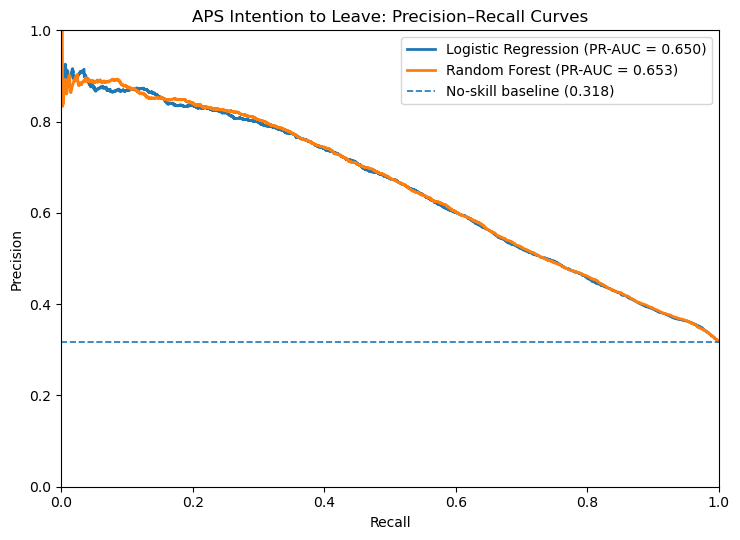

In [132]:
# APS Precision-Recall curves

# Generate probabilities from the final tuned models
y_aps_log_tuned_prob = aps_logistic_tuned.predict_proba(
    X_aps_test_encoded
)[:, 1]

y_aps_rf_tuned_prob = aps_rf_tuned.predict_proba(
    X_aps_test_encoded
)[:, 1]

print("APS prediction probabilities generated successfully.")

# Logistic Regression PR curve
aps_lr_precision_curve, aps_lr_recall_curve, _ = (
    precision_recall_curve(
        y_aps_test,
        y_aps_log_tuned_prob
    )
)

aps_lr_pr_auc = auc(
    aps_lr_recall_curve,
    aps_lr_precision_curve
)

# Random Forest PR curve
aps_rf_precision_curve, aps_rf_recall_curve, _ = (
    precision_recall_curve(
        y_aps_test,
        y_aps_rf_tuned_prob
    )
)

aps_rf_pr_auc = auc(
    aps_rf_recall_curve,
    aps_rf_precision_curve
)

# No-skill baseline

aps_positive_rate = y_aps_test.mean()

# Plot
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(
    aps_lr_recall_curve,
    aps_lr_precision_curve,
    linewidth=2,
    label=f"Logistic Regression (PR-AUC = {aps_lr_pr_auc:.3f})"
)

ax.plot(
    aps_rf_recall_curve,
    aps_rf_precision_curve,
    linewidth=2,
    label=f"Random Forest (PR-AUC = {aps_rf_pr_auc:.3f})"
)

ax.axhline(
    y=aps_positive_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"No-skill baseline ({aps_positive_rate:.3f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_title(
    "APS Intention to Leave: Precision–Recall Curves"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "../Outputs/aps_precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Precision–Recall curves for APS intention-to-leave prediction**

Logistic Regression and Random Forest produced very similar precision–recall performance, with PR-AUC values of approximately 0.650 and 0.653 respectively. Both substantially exceeded the no-skill baseline associated with the approximately 32% prevalence of intention to leave. The similarity of the curves supports the conclusion that neither algorithm demonstrated a clear overall predictive advantage.

In [133]:
# Extract Logistic Regression category coefficients

# Coefficients from our final tuned Logistic Regression.
aps_log_coef = aps_logistic_tuned.coef_[0]

# Match coefficients to their one-hot encoded feature names.
aps_log_coef_table = pd.DataFrame({
    "Encoded_Feature": aps_encoded_feature_names,
    "Coefficient": aps_log_coef
})

# Separate original variable and response category

coefficient_rows = []

for variable in aps_final_predictors:

    prefix = f"categorical__{variable}_"

    for _, row in aps_log_coef_table.iterrows():

        feature_name = row["Encoded_Feature"]

        if feature_name.startswith(prefix):

            category = feature_name[len(prefix):]

            coefficient_rows.append({
                "Variable": variable,
                "Category": category,
                "Coefficient": row["Coefficient"]
            })

aps_category_effects = pd.DataFrame(
    coefficient_rows
)

display(aps_category_effects.head(10))

,Variable,Category,Coefficient
0,q17b,Agree,-0.102787
1,q17b,Disagree,0.095329
2,q17b,Neither agree nor disagree,-0.013188
3,q17b,Strongly agree,-0.096973
4,q17b,Strongly disagree,0.133098
5,q17h,Agree,-0.707392
6,q17h,Disagree,0.953621
7,q17h,Neither agree nor disagree,0.208186
8,q17h,Strongly agree,-1.393479
9,q17h,Strongly disagree,0.954543


In [134]:
# Define meaningful reference category for each variable

aps_reference_categories = {
    "q17b": "Strongly agree",  # recognition
    "q17h": "Strongly agree",  # job satisfaction
    "q20e": "Strongly agree",  # supervisor development
    "q24e": "Strongly agree",  # recommend agency

    # Appropriate workload is the natural reference.
    "q27": "At capacity - about the right amount of work to do",

    "q34a": "Never",           # unrealistic time pressure
    "q35d": "Strongly agree",  # agency wellbeing support
    "q35e": "Strongly agree",  # supervisor wellbeing support

    # Low burnout is the natural reference.
    "q39": "Strongly disagree"
}

In [135]:
# Calculate relative model odds within each survey question

relative_effect_rows = []

for variable in aps_final_predictors:

    variable_data = aps_category_effects[
        aps_category_effects["Variable"] == variable
    ].copy()

    reference_category = aps_reference_categories[
        variable
    ]

    reference_coefficient = variable_data.loc[
        variable_data["Category"] == reference_category,
        "Coefficient"
    ].iloc[0]

    # Difference from the reference-category coefficient.
    variable_data["Coefficient_Difference"] = (
        variable_data["Coefficient"]
        - reference_coefficient
    )

    # exp(coefficient difference) gives the model's relative
    # odds multiplier compared with the chosen category,
    # holding the other model predictors fixed.
    variable_data["Relative_Odds"] = np.exp(
        variable_data["Coefficient_Difference"]
    )

    variable_data["Reference_Category"] = (
        reference_category
    )

    relative_effect_rows.append(
        variable_data
    )

aps_relative_effects = pd.concat(
    relative_effect_rows,
    ignore_index=True
)

aps_relative_effects[
    "Relative_Odds"
] = aps_relative_effects[
    "Relative_Odds"
].round(3)

display(aps_relative_effects)

,Variable,Category,Coefficient,Coefficient_Difference,Relative_Odds,Reference_Category
0,q17b,Agree,-0.102787,-0.005814,0.994,Strongly agree
1,q17b,Disagree,0.095329,0.192303,1.212,Strongly agree
2,q17b,Neither agree nor disagree,-0.013188,0.083785,1.087,Strongly agree
3,q17b,Strongly agree,-0.096973,0.000000,1.000,Strongly agree
4,q17b,Strongly disagree,0.133098,0.230071,1.259,Strongly agree
5,q17h,Agree,-0.707392,0.686087,1.986,Strongly agree
6,q17h,Disagree,0.953621,2.347100,10.455,Strongly agree
7,q17h,Neither agree nor disagree,0.208186,1.601666,4.961,Strongly agree
8,q17h,Strongly agree,-1.393479,0.000000,1.000,Strongly agree
9,q17h,Strongly disagree,0.954543,2.348023,10.465,Strongly agree


In [136]:
# Summarise strongest leave-risk category for each variable

aps_variable_labels = {
    "q17b": "Recognition",
    "q17h": "Job satisfaction",
    "q20e": "Supervisor development support",
    "q24e": "Recommend agency",
    "q27": "Current workload",
    "q34a": "Unrealistic time pressure",
    "q35d": "Agency wellbeing support",
    "q35e": "Supervisor wellbeing support",
    "q39": "Burnout"
}

highest_risk_rows = []

for variable in aps_final_predictors:

    variable_data = aps_relative_effects[
        aps_relative_effects["Variable"] == variable
    ]

    highest_risk = variable_data.loc[
        variable_data["Relative_Odds"].idxmax()
    ]

    highest_risk_rows.append({
        "Variable": aps_variable_labels[variable],
        "Reference_Category":
            highest_risk["Reference_Category"],
        "Highest_Risk_Category":
            highest_risk["Category"],
        "Relative_Odds":
            highest_risk["Relative_Odds"]
    })

aps_logistic_insight_summary = pd.DataFrame(
    highest_risk_rows
)

display(aps_logistic_insight_summary)

,Variable,Reference_Category,Highest_Risk_Category,Relative_Odds
0,Recognition,Strongly agree,Strongly disagree,1.259
1,Job satisfaction,Strongly agree,Strongly disagree,10.465
2,Supervisor development support,Strongly agree,Strongly disagree,1.652
3,Recommend agency,Strongly agree,Strongly disagree,1.808
4,Current workload,At capacity - about the right amount of work t...,Well below capacity - not enough work,2.096
5,Unrealistic time pressure,Never,Often,1.126
6,Agency wellbeing support,Strongly agree,Disagree,1.109
7,Supervisor wellbeing support,Strongly agree,Disagree,1.143
8,Burnout,Strongly disagree,Strongly agree,2.492


### Logistic Regression Employee-Experience Insights

The multivariable Logistic Regression identified overall job satisfaction as the strongest adjusted predictor of intention to leave. Respondents who strongly disagreed that they were satisfied with their job had approximately 10.47 times the model estimated odds of intending to leave compared with those who strongly agreed, holding the other selected predictors constant.

Burnout was also important, with respondents who strongly agreed that they felt burned out having approximately 2.49 times the odds of intending to leave relative to those who strongly disagreed. Employees reporting workload well below capacity had approximately 2.10 times the odds of leaving compared with employees reporting an appropriate workload.

Negative organisational recommendation and poor supervisor development support were also associated with increased retention risk.

Some predictors that showed strong descriptive relationships, including recognition, time pressure and wellbeing support, produced smaller adjusted effects in the multivariable model. This suggests that part of their descriptive association with intention to leave overlaps with broader factors such as job satisfaction and burnout.

These model effects represent associations after accounting for the other selected predictors and should not be interpreted as causal effects.

In [137]:
# Grouped permutation importance for tuned Random Forest

from sklearn.metrics import f1_score

# Baseline F1 on the untouched APS test set.
rf_baseline_f1 = f1_score(
    y_aps_test,
    aps_rf_tuned.predict(X_aps_test_encoded)
)

print(
    "Tuned Random Forest baseline F1:",
    round(rf_baseline_f1, 4)
)

Tuned Random Forest baseline F1: 0.6011


In [138]:
# Permute one ORIGINAL survey variable at a time

rng = np.random.RandomState(42)

rf_group_importance_results = []

# Repeat each permutation several times to reduce the
# influence of one random shuffle.
n_repeats = 5

for variable in aps_final_predictors:

    f1_drops = []

    for repeat in range(n_repeats):

        # Start with the unchanged raw test predictors.
        X_permuted = X_aps_test.copy()

        # Shuffle only the selected variable.
        X_permuted[variable] = rng.permutation(
            X_permuted[variable].values
        )

        # Apply the encoder that was fitted on TRAINING data.
        X_permuted_encoded = aps_preprocessor.transform(
            X_permuted
        )

        # Generate predictions with the already-fitted
        # tuned Random Forest.
        permuted_predictions = aps_rf_tuned.predict(
            X_permuted_encoded
        )

        permuted_f1 = f1_score(
            y_aps_test,
            permuted_predictions
        )

        # Larger drop = more important variable.
        f1_drops.append(
            rf_baseline_f1 - permuted_f1
        )

    rf_group_importance_results.append({
        "Variable": variable,
        "Mean_F1_Drop": np.mean(f1_drops),
        "SD_F1_Drop": np.std(f1_drops)
    })

In [139]:
# Random Forest variable-importance summary

aps_rf_group_importance = pd.DataFrame(
    rf_group_importance_results
)

aps_rf_group_importance["Variable_Label"] = (
    aps_rf_group_importance["Variable"]
    .map(aps_variable_labels)
)

aps_rf_group_importance[
    ["Mean_F1_Drop", "SD_F1_Drop"]
] = aps_rf_group_importance[
    ["Mean_F1_Drop", "SD_F1_Drop"]
].round(4)

aps_rf_group_importance = (
    aps_rf_group_importance
    .sort_values(
        "Mean_F1_Drop",
        ascending=False
    )
    [
        [
            "Variable",
            "Variable_Label",
            "Mean_F1_Drop",
            "SD_F1_Drop"
        ]
    ]
)

display(aps_rf_group_importance)

,Variable,Variable_Label,Mean_F1_Drop,SD_F1_Drop
1,q17h,Job satisfaction,0.1193,0.0024
8,q39,Burnout,0.0187,0.0012
3,q24e,Recommend agency,0.0060,0.0012
2,q20e,Supervisor development support,0.0044,0.0014
4,q27,Current workload,0.0036,0.0011
0,q17b,Recognition,0.0016,0.0005
5,q34a,Unrealistic time pressure,0.0007,0.0014
7,q35e,Supervisor wellbeing support,0.0003,0.0012
6,q35d,Agency wellbeing support,-0.0012,0.0008


### Random Forest Employee-Experience Insights

Grouped permutation importance showed that overall job satisfaction (`q17h`) was by far the most influential predictor in the tuned Random Forest. Permuting job satisfaction reduced test-set F1-score by approximately 0.119, substantially more than for any other variable.

Burnout (`q39`) was the second most influential predictor, followed by willingness to recommend the agency (`q24e`), supervisor development support (`q20e`), and current workload (`q27`).

Recognition, unrealistic time pressure, and the two wellbeing-support variables provided relatively little unique predictive information once the other employee experience factors were included.

The very small negative permutation importance for agency wellbeing support should not be interpreted as a harmful effect. Rather, it indicates that the variable contributed little unique predictive information beyond the other correlated employee experience measures.

Overall, Random Forest and Logistic Regression produced complementary and consistent findings. Both identified job satisfaction as the dominant retention-related factor and burnout as an important secondary factor, while other workplace characteristics provided smaller additional contributions.

#### Figure: Random Forest Predictor Importance

Permutation importance was used to assess how strongly each original APS survey question contributed to Random Forest F1 performance. Larger decreases in F1 after shuffling a predictor indicate greater predictive importance.

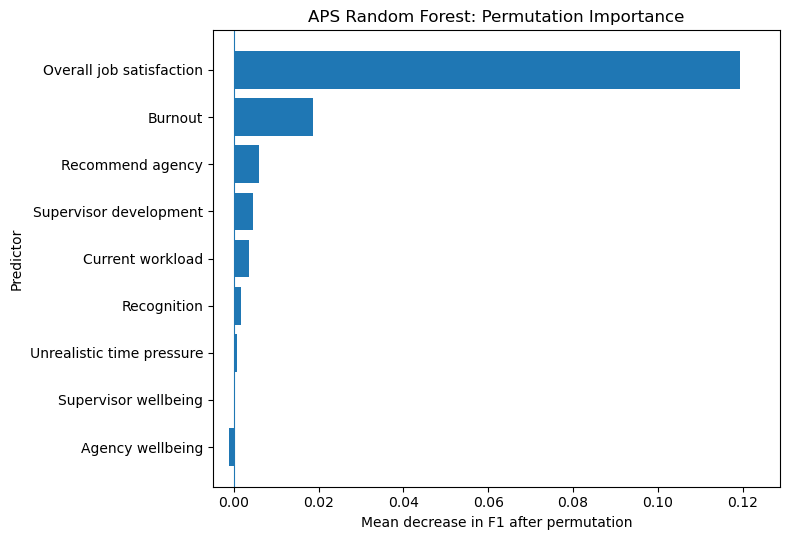

In [140]:
# APS Random Forest permutation-importance figure
import matplotlib.pyplot as plt
import pandas as pd


# Final permutation-importance results obtained earlier from the tuned APS Random Forest
aps_importance_plot = pd.DataFrame({
    "Feature": [
        "Overall job satisfaction",
        "Burnout",
        "Recommend agency",
        "Supervisor development",
        "Current workload",
        "Recognition",
        "Unrealistic time pressure",
        "Supervisor wellbeing",
        "Agency wellbeing"
    ],

    "Mean_F1_Drop": [
        0.1193,
        0.0187,
        0.0060,
        0.0044,
        0.0036,
        0.0016,
        0.0007,
        0.0003,
        -0.0012
    ],

    "SD_F1_Drop": [
        0.0024,
        0.0012,
        0.0012,
        0.0014,
        0.0011,
        0.0005,
        0.0014,
        0.0012,
        0.0008
    ]
})


# Sort so the most important predictor appears at the top
aps_importance_plot = (
    aps_importance_plot
    .sort_values("Mean_F1_Drop", ascending=True)
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(
    aps_importance_plot["Feature"],
    aps_importance_plot["Mean_F1_Drop"]
)

# Vertical reference line at zero
ax.axvline(
    x=0,
    linewidth=0.8
)

ax.set_xlabel(
    "Mean decrease in F1 after permutation"
)

ax.set_ylabel(
    "Predictor"
)

ax.set_title(
    "APS Random Forest: Permutation Importance"
)

# Give a little space on both sides of zero so the small negative importance remains visible
ax.set_xlim(
    -0.005,
    aps_importance_plot["Mean_F1_Drop"].max() * 1.08
)

plt.tight_layout()

plt.savefig(
    "../Outputs/aps_rf_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure: APS Random Forest permutation importance**

Overall job satisfaction produced by far the largest decrease in F1 when permuted, followed by burnout. Predictors with importance close to zero provided little unique predictive contribution after the other variables were considered. A small negative permutation importance should be interpreted as approximately zero predictive contribution rather than evidence of a negative effect.

## Dataset 1: IBM HR Attrition Machine Learning Preparation

The IBM HR dataset is used to model observed employee attrition.

Earlier data-quality checks identified four variables that were unsuitable for modelling: three constant variables (`EmployeeCount`, `Over18`, and `StandardHours`) and the unique employee identifier (`EmployeeNumber`). These were removed from the modelling copy.

The remaining predictors include nominal categorical variables, ordered employee experience variables, and numerical workforce characteristics. The target variable `Attrition` is converted to a binary outcome where 1 represents employee attrition and 0 represents retention.

In [141]:
# Confirm IBM modelling dataframe

print("IBM modelling dataset shape:", df_ibm_model.shape)

print("\nColumns:")
for column in df_ibm_model.columns:
    print(column)

IBM modelling dataset shape: (1470, 31)

Columns:
Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [142]:
# Define IBM predictor groups

# Nominal categorical variables:
# These categories do not have a meaningful numerical order and will therefore be one-hot encoded.
ibm_nominal_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]
# Ordered / ordinal variables

ibm_ordinal_features = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

# Numerical variables

ibm_numeric_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

# Check number of predictors
print(
    "Nominal features:",
    len(ibm_nominal_features)
)

print(
    "Ordinal features:",
    len(ibm_ordinal_features)
)

print(
    "Numerical features:",
    len(ibm_numeric_features)
)

print(
    "Total predictors:",
    len(
        ibm_nominal_features
        + ibm_ordinal_features
        + ibm_numeric_features
    )
)

Nominal features: 7
Ordinal features: 9
Numerical features: 14
Total predictors: 30


In [143]:
# Define IBM predictors and binary target
ibm_all_predictors = (
    ibm_nominal_features
    + ibm_ordinal_features
    + ibm_numeric_features
)

X_ibm = df_ibm_model[
    ibm_all_predictors
].copy()


# Convert Attrition to binary
y_ibm = (
    df_ibm_model["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

print("IBM predictor shape:", X_ibm.shape)
print("IBM target shape:", y_ibm.shape)

print("\nTarget counts:")
print(
    y_ibm.value_counts()
    .sort_index()
)

print("\nTarget distribution (%):")
print(
    y_ibm.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

IBM predictor shape: (1470, 30)
IBM target shape: (1470,)

Target counts:
Attrition
0    1233
1     237
Name: count, dtype: int64

Target distribution (%):
Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


In [144]:
# Final IBM modelling-data checks
print(
    "Missing predictor values:",
    X_ibm.isna().sum().sum()
)

print(
    "Missing target values:",
    y_ibm.isna().sum()
)

print(
    "Number of predictor columns:",
    X_ibm.shape[1]
)

print(
    "Number of records:",
    X_ibm.shape[0]
)

Missing predictor values: 0
Missing target values: 0
Number of predictor columns: 30
Number of records: 1470


### IBM Train-Test Split

The IBM attrition outcome is imbalanced, with approximately 16.12% of employees recorded as having left the organisation.

An 80/20 stratified train-test split is therefore used so that the proportion of attrition cases is preserved in both sets. The split is performed before any encoding or scaling to prevent information from the held-out test set influencing preprocessing.

In [145]:
# IBM stratified train-test split

from sklearn.model_selection import train_test_split

X_ibm_train, X_ibm_test, y_ibm_train, y_ibm_test = train_test_split(
    X_ibm,
    y_ibm,

    # Same train/test ratio used for APS
    test_size=0.20,

    # Preserve the attrition class distribution
    stratify=y_ibm,

    # Reproducibility
    random_state=42
)

print("Training predictors:", X_ibm_train.shape)
print("Test predictors:", X_ibm_test.shape)

Training predictors: (1176, 30)
Test predictors: (294, 30)


In [146]:
# Verify IBM training and test target distributions

print("\nTRAINING TARGET COUNTS")
print(
    y_ibm_train
    .value_counts()
    .sort_index()
)

print("\nTRAINING TARGET DISTRIBUTION (%)")
print(
    y_ibm_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTEST TARGET COUNTS")
print(
    y_ibm_test
    .value_counts()
    .sort_index()
)

print("\nTEST TARGET DISTRIBUTION (%)")
print(
    y_ibm_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


TRAINING TARGET COUNTS
Attrition
0    986
1    190
Name: count, dtype: int64

TRAINING TARGET DISTRIBUTION (%)
Attrition
0    83.84
1    16.16
Name: proportion, dtype: float64

TEST TARGET COUNTS
Attrition
0    247
1     47
Name: count, dtype: int64

TEST TARGET DISTRIBUTION (%)
Attrition
0    84.01
1    15.99
Name: proportion, dtype: float64


### IBM Predictor Preprocessing

The IBM dataset contains nominal categorical, ordinal, and numerical predictors.

Nominal variables are one-hot encoded because their categories have no meaningful numerical ordering. The first category is dropped to provide a reference category and avoid redundant dummy variables.

Ordinal employee-experience measures retain their existing ordered numerical coding. Numerical and ordinal predictors are standardised using parameters estimated from the training data only.

The same processed feature set is used for Logistic Regression and Random Forest to maintain a consistent model comparison.

In [147]:
# IBM preprocessing

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


ibm_onehot_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# Numerical + ordinal preprocessing

ibm_preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "nominal",
            ibm_onehot_encoder,
            ibm_nominal_features
        ),
        
        (
            "ordinal",
            StandardScaler(),
            ibm_ordinal_features
        ),
        
        (
            "numeric",
            StandardScaler(),
            ibm_numeric_features
        )
    ],
    
    remainder="drop"
)

print("IBM preprocessor created successfully")

IBM preprocessor created successfully


In [148]:
# Fit IBM preprocessing using TRAINING data only

X_ibm_train_encoded = ibm_preprocessor.fit_transform(
    X_ibm_train
)

# Apply the already-fitted transformations to the test set.
X_ibm_test_encoded = ibm_preprocessor.transform(
    X_ibm_test
)

print(
    "Encoded IBM training shape:",
    X_ibm_train_encoded.shape
)

print(
    "Encoded IBM test shape:",
    X_ibm_test_encoded.shape
)

Encoded IBM training shape: (1176, 44)
Encoded IBM test shape: (294, 44)


In [149]:
# Retrieve final IBM feature names

ibm_encoded_feature_names = (
    ibm_preprocessor
    .get_feature_names_out()
)

print(
    "Number of encoded IBM predictors:",
    len(ibm_encoded_feature_names)
)

print("\nEncoded IBM feature names:")

for feature in ibm_encoded_feature_names:
    print(feature)

Number of encoded IBM predictors: 44

Encoded IBM feature names:
nominal__BusinessTravel_Travel_Frequently
nominal__BusinessTravel_Travel_Rarely
nominal__Department_Research & Development
nominal__Department_Sales
nominal__EducationField_Life Sciences
nominal__EducationField_Marketing
nominal__EducationField_Medical
nominal__EducationField_Other
nominal__EducationField_Technical Degree
nominal__Gender_Male
nominal__JobRole_Human Resources
nominal__JobRole_Laboratory Technician
nominal__JobRole_Manager
nominal__JobRole_Manufacturing Director
nominal__JobRole_Research Director
nominal__JobRole_Research Scientist
nominal__JobRole_Sales Executive
nominal__JobRole_Sales Representative
nominal__MaritalStatus_Married
nominal__MaritalStatus_Single
nominal__OverTime_Yes
ordinal__Education
ordinal__EnvironmentSatisfaction
ordinal__JobInvolvement
ordinal__JobLevel
ordinal__JobSatisfaction
ordinal__PerformanceRating
ordinal__RelationshipSatisfaction
ordinal__StockOptionLevel
ordinal__WorkLifeBalan

In [150]:
# Check transformed data for invalid values

print(
    "NaN values in encoded training data:",
    np.isnan(X_ibm_train_encoded).sum()
)

print(
    "NaN values in encoded test data:",
    np.isnan(X_ibm_test_encoded).sum()
)

print(
    "Infinite values in encoded training data:",
    np.isinf(X_ibm_train_encoded).sum()
)

print(
    "Infinite values in encoded test data:",
    np.isinf(X_ibm_test_encoded).sum()
)

NaN values in encoded training data: 0
NaN values in encoded test data: 0
Infinite values in encoded training data: 0
Infinite values in encoded test data: 0


## IBM Model 1: Logistic Regression

Logistic Regression is used as an interpretable baseline classifier for predicting observed employee attrition.

The initial model uses the default classification threshold of 0.50 and no class weighting or hyperparameter tuning. Because attrition represents only approximately 16% of employees, accuracy is not considered sufficient on its own.

Performance is evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, accuracy, and the confusion matrix, with particular attention to performance on the attrition class.

In [151]:
# IBM Logistic Regression baseline

from sklearn.linear_model import LogisticRegression

ibm_logistic = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Fit only on the preprocessed IBM training data.
ibm_logistic.fit(
    X_ibm_train_encoded,
    y_ibm_train
)

print("IBM Logistic Regression fitted successfully")

IBM Logistic Regression fitted successfully


In [152]:
# IBM Logistic Regression predictions

# Binary predictions using the default 0.50 threshold.
y_ibm_log_pred = ibm_logistic.predict(
    X_ibm_test_encoded
)

# Probability of Attrition = 1.
y_ibm_log_prob = ibm_logistic.predict_proba(
    X_ibm_test_encoded
)[:, 1]

print("IBM Logistic Regression predictions generated")

IBM Logistic Regression predictions generated


In [153]:
# Evaluate IBM Logistic Regression baseline

ibm_log_accuracy = accuracy_score(
    y_ibm_test,
    y_ibm_log_pred
)

ibm_log_precision = precision_score(
    y_ibm_test,
    y_ibm_log_pred
)

ibm_log_recall = recall_score(
    y_ibm_test,
    y_ibm_log_pred
)

ibm_log_f1 = f1_score(
    y_ibm_test,
    y_ibm_log_pred
)

ibm_log_roc_auc = roc_auc_score(
    y_ibm_test,
    y_ibm_log_prob
)

# Precision-Recall AUC
ibm_precision_values, ibm_recall_values, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_log_prob
    )
)

ibm_log_pr_auc = auc(
    ibm_recall_values,
    ibm_precision_values
)

# Results table
ibm_logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        ibm_log_accuracy,
        ibm_log_precision,
        ibm_log_recall,
        ibm_log_f1,
        ibm_log_roc_auc,
        ibm_log_pr_auc
    ]
})

ibm_logistic_results["Score"] = (
    ibm_logistic_results["Score"]
    .round(4)
)

display(ibm_logistic_results)

,Metric,Score
0,Accuracy,0.8639
1,Precision,0.6400
2,Recall,0.3404
3,F1-score,0.4444
4,ROC-AUC,0.8102
5,PR-AUC,0.5896


In [154]:
# IBM Logistic Regression confusion matrix

ibm_log_confusion_matrix = confusion_matrix(
    y_ibm_test,
    y_ibm_log_pred
)

ibm_log_confusion_df = pd.DataFrame(
    ibm_log_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Attrition (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Attrition (1)"
    ]
)

display(ibm_log_confusion_df)

,Predicted Stay (0),Predicted Attrition (1)
Actual Stay (0),238,9
Actual Attrition (1),31,16


### IBM Logistic Regression Baseline Performance

The baseline Logistic Regression achieved 86.39% accuracy and a ROC-AUC of 0.8102, indicating reasonable overall discrimination between retained and attrited employees.

However, performance on the minority attrition class was considerably weaker. The model correctly identified only 16 of the 47 attrition cases in the test set,resulting in recall of 34.04%. It missed 31 employees who actually attrited.

Although precision was 64.00%, the low recall and F1-score of 0.4444 indicate that the default unweighted model is not sufficiently sensitive to employees at attrition risk. Because the dataset is strongly imbalanced, model tuning was therefore undertaken with particular attention to the attrition class.

In [155]:
# IBM Logistic Regression tuning with full preprocessing pipeline

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


# Build modelling pipeline

ibm_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ibm_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Hyperparameter grid

ibm_logistic_param_grid = {

    # Regularisation strength
    "classifier__C": [
        0.01,
        0.1,
        1,
        10
    ],

    # Test whether balancing the minority attrition class
    # improves F1 performance.
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

# Cross-validation grid search

# Selection metric = F1 for Attrition = 1.

ibm_logistic_grid = GridSearchCV(
    estimator=ibm_logistic_pipeline,
    param_grid=ibm_logistic_param_grid,
    scoring="f1",
    cv=5,

    # Dataset is small enough that limited parallelism
    # should be safe.
    n_jobs=-1,

    return_train_score=False
)

ibm_logistic_grid.fit(
    X_ibm_train,
    y_ibm_train
)

print(
    "Best parameters:",
    ibm_logistic_grid.best_params_
)

print(
    "Best cross-validation F1:",
    round(
        ibm_logistic_grid.best_score_,
        4
    )
)

Best parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best cross-validation F1: 0.552


In [156]:
# Summarise IBM Logistic Regression tuning results

ibm_logistic_cv_results = pd.DataFrame(
    ibm_logistic_grid.cv_results_
)

ibm_logistic_cv_summary = (
    ibm_logistic_cv_results[
        [
            "param_classifier__C",
            "param_classifier__class_weight",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .rename(
        columns={
            "param_classifier__C":
                "C",

            "param_classifier__class_weight":
                "Class_Weight",

            "mean_test_score":
                "Mean_CV_F1",

            "std_test_score":
                "SD_CV_F1"
        }
    )
    .sort_values(
        "Mean_CV_F1",
        ascending=False
    )
)

ibm_logistic_cv_summary["Mean_CV_F1"] = (
    ibm_logistic_cv_summary["Mean_CV_F1"]
    .round(4)
)

ibm_logistic_cv_summary["SD_CV_F1"] = (
    ibm_logistic_cv_summary["SD_CV_F1"]
    .round(4)
)

display(ibm_logistic_cv_summary)

,C,Class_Weight,Mean_CV_F1,SD_CV_F1
6,10.00,None,0.5520,0.0445
4,1.00,None,0.5430,0.0365
7,10.00,balanced,0.5126,0.0627
3,0.10,balanced,0.5119,0.0560
5,1.00,balanced,0.5086,0.0588
1,0.01,balanced,0.4791,0.0540
2,0.10,None,0.4627,0.0587
0,0.01,None,0.0795,0.0498


### IBM Logistic Regression Tuning

Five-fold cross-validation showed that class weighting did not improve Logistic Regression performance for the IBM dataset.

The best configuration used `C = 10` with no class weighting and achieved a mean cross-validation F1-score of 0.5520. The default-like unweighted configuration with `C = 1` achieved a slightly lower mean F1-score of 0.5430, while class-balanced models produced lower F1-scores of approximately 0.48--0.51.

Therefore, the cross-validation results did not support applying balanced class weights to the IBM Logistic Regression model. The `C = 10`, unweighted configuration was selected for final held-out test evaluation.

Cross-validation variability was greater than for the larger APS dataset, which is expected given the smaller IBM sample and relatively small number of attrition cases.

In [157]:
# Retrieve best IBM Logistic Regression pipeline

ibm_logistic_tuned = ibm_logistic_grid.best_estimator_

print(ibm_logistic_tuned)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime']),
                                                 ('ordinal', StandardScaler(),
                                                  ['Education',
                                                   'EnvironmentSatisfaction',
                                                   'JobInvolvement', 'JobLe

In [158]:
# Generate tuned IBM Logistic Regression predictions

y_ibm_log_tuned_pred = ibm_logistic_tuned.predict(
    X_ibm_test
)

# Probability of Attrition = 1
y_ibm_log_tuned_prob = ibm_logistic_tuned.predict_proba(
    X_ibm_test
)[:, 1]

print("Tuned IBM Logistic Regression predictions generated")

Tuned IBM Logistic Regression predictions generated


In [159]:
# Generate tuned IBM Logistic Regression predictions

y_ibm_log_tuned_pred = ibm_logistic_tuned.predict(
    X_ibm_test
)

# Probability of Attrition = 1
y_ibm_log_tuned_prob = ibm_logistic_tuned.predict_proba(
    X_ibm_test
)[:, 1]

print("Tuned IBM Logistic Regression predictions generated")

Tuned IBM Logistic Regression predictions generated


In [160]:
# Evaluate tuned IBM Logistic Regression

ibm_tuned_accuracy = accuracy_score(
    y_ibm_test,
    y_ibm_log_tuned_pred
)

ibm_tuned_precision = precision_score(
    y_ibm_test,
    y_ibm_log_tuned_pred
)

ibm_tuned_recall = recall_score(
    y_ibm_test,
    y_ibm_log_tuned_pred
)

ibm_tuned_f1 = f1_score(
    y_ibm_test,
    y_ibm_log_tuned_pred
)

ibm_tuned_roc_auc = roc_auc_score(
    y_ibm_test,
    y_ibm_log_tuned_prob
)


# Precision-Recall AUC
ibm_tuned_precision_values, ibm_tuned_recall_values, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_log_tuned_prob
    )
)

ibm_tuned_pr_auc = auc(
    ibm_tuned_recall_values,
    ibm_tuned_precision_values
)


# Results table
ibm_logistic_tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        ibm_tuned_accuracy,
        ibm_tuned_precision,
        ibm_tuned_recall,
        ibm_tuned_f1,
        ibm_tuned_roc_auc,
        ibm_tuned_pr_auc
    ]
})

ibm_logistic_tuned_results["Score"] = (
    ibm_logistic_tuned_results["Score"]
    .round(4)
)

display(ibm_logistic_tuned_results)

,Metric,Score
0,Accuracy,0.8605
1,Precision,0.6154
2,Recall,0.3404
3,F1-score,0.4384
4,ROC-AUC,0.8080
5,PR-AUC,0.5695


In [161]:
# Tuned IBM Logistic Regression confusion matrix

ibm_tuned_confusion_matrix = confusion_matrix(
    y_ibm_test,
    y_ibm_log_tuned_pred
)

ibm_tuned_confusion_df = pd.DataFrame(
    ibm_tuned_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Attrition (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Attrition (1)"
    ]
)

display(ibm_tuned_confusion_df)

,Predicted Stay (0),Predicted Attrition (1)
Actual Stay (0),237,10
Actual Attrition (1),31,16


In [162]:
# Compare baseline and tuned IBM Logistic Regression

ibm_logistic_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Baseline": [
        ibm_log_accuracy,
        ibm_log_precision,
        ibm_log_recall,
        ibm_log_f1,
        ibm_log_roc_auc,
        ibm_log_pr_auc
    ],

    "Tuned_C10": [
        ibm_tuned_accuracy,
        ibm_tuned_precision,
        ibm_tuned_recall,
        ibm_tuned_f1,
        ibm_tuned_roc_auc,
        ibm_tuned_pr_auc
    ]
})

ibm_logistic_comparison[
    ["Baseline", "Tuned_C10"]
] = ibm_logistic_comparison[
    ["Baseline", "Tuned_C10"]
].round(4)

display(ibm_logistic_comparison)

,Metric,Baseline,Tuned_C10
0,Accuracy,0.8639,0.8605
1,Precision,0.6400,0.6154
2,Recall,0.3404,0.3404
3,F1-score,0.4444,0.4384
4,ROC-AUC,0.8102,0.8080
5,PR-AUC,0.5896,0.5695


### Final IBM Logistic Regression Assessment

Cross-validation selected an unweighted Logistic Regression with `C = 10`, achieving a mean training cross-validation F1-score of 0.5520.

However, this tuning did not improve performance on the held-out test set. The tuned model achieved an F1-score of 0.4384 compared with 0.4444 for the baseline model, while recall remained unchanged at 34.04%. Both models correctly identified 16 of the 47 attrition cases and missed 31.

The differences in accuracy, ROC-AUC, and PR-AUC were also small. This suggests that changing the regularisation strength provided little practical generalisation benefit for this dataset.

The cross-validation-selected model was retained as the formally tuned Logistic Regression model because hyperparameter selection was based only on training data. The lack of improvement on the test set is reported as a limitation and reflects, in part, the relatively small IBM sample and small number of attrition cases in the held-out test set.

## IBM Model 2: Random Forest

Random Forest is used as a non-linear comparison to Logistic Regression for predicting observed employee attrition.

An untuned baseline model is first evaluated using the same held-out test set and evaluation metrics. This provides a consistent comparison before hyperparameter tuning is performed using training data only.

In [163]:
# IBM Random Forest baseline

from sklearn.ensemble import RandomForestClassifier

ibm_random_forest = RandomForestClassifier(
    # Sufficient number of trees for a stable baseline.
    n_estimators=200,

    # Reproducibility.
    random_state=42,

    # Use available CPU cores.
    n_jobs=-1
)

# Fit on the preprocessed IBM training data.
ibm_random_forest.fit(
    X_ibm_train_encoded,
    y_ibm_train
)

print("IBM Random Forest fitted successfully.")

IBM Random Forest fitted successfully.


In [164]:
# IBM Random Forest test predictions

y_ibm_rf_pred = ibm_random_forest.predict(
    X_ibm_test_encoded
)

# Probability of Attrition = 1
y_ibm_rf_prob = ibm_random_forest.predict_proba(
    X_ibm_test_encoded
)[:, 1]

print("IBM Random Forest predictions generated.")

IBM Random Forest predictions generated.


In [165]:
# Evaluate baseline IBM Random Forest

ibm_rf_accuracy = accuracy_score(
    y_ibm_test,
    y_ibm_rf_pred
)

ibm_rf_precision = precision_score(
    y_ibm_test,
    y_ibm_rf_pred
)

ibm_rf_recall = recall_score(
    y_ibm_test,
    y_ibm_rf_pred
)

ibm_rf_f1 = f1_score(
    y_ibm_test,
    y_ibm_rf_pred
)

ibm_rf_roc_auc = roc_auc_score(
    y_ibm_test,
    y_ibm_rf_prob
)


# Precision-Recall AUC
ibm_rf_precision_values, ibm_rf_recall_values, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_rf_prob
    )
)

ibm_rf_pr_auc = auc(
    ibm_rf_recall_values,
    ibm_rf_precision_values
)


# Results table

ibm_rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        ibm_rf_accuracy,
        ibm_rf_precision,
        ibm_rf_recall,
        ibm_rf_f1,
        ibm_rf_roc_auc,
        ibm_rf_pr_auc
    ]
})

ibm_rf_results["Score"] = (
    ibm_rf_results["Score"].round(4)
)

display(ibm_rf_results)

,Metric,Score
0,Accuracy,0.8333
1,Precision,0.4167
2,Recall,0.1064
3,F1-score,0.1695
4,ROC-AUC,0.7921
5,PR-AUC,0.4071


In [166]:
# IBM Random Forest confusion matrix

ibm_rf_confusion_matrix = confusion_matrix(
    y_ibm_test,
    y_ibm_rf_pred
)

ibm_rf_confusion_df = pd.DataFrame(
    ibm_rf_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Attrition (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Attrition (1)"
    ]
)

display(ibm_rf_confusion_df)

,Predicted Stay (0),Predicted Attrition (1)
Actual Stay (0),240,7
Actual Attrition (1),42,5


### IBM Random Forest Baseline Performance

The baseline Random Forest performed poorly on the minority attrition class. Although its accuracy was 83.33% and ROC-AUC was 0.7921, recall for attrition was only 10.64%.

The model correctly identified only 5 of the 47 employees who attrited and missed 42 attrition cases. Its F1-score of 0.1695 and PR-AUC of 0.4071 were also substantially weaker than the Logistic Regression results.

The high overall accuracy is misleading because approximately 84% of the test employees belong to the non-attrition class. Therefore, Random Forest requires tuning focused on improving minority-class detection.

In [167]:
# IBM Random Forest tuning with preprocessing pipeline

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Build complete Random Forest pipeline
ibm_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ibm_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                # Fixed number of trees during tuning
                n_estimators=200,

                random_state=42,

                # Keep internal RF parallelism off while
                # GridSearchCV handles the fitting.
                n_jobs=1
            )
        )
    ]
)

# Targeted hyperparameter grid

ibm_rf_param_grid = {

    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ],

    "classifier__max_depth": [
        None,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        5,
        10
    ]
}


# Grid search

ibm_rf_grid = GridSearchCV(
    estimator=ibm_rf_pipeline,
    param_grid=ibm_rf_param_grid,
    scoring="f1",
    cv=5,

    # Limited parallelism for stability.
    n_jobs=1,

    verbose=1,
    return_train_score=False
)

ibm_rf_grid.fit(
    X_ibm_train,
    y_ibm_train
)

print(
    "Best parameters:",
    ibm_rf_grid.best_params_
)

print(
    "Best cross-validation F1:",
    round(
        ibm_rf_grid.best_score_,
        4
    )
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 10}
Best cross-validation F1: 0.4883


In [168]:
# Summarise IBM Random Forest tuning results

ibm_rf_cv_results = pd.DataFrame(
    ibm_rf_grid.cv_results_
)

ibm_rf_cv_summary = (
    ibm_rf_cv_results[
        [
            "param_classifier__class_weight",
            "param_classifier__max_depth",
            "param_classifier__min_samples_leaf",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .rename(
        columns={
            "param_classifier__class_weight":
                "Class_Weight",

            "param_classifier__max_depth":
                "Max_Depth",

            "param_classifier__min_samples_leaf":
                "Min_Samples_Leaf",

            "mean_test_score":
                "Mean_CV_F1",

            "std_test_score":
                "SD_CV_F1"
        }
    )
    .sort_values(
        "Mean_CV_F1",
        ascending=False
    )
)

ibm_rf_cv_summary["Mean_CV_F1"] = (
    ibm_rf_cv_summary["Mean_CV_F1"]
    .round(4)
)

ibm_rf_cv_summary["SD_CV_F1"] = (
    ibm_rf_cv_summary["SD_CV_F1"]
    .round(4)
)

display(ibm_rf_cv_summary)

,Class_Weight,Max_Depth,Min_Samples_Leaf,Mean_CV_F1,SD_CV_F1
8,balanced,None,10,0.4883,0.0507
11,balanced,10,10,0.4864,0.0436
17,balanced_subsample,10,10,0.4815,0.0459
14,balanced_subsample,None,10,0.4693,0.0394
16,balanced_subsample,10,5,0.4688,0.0440
10,balanced,10,5,0.4523,0.0433
7,balanced,None,5,0.4412,0.0608
13,balanced_subsample,None,5,0.4384,0.0381
4,None,10,5,0.3011,0.0576
15,balanced_subsample,10,1,0.2899,0.0519


### IBM Random Forest Tuning

Random Forest tuning showed that class weighting and larger terminal leaves substantially improved cross-validation performance.

The best configuration used balanced class weights, unrestricted tree depth, and a minimum of 10 observations per leaf, achieving a mean cross-validation F1-score of 0.4883.

Unweighted Random Forest configurations generally produced much lower F1-scores, showing that the model required explicit treatment of the imbalanced attrition outcome. Increasing the minimum leaf size also improved performance, suggesting that reducing highly specific tree splits improved generalisation.

Despite this improvement, the best Random Forest cross-validation F1-score
remained lower than that of Logistic Regression.

In [169]:
# Retrieve best tuned IBM Random Forest pipeline

ibm_rf_tuned = ibm_rf_grid.best_estimator_

print(ibm_rf_tuned)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime']),
                                                 ('ordinal', StandardScaler(),
                                                  ['Education',
                                                   'EnvironmentSatisfaction',
                                                   'JobInvolvement', 'JobLe

In [170]:
# Generate tuned Random Forest predictions

y_ibm_rf_tuned_pred = ibm_rf_tuned.predict(
    X_ibm_test
)

# Probability of Attrition = 1
y_ibm_rf_tuned_prob = ibm_rf_tuned.predict_proba(
    X_ibm_test
)[:, 1]

print("Tuned IBM Random Forest predictions generated")

Tuned IBM Random Forest predictions generated


In [171]:
# Evaluate tuned IBM Random Forest

ibm_rf_tuned_accuracy = accuracy_score(
    y_ibm_test,
    y_ibm_rf_tuned_pred
)

ibm_rf_tuned_precision = precision_score(
    y_ibm_test,
    y_ibm_rf_tuned_pred
)

ibm_rf_tuned_recall = recall_score(
    y_ibm_test,
    y_ibm_rf_tuned_pred
)

ibm_rf_tuned_f1 = f1_score(
    y_ibm_test,
    y_ibm_rf_tuned_pred
)

ibm_rf_tuned_roc_auc = roc_auc_score(
    y_ibm_test,
    y_ibm_rf_tuned_prob
)


# Precision-Recall AUC
rf_tuned_precision_values, rf_tuned_recall_values, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_rf_tuned_prob
    )
)

ibm_rf_tuned_pr_auc = auc(
    rf_tuned_recall_values,
    rf_tuned_precision_values
)


# Results table

ibm_rf_tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        ibm_rf_tuned_accuracy,
        ibm_rf_tuned_precision,
        ibm_rf_tuned_recall,
        ibm_rf_tuned_f1,
        ibm_rf_tuned_roc_auc,
        ibm_rf_tuned_pr_auc
    ]
})

ibm_rf_tuned_results["Score"] = (
    ibm_rf_tuned_results["Score"]
    .round(4)
)

display(ibm_rf_tuned_results)

,Metric,Score
0,Accuracy,0.8129
1,Precision,0.4200
2,Recall,0.4468
3,F1-score,0.4330
4,ROC-AUC,0.7730
5,PR-AUC,0.3918


In [172]:
# Tuned IBM Random Forest confusion matrix

ibm_rf_tuned_confusion_matrix = confusion_matrix(
    y_ibm_test,
    y_ibm_rf_tuned_pred
)

ibm_rf_tuned_confusion_df = pd.DataFrame(
    ibm_rf_tuned_confusion_matrix,
    index=[
        "Actual Stay (0)",
        "Actual Attrition (1)"
    ],
    columns=[
        "Predicted Stay (0)",
        "Predicted Attrition (1)"
    ]
)

display(ibm_rf_tuned_confusion_df)

,Predicted Stay (0),Predicted Attrition (1)
Actual Stay (0),218,29
Actual Attrition (1),26,21


In [173]:
# Final IBM model comparison

ibm_final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Logistic_Regression": [
        ibm_tuned_accuracy,
        ibm_tuned_precision,
        ibm_tuned_recall,
        ibm_tuned_f1,
        ibm_tuned_roc_auc,
        ibm_tuned_pr_auc
    ],

    "Random_Forest": [
        ibm_rf_tuned_accuracy,
        ibm_rf_tuned_precision,
        ibm_rf_tuned_recall,
        ibm_rf_tuned_f1,
        ibm_rf_tuned_roc_auc,
        ibm_rf_tuned_pr_auc
    ]
})

ibm_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
] = ibm_final_model_comparison[
    ["Logistic_Regression", "Random_Forest"]
].round(4)

display(ibm_final_model_comparison)

,Metric,Logistic_Regression,Random_Forest
0,Accuracy,0.8605,0.8129
1,Precision,0.6154,0.4200
2,Recall,0.3404,0.4468
3,F1-score,0.4384,0.4330
4,ROC-AUC,0.8080,0.7730
5,PR-AUC,0.5695,0.3918


### IBM Final Model Comparison

The tuned Logistic Regression and Random Forest achieved similar F1-scores of 0.4384 and 0.4330 respectively, but exhibited different classification trade-offs.

Logistic Regression achieved higher precision (61.54%), ROC-AUC (0.8080), and PR-AUC (0.5695), indicating stronger overall discrimination and fewer false attrition alerts. It correctly identified 16 of the 47 attrition cases.

The tuned Random Forest achieved higher recall (44.68%), identifying 21 of the 47 attrition cases, but this improvement came with substantially more false positives and lower precision (42.00%).

Therefore, Logistic Regression is retained as the primary IBM model because of its slightly higher F1-score, stronger probability-ranking performance, and greater interpretability. Random Forest provides a complementary view by demonstrating the trade-off between identifying more attrition cases and generating more false-positive alerts.

These results should be interpreted cautiously because the held-out test set contains only 47 attrition cases.

#### Figure: IBM Precision–Recall Performance

Precision–Recall curves were used to compare the ability of the two models to identify the minority attrition class across different classification thresholds. This is particularly informative for the IBM dataset because only approximately 16% of employees experienced attrition.

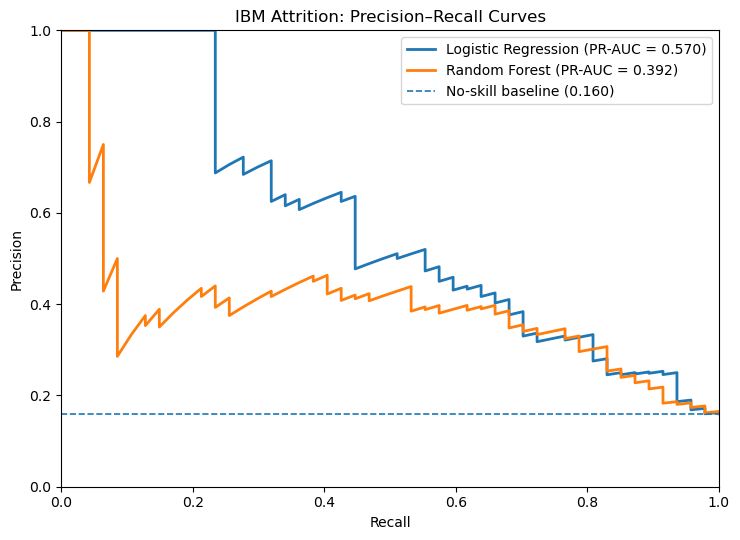

In [174]:
# IBM Precision-Recall curves

# Logistic Regression curve
ibm_lr_precision_curve, ibm_lr_recall_curve, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_log_tuned_prob
    )
)
# Random Forest curve
ibm_rf_precision_curve, ibm_rf_recall_curve, _ = (
    precision_recall_curve(
        y_ibm_test,
        y_ibm_rf_tuned_prob
    )
)
# No-skill baseline

ibm_positive_rate = y_ibm_test.mean()


# Plot
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(
    ibm_lr_recall_curve,
    ibm_lr_precision_curve,
    linewidth=2,
    label=f"Logistic Regression (PR-AUC = {ibm_tuned_pr_auc:.3f})"
)

ax.plot(
    ibm_rf_recall_curve,
    ibm_rf_precision_curve,
    linewidth=2,
    label=f"Random Forest (PR-AUC = {ibm_rf_tuned_pr_auc:.3f})"
)

ax.axhline(
    y=ibm_positive_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"No-skill baseline ({ibm_positive_rate:.3f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_title(
    "IBM Attrition: Precision–Recall Curves"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()

# Save figure
plt.savefig(
    "../Outputs/ibm_precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Precision–Recall curves for IBM attrition prediction**

Logistic Regression maintained stronger precision across much of the recall range and achieved a higher PR-AUC (0.5695) than Random Forest (0.3918).
Both models performed above the no-skill baseline associated with the approximately 16% attrition prevalence. The curves also illustrate the trade-off between identifying more attrition cases and generating additional false-positive alerts as the classification threshold changes.

### Classification Threshold

All reported classification metrics use the conventional probability threshold of 0.50.

This threshold was retained to provide a consistent evaluation of Logistic Regression and Random Forest across both datasets. However, the most suitable operational threshold would depend on the relative cost of false negatives and false positives.

For example, lowering the threshold could increase recall and identify more employees at potential retention risk, but would also increase the number of false-positive alerts.

A production retention system could select the decision threshold using training-data cross-validation and precision-recall analysis. Threshold optimisation was not performed on the held-out test sets in order to preserve their role as unbiased final evaluation data.

In [175]:
# Extract IBM tuned Logistic Regression coefficients

# Retrieve fitted components from the selected pipeline
ibm_log_preprocessor = (
    ibm_logistic_tuned.named_steps["preprocessor"]
)

ibm_log_classifier = (
    ibm_logistic_tuned.named_steps["classifier"]
)


# Get transformed feature names
ibm_log_feature_names = (
    ibm_log_preprocessor.get_feature_names_out()
)


# Logistic Regression coefficients
ibm_log_coefficients = (
    ibm_log_classifier.coef_[0]
)


# Create interpretation table
ibm_log_coefficient_table = pd.DataFrame({
    "Feature": ibm_log_feature_names,
    "Coefficient": ibm_log_coefficients
})


# Odds ratio
ibm_log_coefficient_table["Odds_Ratio"] = np.exp(
    ibm_log_coefficient_table["Coefficient"]
)


# Sort by absolute coefficient magnitude
ibm_log_coefficient_table["Absolute_Coefficient"] = (
    ibm_log_coefficient_table["Coefficient"].abs()
)

ibm_log_coefficient_table = (
    ibm_log_coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

display(
    ibm_log_coefficient_table.head(20)
)

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
17,nominal__JobRole_Sales Representative,2.075922,7.971893,2.075922
0,nominal__BusinessTravel_Travel_Frequently,1.968439,7.159491,1.968439
20,nominal__OverTime_Yes,1.927955,6.875435,1.927955
11,nominal__JobRole_Laboratory Technician,1.869332,6.483961,1.869332
7,nominal__EducationField_Other,-1.601551,0.201584,1.601551
10,nominal__JobRole_Human Resources,1.509984,4.526656,1.509984
14,nominal__JobRole_Research Director,-1.427458,0.239918,1.427458
1,nominal__BusinessTravel_Travel_Rarely,1.036497,2.819322,1.036497
6,nominal__EducationField_Medical,-0.983747,0.373908,0.983747
16,nominal__JobRole_Sales Executive,0.866923,2.379578,0.866923


In [176]:
# IBM nominal-variable reference categories

fitted_ibm_encoder = (
    ibm_log_preprocessor
    .named_transformers_["nominal"]
)

print("REFERENCE CATEGORIES\n")

for feature, categories in zip(
    ibm_nominal_features,
    fitted_ibm_encoder.categories_
):
    print(
        f"{feature}: reference = {categories[0]}"
    )

REFERENCE CATEGORIES

BusinessTravel: reference = Non-Travel
Department: reference = Human Resources
EducationField: reference = Human Resources
Gender: reference = Female
JobRole: reference = Healthcare Representative
MaritalStatus: reference = Divorced
OverTime: reference = No


In [177]:
# IBM nominal-variable reference categories

fitted_ibm_encoder = (
    ibm_log_preprocessor
    .named_transformers_["nominal"]
)

print("REFERENCE CATEGORIES\n")

for feature, categories in zip(
    ibm_nominal_features,
    fitted_ibm_encoder.categories_
):
    print(
        f"{feature}: reference = {categories[0]}"
    )

REFERENCE CATEGORIES

BusinessTravel: reference = Non-Travel
Department: reference = Human Resources
EducationField: reference = Human Resources
Gender: reference = Female
JobRole: reference = Healthcare Representative
MaritalStatus: reference = Divorced
OverTime: reference = No


### IBM Logistic Regression Insights

The Logistic Regression coefficients identify several workforce characteristics associated with observed attrition after accounting for the other predictors.

Overtime showed one of the strongest employee-experience associations. Employees recorded as working overtime had substantially higher estimated attrition odds than employees who did not work overtime. Frequent business travel was also strongly positively associated with attrition.

Higher environment satisfaction and job satisfaction were associated with lower attrition odds. Greater total working experience was similarly associated with lower attrition risk, while a longer period since the last promotion and having worked for more companies were positively associated with attrition.

Some job-role coefficients were large, particularly for Sales Representative and Laboratory Technician relative to Healthcare Representative. These category-specific estimates should be interpreted cautiously because the IBM dataset is relatively small and some categorical groups contain comparatively few observations.

The coefficients represent adjusted associations rather than causal effects. For standardised numerical and ordinal predictors, the reported odds ratios correspond to approximately a one-standard-deviation increase in the predictor. For one-hot encoded categorical variables, odds ratios are relative to the specified reference category.

In [178]:
# IBM Random Forest permutation importance

from sklearn.inspection import permutation_importance


ibm_rf_permutation = permutation_importance(
    estimator=ibm_rf_tuned,
    X=X_ibm_test,
    y=y_ibm_test,

    # Same primary evaluation metric used for model selection
    scoring="f1",

    # Multiple repetitions reduce dependence on one random shuffle
    n_repeats=20,

    random_state=42,

    n_jobs=1
)

# Create importance table
ibm_rf_importance = pd.DataFrame({
    "Feature": X_ibm_test.columns,

    "Mean_F1_Drop":
        ibm_rf_permutation.importances_mean,

    "SD_F1_Drop":
        ibm_rf_permutation.importances_std
})


ibm_rf_importance = (
    ibm_rf_importance
    .sort_values(
        "Mean_F1_Drop",
        ascending=False
    )
    .reset_index(drop=True)
)


ibm_rf_importance[
    ["Mean_F1_Drop", "SD_F1_Drop"]
] = (
    ibm_rf_importance[
        ["Mean_F1_Drop", "SD_F1_Drop"]
    ]
    .round(4)
)


display(
    ibm_rf_importance.head(15)
)

,Feature,Mean_F1_Drop,SD_F1_Drop
0,OverTime,0.1331,0.0396
1,StockOptionLevel,0.0445,0.0292
2,EnvironmentSatisfaction,0.0235,0.0208
3,Department,0.0226,0.0101
4,DistanceFromHome,0.0208,0.0267
5,Age,0.0199,0.0292
6,YearsAtCompany,0.0189,0.0248
7,JobLevel,0.0145,0.0240
8,JobRole,0.0144,0.0232
9,YearsWithCurrManager,0.0144,0.0224


#### Figure: Random Forest Predictor Importance

Permutation importance was used to assess the contribution of the original IBM predictors to Random Forest F1 performance. A larger decrease in F1 after shuffling a predictor indicates that the fitted model relied more heavily on that variable for prediction.

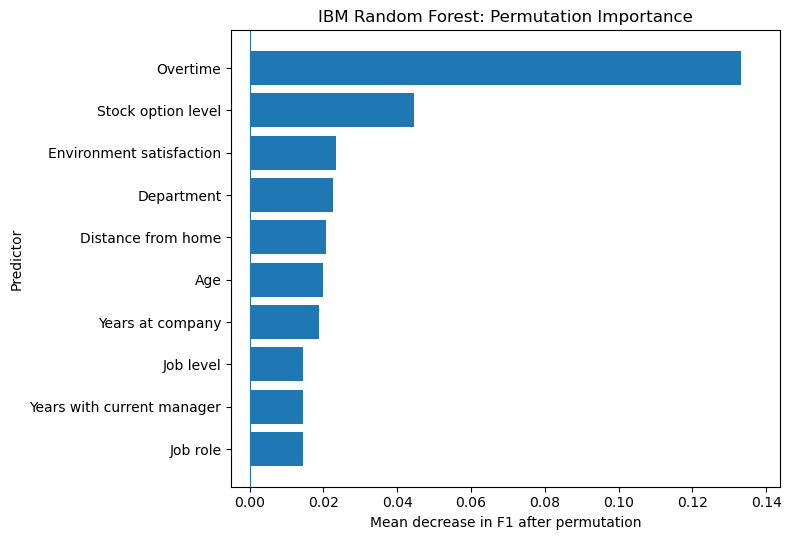

In [179]:

# Select the 10 most important original IBM predictors
ibm_importance_plot = (
    ibm_rf_importance
    .head(10)
    .copy()
)

# Making feature names easier to read 
ibm_feature_labels = {
    "OverTime":
        "Overtime",

    "StockOptionLevel":
        "Stock option level",

    "EnvironmentSatisfaction":
        "Environment satisfaction",

    "Department":
        "Department",

    "DistanceFromHome":
        "Distance from home",

    "Age":
        "Age",

    "YearsAtCompany":
        "Years at company",

    "JobLevel":
        "Job level",

    "JobRole":
        "Job role",

    "YearsWithCurrManager":
        "Years with current manager"
}


ibm_importance_plot["Display_Feature"] = (
    ibm_importance_plot["Feature"]
    .replace(ibm_feature_labels)
)

# Sort ascending so the largest value appears at the top of the horizontal bar chart.
ibm_importance_plot = (
    ibm_importance_plot
    .sort_values(
        "Mean_F1_Drop",
        ascending=True
    )
)
# Plot
fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.barh(
    ibm_importance_plot["Display_Feature"],
    ibm_importance_plot["Mean_F1_Drop"]
)


# Reference line at zero
ax.axvline(
    x=0,
    linewidth=0.8
)


ax.set_xlabel(
    "Mean decrease in F1 after permutation"
)

ax.set_ylabel(
    "Predictor"
)

ax.set_title(
    "IBM Random Forest: Permutation Importance"
)


# Provide a small amount of space around the bars
ax.set_xlim(
    -0.005,
    ibm_importance_plot["Mean_F1_Drop"].max() * 1.08
)

plt.tight_layout()

# Save for final report 
plt.savefig(
    "../Outputs/ibm_rf_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**IBM Random Forest permutation importance**
    
Overtime produced by far the largest decrease in F1 when permuted, indicating that the tuned Random Forest relied strongly on this predictor. Stock option level was a distant second, while environment satisfaction and several workforce characteristics provided smaller amounts of predictive information.
Permutation importance reflects predictive contribution rather than the direction or causality of an association.

### IBM Random Forest Insights

Permutation importance showed that `OverTime` was the most influential predictor for the tuned Random Forest by a substantial margin. Shuffling `OverTime` reduced test F1 by approximately 0.133, indicating that the model relied strongly on this variable when distinguishing attrition from retention.

`StockOptionLevel` and `EnvironmentSatisfaction` provided additional predictive information, although their importance was considerably smaller. Workforce characteristics including department, distance from home, age, organisational tenure, job level, job role, and manager tenure also contributed modestly.

Most predictors below `OverTime` showed relatively small permutation importance, with several having standard deviations similar to their mean importance. Their individual rankings should therefore be interpreted cautiously.

Permutation importance describes the contribution of a variable to predictive performance and does not indicate whether the variable increases or decreases attrition risk or establish a causal relationship.

In [180]:
# Compare key Logistic Regression findings with Random Forest permutation importance

ibm_comparison_features = [
    "OverTime",
    "BusinessTravel",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "StockOptionLevel",
    "JobRole",
    "TotalWorkingYears",
    "YearsSinceLastPromotion",
    "NumCompaniesWorked"
]

ibm_rf_key_comparison = (
    ibm_rf_importance[
        ibm_rf_importance["Feature"].isin(
            ibm_comparison_features
        )
    ]
    .copy()
)

# Preserve a logical comparison order rather than ordering only by importance.
ibm_rf_key_comparison["Feature"] = pd.Categorical(
    ibm_rf_key_comparison["Feature"],
    categories=ibm_comparison_features,
    ordered=True
)

ibm_rf_key_comparison = (
    ibm_rf_key_comparison
    .sort_values("Feature")
    .reset_index(drop=True)
)

display(ibm_rf_key_comparison)

,Feature,Mean_F1_Drop,SD_F1_Drop
0,OverTime,0.1331,0.0396
1,BusinessTravel,-0.0050,0.0140
2,EnvironmentSatisfaction,0.0235,0.0208
3,JobSatisfaction,0.0010,0.0186
4,StockOptionLevel,0.0445,0.0292
5,JobRole,0.0144,0.0232
6,TotalWorkingYears,0.0102,0.0243
7,YearsSinceLastPromotion,0.0048,0.0036
8,NumCompaniesWorked,0.0068,0.0200


### Comparison of IBM Algorithm Insights

The Logistic Regression and Random Forest models produced mostly complementary rather than contradictory insights.

Both algorithms identified `OverTime` as an important predictor of attrition. Logistic Regression estimated substantially higher attrition odds for employees working overtime, while Random Forest permutation importance showed that shuffling `OverTime` caused the largest reduction in F1-score of any predictor.

`EnvironmentSatisfaction` was also supported by both models, with higher satisfaction associated with lower attrition odds in Logistic Regression and positive predictive importance in Random Forest.

The algorithms differed in the importance assigned to several other variables.Logistic Regression highlighted business travel, job satisfaction, years since promotion, and number of companies worked, whereas these variables had limited unique permutation importance in Random Forest. This does not represent a direct contradiction because Logistic Regression coefficients describe adjusted associations, while permutation importance measures how much each variable contributes to the predictive performance of the fitted Random Forest.

Random Forest additionally highlighted `StockOptionLevel`, suggesting that non-linear relationships or interactions may provide predictive information not captured as strongly by the Logistic Regression coefficients.

Overall, the strongest cross-model IBM finding is the relationship between overtime and attrition, with employee satisfaction and other workforce characteristics providing secondary information. These findings represent associations in the IBM dataset and should not be interpreted causally.

## Cross-Dataset Synthesis: Employee Retention and Experience

The two datasets examine related employee-retention outcomes from different perspectives.

The IBM HR Analytics dataset models recorded employee attrition, whereas the 2024 APS Employee Census models respondents' stated intention to leave. Therefore, the outcomes are conceptually related but are not identical and their predictive-performance metrics should not be compared as though the datasets represent the same population or target.

Using the same two machine-learning approaches across both datasets provides a way to examine whether similar employee-experience patterns emerge from independent data sources.

In [181]:
# Cross-dataset model performance summary

cross_dataset_model_summary = pd.DataFrame({
    "Dataset": [
        "2024 APS Employee Census",
        "2024 APS Employee Census",
        "IBM HR Analytics",
        "IBM HR Analytics"
    ],

    "Outcome": [
        "Intention to Leave",
        "Intention to Leave",
        "Observed Attrition",
        "Observed Attrition"
    ],

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "F1": [
        0.6030,
        0.6011,
        0.4384,
        0.4330
    ],

    "Recall": [
        0.6123,
        0.6047,
        0.3404,
        0.4468
    ],

    "ROC_AUC": [
        0.7731,
        0.7744,
        0.8080,
        0.7730
    ],

    "PR_AUC": [
        0.6504,
        0.6527,
        0.5695,
        0.3918
    ]
})

display(cross_dataset_model_summary)

,Dataset,Outcome,Model,F1,Recall,ROC_AUC,PR_AUC
0,2024 APS Employee Census,Intention to Leave,Logistic Regression,0.6030,0.6123,0.7731,0.6504
1,2024 APS Employee Census,Intention to Leave,Random Forest,0.6011,0.6047,0.7744,0.6527
2,IBM HR Analytics,Observed Attrition,Logistic Regression,0.4384,0.3404,0.8080,0.5695
3,IBM HR Analytics,Observed Attrition,Random Forest,0.4330,0.4468,0.7730,0.3918


### Cross-Dataset Interpretation

Across both datasets, Logistic Regression and Random Forest provided broadly consistent rather than contradictory evidence that employee experience and working conditions contain useful information about retention-related outcomes.

In the APS Employee Census, overall job satisfaction was by far the strongest predictive factor across both algorithms. Burnout was the next most consistent factor, while organisational recommendation, supervisor development and workload provided additional information.

In the IBM dataset, overtime was the clearest cross-model predictor of observed attrition. Higher environment and job satisfaction were associated with lower attrition in Logistic Regression, while Random Forest also relied on environment satisfaction and several workforce characteristics.

The datasets therefore provide complementary insights. APS provides detailed attitudinal evidence linking satisfaction, burnout and workplace experience to intention to leave, while IBM provides employment-record characteristics such as overtime, travel, tenure and career progression associated with actual attrition.

The findings are not directly contradictory. Instead, they suggest that retention is multidimensional: employee attitudes and wellbeing matter, while working arrangements and career characteristics may also contribute useful predictive information.

Direct numerical comparison of model performance should be avoided because the datasets differ substantially in sample size, class prevalence, population and outcome definition. In particular, intention to leave does not necessarily result in actual employee attrition.

## Final Evidence Plan for Individual Task 1

The case study investigates employee retention from a People Analytics / Employee Experience perspective using two independent public datasets.

### Dataset 1 — IBM HR Analytics

**Outcome:** Observed employee attrition (`Attrition`)

**Dataset evidence worth retaining**
- 1,470 employees and 30 modelling predictors after removing constants and
  the employee identifier.
- Attrition class: 237 employees (16.12%).
- No missing values in the modelling data.
- Important limitation: relatively small and fictional/synthetic HR dataset,
  so results should not be generalised directly to real organisations.

**Strong descriptive evidence**
- Overtime:
  - No overtime attrition rate = 10.44%
  - Overtime attrition rate = 30.53%
- Lower job satisfaction, environment satisfaction and job involvement were
  also associated with higher attrition rates.

**Final machine-learning evidence**
- Logistic Regression:
  - F1 = 0.4384
  - Recall = 0.3404
  - ROC-AUC = 0.8080
  - PR-AUC = 0.5695
- Random Forest:
  - F1 = 0.4330
  - Recall = 0.4468
  - ROC-AUC = 0.7730
  - PR-AUC = 0.3918

**Model insights**
- Both algorithms strongly identified overtime as important.
- Logistic Regression also associated lower satisfaction and frequent travel with greater attrition.
- Random Forest additionally highlighted stock-option level and several workforce characteristics.
- The algorithms provide complementary rather than contradictory insights.


### Dataset 2 — 2024 APS Employee Census

**Outcome:** Intention to leave, constructed from question q40.

**Dataset evidence worth retaining**
- Original responses = 140,396.
- Valid q40 outcomes = 134,900.
- Complete modelling sample = 132,485.
- Intention-to-leave class = approximately 31.8%.
- Nine final employee-experience predictors.
- Complete-case removal excluded only 1.79% of valid-target observations.

**Strong descriptive evidence**
- Job satisfaction:
  - Strongly agree = 10.60% intention to leave
  - Strongly disagree = 89.47%
- Burnout:
  - Strongly disagree = 19.77%
  - Strongly agree = 67.95%
- Unrealistic time pressure and workload also showed meaningful patterns.

**Final machine-learning evidence**
- Logistic Regression:
  - F1 = 0.6030
  - Recall = 0.6123
  - ROC-AUC = 0.7731
  - PR-AUC = 0.6504
- Random Forest:
  - F1 = 0.6011
  - Recall = 0.6047
  - ROC-AUC = 0.7744
  - PR-AUC = 0.6527

**Model insights**
- Both algorithms identified job satisfaction as the dominant predictor.
- Burnout was the second strongest consistent predictor.
- Organisational recommendation, supervisor development and workload provided additional predictive information.
- The two algorithms were highly consistent and complementary.


### Cross-Dataset Story

The datasets measure related but different retention outcomes.

APS measures stated intention to leave, while IBM records observed attrition. Therefore, their metrics should not be compared as though they represent the same population or outcome.

However, both datasets support a coherent employee-retention story: employee experience, satisfaction and working conditions contain useful information about retention-related outcomes.

APS provides stronger attitudinal evidence around satisfaction, burnout and workplace experience, while IBM adds employment-condition evidence such as
overtime, travel and career characteristics.

The results are complementary rather than contradictory and suggest that
employee retention is multidimensional.

### Responsible Use and Limitations

These models should be interpreted as analytical decision-support tools rather than systems for making individual employment decisions. Employee-retention predictions may reflect demographic,organisational or other proxy relationships and would require fairness and subgroup evaluation before any operational deployment.

The APS predictors and intention-to-leave outcome were collected within the same survey, so associations may also reflect shared response context. The IBM dataset is relatively small and fictional/synthetic, limiting generalisability. Neither dataset supports causal conclusions about why employees leave.

## Conclusion

This case study used two independent employee datasets and two machine-learning algorithms to investigate retention-related outcomes from a People Analytics perspective.

Across the 2024 APS Employee Census, job satisfaction and burnout emerged as the strongest predictors of intention to leave, with organisational recommendation, supervisor development and workload providing additional information. Logistic Regression and Random Forest produced very similar predictive performance and broadly consistent insights.

In the IBM HR Analytics dataset, overtime was the strongest cross-model predictor of observed attrition. Logistic Regression additionally highlighted employee satisfaction, business travel and career-related characteristics, while Random Forest identified several complementary workforce factors.

Overall, the two data sources support a coherent but multidimensional retention story. Employee attitudes, wellbeing and satisfaction appear important, while working conditions and career characteristics may also contribute to employee retention outcomes.

The results should not be interpreted causally. The APS outcome represents stated intention to leave rather than actual departure, while the IBM dataset is relatively small and fictional/synthetic. Differences in population, sample size and target definition also mean that model-performance measures cannot be directly compared across the two datasets.

Despite these limitations, the analysis demonstrates how combining interpretable statistical modelling with a non-linear machine-learning method can provide complementary evidence to support employee-experience and retention decision-making.